<div style="text-align: center;">

# Assignment 3: Polytropic Ideal Chemical Reactors

Peter Schönung — Matriculation No. 1144689  
Chaudhry Ahmed — Matriculation No. 3060939  
Akshay Archak — Matriculation No. 3069479

</div>

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Mathematical Framework and Adaptations](#2-mathematical-framework-and-adaptations)
3. [Implementation and Verification](#3-implementation-and-verification)
3.1[Base Case](#31-base-case)
4. [Parameter Variation and Discussion](#4-parameter-variation-and-discussion)
5. [Conclusions](#5-conclusions)
6. [AI Use and Reflection](#6-ai-use-and-reflection)

---

## 1. Introduction

Tubular reactors are widely used in industry due to their straightforward construction, flexible design options, and suitability for continuous operation. Because the throughput of a tubular reactor in continuous use is large and efficient, most chemicals produced on an industrial scale are manufactured in tubular reactors. [1] This is also the case for the production of ethylene glycol (EG): in 2022, global production reached 56.97 megatonnes. [2] To meet this demand, industry relies on tubular reactors to produce ethylene glycol continuously.

In this assignment, we seek to simulate the hydrolysis of ethylene oxide (EO) to ethylene glycol (EG)

\begin{equation}
    \mathrm{EO} + \mathrm{H_2O} \rightarrow \mathrm{EG}
    \tag{1}
\end{equation}

inside a plug flow tubular reactor (PFTR). The reaction is highly exothermic ($\Delta_R H = -92.2\,\mathrm{kJ\,mol^{-1}}$): heat released along the reactor axis raises the temperature of the reaction mixture, which in turn accelerates the reaction through the Arrhenius dependence of the rate constant, $k = k(T)$. This nonlinear coupling between the material and energy balances precludes a general analytical solution and makes the degree of wall cooling a central design question. A PFTR is an idealised model of a tubular reactor in which plug flow is assumed: radial mixing is considered perfect, while axial backmixing is neglected entirely.

<!-- <img src="PFTR Guettel.png" width="1750"> -->

To simulate the reaction, a numerical ODE solver is used to compute the evolution of concentration and temperature along the reactor axis. Our goal is to simulate the resulting conversion for varying process and design parameters and to derive conclusions for an optimised reactor design from our findings. As a further point of comparison, a batch stirred tank reactor (bSTR) model is developed alongside the PFTR, allowing the two reactor types to be evaluated under equivalent throughput conditions. Given the aforementioned scale of ethylene glycol production, even incremental optimisation of the reactor harbours significant potential for reducing energy consumption, material input, and operating costs. The scope of this assignment is confined to idealised, one-dimensional modelling; results therefore cannot be transferred directly to real applications. Nevertheless, we seek to establish a conceptual framework for the hydrolysis of ethylene oxide on which further, more detailed work can reasonably be based.

## 2. Mathematical framework and adaptations

For the simulation of the EO hydrolysis, we need a sound mathematical basis to describe the processes inside the PFTR. We start by looking at the general equations of a batch stirred tank reactor (bSTR), which serve as the mathematical foundation from which the PFTR model is derived.

### 2.1 Starting Point: The Batch Stirred Tank Reactor (bSTR)

For a reaction at constant density, the general material balance for component $i$ in the bSTR is:

\begin{equation}
    \frac{d c_i}{d t} = \sum_{j=1}^{M} \nu_{i,j} \, r_j
    \tag{1}
\end{equation}

Applied to the EO hydrolysis with stoichiometric coefficients $\nu_{\mathrm{EO}} = -1$ and $\nu_{\mathrm{EG}} = +1$, equation (1) gives the component-specific material balances:

\begin{equation}
    \frac{d c_{\mathrm{EO}}}{d t} = - r
    \tag{2}
\end{equation}

\begin{equation}
    \frac{d c_{\mathrm{EG}}}{d t} = r
    \tag{3}
\end{equation}

The energy balance for the bSTR captures both the heat released by the reaction and the heat exchanged through the reactor wall:

\begin{equation}
    V_R \, \rho \, c_p \frac{d T}{d t} = - V_R \sum_{j=1}^{M} \Delta_R H_j \, r_j - h_{\mathrm{wall}} A_{\mathrm{wall}} \left(T - T_{\mathrm{wall}}\right)
    \tag{4}
\end{equation}

Since water is present in large excess, its concentration changes only slightly during the reaction and can be treated as effectively constant. The rate law therefore simplifies to a pseudo-first-order expression with respect to ethylene oxide:

\begin{equation}
    r = k_{0} \exp \left(-\frac{E_{A}}{R\, T} \right) c_{\mathrm{EO}}
    \tag{5}
\end{equation}

where:
- $\nu_{i,j}$ — stoichiometric coefficient of component $i$ in reaction $j$ (—)
- $r$ — reaction rate (mol L⁻¹ s⁻¹)
- $k_0$ — pre-exponential factor (s⁻¹)
- $E_A$ — activation energy (J mol⁻¹)
- $R$ — universal gas constant (J mol⁻¹ K⁻¹)
- $T$ — temperature (K)
- $c_{\mathrm{EO}}$ — molar concentration of ethylene oxide (mol L⁻¹)
- $c_{\mathrm{EG}}$ — molar concentration of ethylene glycol (mol L⁻¹)
- $V_R$ — reactor volume (m³)
- $\rho$ — fluid density (kg m⁻³)
- $c_p$ — specific heat capacity (J kg⁻¹ K⁻¹)
- $A_{\mathrm{wall}}$ — heat transfer area (m²)
- $h_{\mathrm{wall}}$ — wall heat transfer coefficient (W m⁻² K⁻¹)
- $T_{\mathrm{wall}}$ — wall (jacket) temperature (K)
- $\Delta_R H_j$ — reaction enthalpy of reaction $j$ (J mol⁻¹)

Equations (1) to (5) form a coupled system of ordinary differential equations, solved as an initial value problem in time using the initial conditions $c_{\mathrm{EO,in}}$; $c_{\mathrm{EG,in}} = 0$, and $T_{\mathrm{in}}$.

---

### 2.2 Key Adaptation: Space–Time Transformation

In a PFTR operated at steady state, the fluid travels through the tube as a plug with constant mean velocity $u$ and no radial concentration gradients. The residence time of a fluid element at axial position $z$ is therefore:

\begin{equation}
    t = \frac{z}{u}, \qquad \text{therefore} \qquad dt = \frac{dz}{u}
    \tag{6}
\end{equation}

Substituting this relation into the bSTR material balances (eqs. 2 and 3) replaces the time derivative with a spatial derivative along the reactor axis:

\begin{equation}
    u \cdot \frac{d c_{\mathrm{EO}}}{d z} = - r
    \tag{7}
\end{equation}

\begin{equation}
    u \cdot \frac{d c_{\mathrm{EG}}}{d z} = r
    \tag{8}
\end{equation}

where:
- $z$ — axial position along the reactor (m)
- $u$ — mean fluid velocity (m s⁻¹)

This transformation means the PFTR at steady state can be treated as an initial value problem in $z$ rather than $t$, and solved by the same numerical approach used for the bSTR. Since the stoichiometry is 1:1 and density is assumed constant, the sum of both concentrations is conserved along the entire reactor length:

\begin{equation}
    c_{\mathrm{EO}}(z) + c_{\mathrm{EG}}(z) = c_{\mathrm{EO,in}}
    \tag{9}
\end{equation}

This relation is used as an atom balance check throughout the simulation.

---

### 2.3 Energy Balance for the Cylindrical PFTR

Applying the space–time transformation (eq. 6) to the bSTR energy balance (eq. 4) requires adapting the wall heat transfer term to cylindrical reactor geometry. For an infinitesimal tube segment of length $\Delta z$, the wall-area-to-volume ratio is:

\begin{equation}
    \frac{A_{\mathrm{wall}}}{V_R} = \frac{\pi \, d_R \, \Delta z}{\dfrac{\pi}{4} d_R^2 \, \Delta z} = \frac{4}{d_R}
    \tag{10}
\end{equation}

The heat transfer surface scales linearly with the tube diameter, while the volume scales with its square, so this ratio decreases as the tube diameter grows. Substituting into the transformed energy balance, and following the formulation given in [1], yields the PFTR energy balance:

\begin{equation}
    \frac{4}{\pi} \frac{\dot{n} c_p}{d_R^2} \frac{dT}{dz} = \rho \, c_p \, u \frac{dT}{dz} = -\sum_j r_j \, \Delta_R H_j - h_{\mathrm{wall}} \frac{4}{d_R} \left( T - T_{\mathrm{wall}} \right)
    \tag{11}
\end{equation}

Substituting the pseudo-first-order rate expression (eq. 5) for the single reaction considered here:

\begin{equation}
    \rho \, c_p \, u \frac{dT}{dz} = - k_{0} \exp \left(-\frac{E_{A}}{R\, T} \right) c_{\mathrm{EO}} \, \Delta_R H - h_{\mathrm{wall}} \frac{4}{d_R} \left( T - T_{\mathrm{wall}} \right)
    \tag{12}
\end{equation}

where:
- $\dot{n}$ — molar flow rate (mol s⁻¹)
- $d_R$ — reactor inner diameter (m)
- $\Delta_R H$ — reaction enthalpy (J mol⁻¹)

The heat released by the reaction $\left[- k_{0} \exp \left(-\frac{E_{A}}{R\, T} \right) c_{\mathrm{EO}} \, \Delta_R H\right]$ will cause the mixture temperature to rise $\left[\rho \, c_p \, u \frac{dT}{dz}\right]$, while heat transfer through the reactor wall $\left[- h_{\mathrm{wall}} \frac{4}{d_R} \left( T - T_{\mathrm{wall}} \right)\right]$ counteracts this increase. \
This is significant because the rate constant is a function of temperature, $k = k(T)$. With increasing temperature, the denominator of the exponent $E_A / RT$ grows, bringing the exponent $-E_A / RT$ closer to zero from below. Since the exponent is negative, this increases the value of the exponential term and, in turn, the value of $k(T)$.

Our working hypothesis is therefore that the hydrolysis of EO proceeds faster at higher temperatures. Consequently, the reaction should be most efficient in an adiabatic reactor, where all released heat is retained to raise the temperature of the reaction mixture.

## 2.4 Motivation for later used dimensionless numbers

Two dimensionless characteristic numbers from Güttel (eq. 11.6b/c, p. 144) will be used in the discussion to support the interpretation of the parameter variation results. They are introduced here in the context of the PFTR balance equations.

The **Stanton number** $\mathrm{St}$ quantifies the ratio of the wall heat transfer capacity to the convective heat capacity of the feed stream:

$$\mathrm{St} = \frac{h_W \, A_W}{\dot{V}_e \, \rho_e \, c_{p,e}}$$


For a cylindrical tube, $A_W / \dot{V}_e = 4 / (d_R \, u)$, so the Stanton number can be written as:

$$\mathrm{St} = \frac{h_W \cdot 4}{d_R \cdot u \cdot \rho \cdot c_p}$$

A high Stanton number means that wall heat exchange is strong relative to the convective heat transport — the fluid temperature is pulled strongly towards $T_\mathrm{wall}$ along the reactor length. A low Stanton number (approaching the adiabatic limit) means the wall has little influence and the reaction heat accumulates in the fluid. The Stanton number therefore characterises the degree of thermal coupling between fluid and wall, and will be used in the discussion to quantify why the wall temperature has a more sustained influence on conversion than the inlet temperature.

The **Prater number** $\beta$  relates the maximum adiabatic temperature rise to the inlet temperature:

$$\beta = \frac{\Delta T_\mathrm{ad}}{T_\mathrm{in}} = \frac{-\Delta_R H \cdot c_{\mathrm{EO,0}}}{\nu_{\mathrm{EO}} \, \rho \, c_p \, T_\mathrm{in}}$$

It will be used in the discussion of the inlet concentration variation (Section 4.4), where $\beta$ scales directly with $c_\mathrm{EO,0}$: a lower feed concentration reduces $\beta$ and therefore the maximum temperature achievable by reaction heat alone, which directly limits the self-acceleration effect observed in the temperature profiles.

## 3. Implementation and verification

## 3.1 Base Case

To solve the equations we defined above, we choose a numerical approach. The equations above can be defined as an initial value problem, linking the concentration change of EO and EG and the Temperature change inside of the Reactor with the concentration of EO. 

The following values were given with the asignment as a starting point:
| Quantity | Symbol | Default |
| --- | --- | --- |
| Fluid velocity | $u$ | $1\,\mathrm{m\,s^{-1}}$ |
| EO inlet concentration | $c_{\mathrm{EO},in}$ | $2.27\,\mathrm{mol\,L^{-1}}$ |
| Inlet temperature | $T_{in}$ | $423\,\mathrm{K}$ |
| Reaction enthalpy | $\Delta_\mathrm{R}H$ | $-92.2\,\mathrm{kJ\,mol^{-1}}$ |
| Density | $\rho$ | $1000\,\mathrm{kg\,m^{-3}}$ |
| Heat capacity | $c_p$ | $4.19\,\mathrm{kJ\,kg^{-1}\,K^{-1}}$ |
| Tube diameter | $d_\mathrm{R}$ | $0.03\,\mathrm{m}$ |
| Wall heat-transfer coefficient | $h_\mathrm{wall}$ | $0.5\,\mathrm{kJ\,s^{-1}\,m^{-2}\,K^{-1}}$ |
| Wall temperatures | $T_\mathrm{wall}$ | $423\,\mathrm{K}$ |
| Reactor length | $L$ | $300\,\mathrm{m}$ |

Therefore we will do the first simulation run with these. 

### 3.1.1 Functions and patterns used in this section

The base case introduces the core solver structure that all later sections reuse. The functions explained in **Section 3.3** (`solve_ivp`, `np.linspace`, `np.argmax`, solver result attributes `sol.t`/`sol.y`) are therefore not repeated here — this list covers only what is new or specific to the base case.

**`np.exp`** — element-wise exponential, used to evaluate the Arrhenius factor $e^{-E_A / (R T)}$ inside `kinetics()`. Applied to a scalar temperature at every solver call. → [docs](https://numpy.org/doc/stable/reference/generated/numpy.exp.html)

**`np.abs`** — element-wise absolute value, used in the mass-balance sanity check to compute the maximum residual $\max |c_\mathrm{EO} + c_\mathrm{EG} - c_{\mathrm{EO},in}|$. → [docs](https://numpy.org/doc/stable/reference/generated/numpy.absolute.html)

**`np.max`** — returns the maximum of an array, used to find the hot-spot temperature $T_\mathrm{max}$ and the peak residual in the verification output. → [docs](https://numpy.org/doc/stable/reference/generated/numpy.max.html)

**`z_span = (0.0, L)`** — a plain Python tuple defining the integration interval passed to `solve_ivp` as its second argument. The solver uses only the two endpoints; the dense output grid is controlled separately via `z_eval`.

**`sol.success`** — boolean attribute of the `OdeSolution` object returned by `solve_ivp`; `True` if the integration completed without the solver terminating early. Used in the sanity print to confirm convergence before reading the profiles. → [docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)

<svg viewBox="0 0 760 430" xmlns="http://www.w3.org/2000/svg" role="img" style="width:100%;max-width:760px;height:auto;display:block;margin:0 auto;" font-family="Segoe UI, Helvetica, Arial, sans-serif">
  <title>Inside the PFTR solver</title>
  <desc>Anatomy of the base-case PFTR solver: initial conditions feed solve_ivp (LSODA), which marches along the reactor axis z and evaluates the right-hand side PFTR(z, f) at every step to obtain the three coupled balances, producing axial profiles.</desc>
  <defs>
    <marker id="arrow" markerWidth="9" markerHeight="9" refX="6.5" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L7,3 L0,6 Z" fill="#475569"/>
    </marker>
  </defs>
  <text x="380" y="26" text-anchor="middle" font-size="17" font-weight="700" fill="#ffffff" stroke="#000000" stroke-width="3" paint-order="stroke" stroke-linejoin="round">Inside the PFTR solver</text>
  <text x="380" y="46" text-anchor="middle" font-size="12" fill="#ffffff" stroke="#000000" stroke-width="1.6" paint-order="stroke" stroke-linejoin="round">solve_ivp marches three coupled balances along the reactor axis z</text>
  <rect x="30" y="70" width="190" height="88" rx="8" fill="#f1f5f9" stroke="#64748b" stroke-width="1.2"/>
  <text x="125" y="94"  text-anchor="middle" font-size="12"   font-weight="700" fill="#334155">Initial conditions</text>
  <text x="125" y="111" text-anchor="middle" font-size="10.5" fill="#64748b">at the inlet (z = 0)</text>
  <text x="125" y="133" text-anchor="middle" font-size="10.5" fill="#334155" font-family="monospace">f_init =</text>
  <text x="125" y="149" text-anchor="middle" font-size="10.5" fill="#334155" font-family="monospace">[c_EO_in, 0, T_in]</text>
  <rect x="250" y="70" width="260" height="88" rx="8" fill="#eff6ff" stroke="#2563eb" stroke-width="1.5"/>
  <rect x="250" y="70" width="260" height="30" rx="8" fill="#2563eb"/>
  <rect x="250" y="86" width="260" height="14" fill="#2563eb"/>
  <text x="380" y="90"  text-anchor="middle" font-size="12.5" font-weight="700" fill="#ffffff" font-family="monospace">solve_ivp(PFTR, (0,L), f_init)</text>
  <text x="380" y="120" text-anchor="middle" font-size="9.5"  fill="#1e3a8a" font-family="monospace">method='LSODA' (stiff&#8596;non-stiff)</text>
  <text x="380" y="138" text-anchor="middle" font-size="10"   fill="#1e3a8a">marches z: 0 &#8594; L, adaptive steps</text>
  <text x="380" y="155" text-anchor="middle" font-size="10"   fill="#1e3a8a">rtol = atol = 1e-8</text>
  <rect x="540" y="70" width="200" height="88" rx="8" fill="#fef3c7" stroke="#d97706" stroke-width="1.5"/>
  <text x="640" y="94"  text-anchor="middle" font-size="12"   font-weight="700" fill="#92400e">sol  &#8594;  profiles</text>
  <text x="640" y="114" text-anchor="middle" font-size="10"   fill="#92400e" font-family="monospace">z_grid, c_EO(z),</text>
  <text x="640" y="130" text-anchor="middle" font-size="10"   fill="#92400e" font-family="monospace">c_EG(z), T(z)</text>
  <text x="640" y="149" text-anchor="middle" font-size="10"   fill="#92400e" font-family="monospace">X_EO = 1 &#8722; c_EO/c_EO_in</text>
  <path d="M222,114 L246,114" fill="none" stroke="#475569" stroke-width="1.6" marker-end="url(#arrow)"/>
  <path d="M512,114 L538,114" fill="none" stroke="#475569" stroke-width="1.6" marker-end="url(#arrow)"/>
  <path d="M362,158 L362,206" fill="none" stroke="#475569" stroke-width="1.6" marker-end="url(#arrow)"/>
  <path d="M398,206 L398,158" fill="none" stroke="#475569" stroke-width="1.6" marker-end="url(#arrow)"/>
  <text x="352" y="187" text-anchor="end"   font-size="10" fill="#475569">state (z, f)</text>
  <text x="408" y="187" text-anchor="start" font-size="10" fill="#475569">slopes df/dz</text>
  <rect x="120" y="210" width="520" height="190" rx="8" fill="#f8fafc" stroke="#475569" stroke-width="1.5"/>
  <rect x="120" y="210" width="520" height="30" rx="8" fill="#475569"/>
  <rect x="120" y="226" width="520" height="14" fill="#475569"/>
  <text x="136" y="230" text-anchor="start" font-size="12.5" font-weight="700" fill="#ffffff">RHS  &#183;  PFTR(z, f) &#8594; df/dz  &#183;  evaluated at every solver step</text>
  <text x="136" y="264" font-size="10" fill="#0f172a" font-family="monospace">c_EO, c_EG, T = f</text>
  <text x="410" y="264" font-size="10" fill="#475569">&#8592; read state vector</text>
  <text x="136" y="286" font-size="10" fill="#0f172a" font-family="monospace">r = k0&#183;exp(&#8722;E_A/(R&#183;T))&#183;c_EO</text>
  <text x="410" y="286" font-size="10" fill="#475569">rate r  (Arrhenius, 1st order)</text>
  <text x="136" y="308" font-size="10" fill="#0f172a" font-family="monospace">dc_EO/dz = &#8722;r/u</text>
  <text x="410" y="308" font-size="10" fill="#475569">EO balance  &#183;  Gl. 11.2a</text>
  <text x="136" y="330" font-size="10" fill="#0f172a" font-family="monospace">dc_EG/dz = +r/u</text>
  <text x="410" y="330" font-size="10" fill="#475569">EG balance  &#183;  Gl. 11.2a</text>
  <text x="136" y="352" font-size="10" fill="#0f172a" font-family="monospace">q_wall = h_W&#183;(4/d_R)&#183;(T&#8722;T_wall)</text>
  <text x="410" y="352" font-size="10" fill="#475569">wall heat term  (jacket)</text>
  <text x="136" y="374" font-size="10" fill="#0f172a" font-family="monospace">dT/dz = (&#8722;r&#183;&#916;H_R &#8722; q_wall)/(&#961;&#183;c_p&#183;u)</text>
  <text x="410" y="374" font-size="10" fill="#475569">energy balance  &#183;  Gl. 11.2b</text>
</svg>

In [1]:
# Importing the necessary libraries, put on top of the code for easy access and readability.
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integ  # solve_ivp -> initial value problem

In [2]:
# ============================================================
# Section 3 — Parameters (default case)
# ============================================================
# All quantities are converted to a CONSISTENT SI basis
# (m, s, mol, kg, K, J). The assignment table mixes unit systems;
# the two non-trivial conversions are flagged explicitly below.

# --- Physical constant ---
R = 8.314                 # universal gas constant             [J mol^-1 K^-1]

# --- Reaction kinetics (pre-exponential factor corrected to 5.01e6) ---
k0 = 5.01e6               # pre-exponential factor             [s^-1]
E_A = 72500.0             # activation energy                  [J mol^-1]
dH_R = -92.2e3            # reaction enthalpy (kJ -> J)         [J mol^-1]

# --- Process parameters ---
u = 1.0                   # mean fluid velocity                [m s^-1]
c_EO_in = 2.27 * 1e3      # inlet EO conc. (mol/L -> mol/m^3)   [mol m^-3]  <-- unit conversion
T_in = 423.0              # inlet temperature                  [K]

# --- Fluid properties ---
rho = 1000.0              # mixture density                    [kg m^-3]
c_p = 4.19e3              # specific heat capacity (kJ -> J)    [J kg^-1 K^-1]

# --- Reactor geometry & wall ---
d_R = 0.03                # tube diameter                      [m]
h_W = 0.5e3               # wall heat-transfer coeff (kJ -> W)  [W m^-2 K^-1]  <-- unit conversion
T_wall = 423.0            # wall (jacket) temperature          [K]
L = 300.0                 # reactor length                     [m]

In [3]:
# ============================================================
# Section 3 — Model: reaction kinetics and PFTR balances
# ============================================================

def kinetics(T, c_EO):
    """Reaction rate of the EO hydrolysis (1st order in EO, Arrhenius).

    r = k0 * exp(-E_A / (R*T)) * c_EO        [mol m^-3 s^-1]
    Water is in large excess, so its concentration is constant
    and absorbed into the pseudo-first-order rate constant.
    """
    k = k0 * np.exp(-E_A / (R * T))          # rate constant      [s^-1]
    r = k * c_EO                             # reaction rate      [mol m^-3 s^-1]
    return r


def PFTR(z, f, h_value=h_W, T_wall_val=T_wall, u_val=u):
    """RHS of the steady-state PFTR ODE system in the axial coordinate z.

    State vector f = [c_EO, c_EG, T].
    Material balance (Guettel Eq. 11.2a, p. 142):  u * dc_i/dz = nu_i * r
    Energy balance   (Guettel Eq. 11.2b, p. 142):  rho * c_p * u * dT/dz = -r * dH_R - h_W * (4/d_R) * (T - T_wall)

    Parameters
    ----------
    z         : float   Axial position (independent variable)          [m]
    f         : list    State vector [c_EO, c_EG, T]
    h_value   : float   Wall heat-transfer coefficient                  [W m^-2 K^-1]
                        Default: global h_W (base case)
    T_wall_val: float   Wall (jacket) temperature                       [K]
                        Default: global T_wall (base case)
    u_val     : float   Mean fluid velocity                             [m s^-1]
                        Default: global u (base case)
    """
    c_EO, c_EG, T = f                        # unpack state vector

    r = kinetics(T, c_EO)                    # reaction rate      [mol m^-3 s^-1]

    dc_EO_dz = -r / u_val                    # EO consumed        [mol m^-4]
    dc_EG_dz = +r / u_val                    # EG formed          [mol m^-4]
    dT_dz = ((-r * dH_R) - (h_value * (4.0 / d_R) * (T - T_wall_val))) / (rho * c_p * u_val)  # [K m^-1]

    return [dc_EO_dz, dc_EG_dz, dT_dz]

In [4]:
# ============================================================
# Section 3 — Numerical solution of the default case
# ============================================================
# Initial value problem: integrate the PFTR system over z in [0, L].
# The Arrhenius coupling can make the system stiff, so LSODA is used
# (automatic stiff/non-stiff switching). Tight tolerances are set for
# a reproducible, solver-independent solution.

# Initial conditions at the reactor inlet (z = 0)
f_init = [c_EO_in, 0.0, T_in]                # [c_EO, c_EG, T]

# Axial integration span and output grid
z_span = (0.0, L)                            # integration interval  [m]
z_eval = np.linspace(0.0, L, 3001)           # output positions      [m]

# Solve the initial value problem
sol = integ.solve_ivp(
    PFTR, z_span, f_init,
    method="LSODA",
    t_eval=z_eval,
    rtol=1e-8, atol=1e-8,
)

# Unpack solution profiles for convenience
z_grid = sol.t                               # axial position    [m]
c_EO = sol.y[0]                              # EO concentration  [mol m^-3]
c_EG = sol.y[1]                              # EG concentration  [mol m^-3]
T = sol.y[2]                                 # temperature       [K]
X_EO = 1.0 - c_EO / c_EO_in                  # EO conversion     [-]

# --- quick sanity output (optional, can be removed in the final report) ---
print(f"Solver success      : {sol.success}")
print(f"Conversion at outlet: X_EO = {X_EO[-1]:.4f}")
print(f"Outlet temperature  : T    = {T[-1]:.2f} K")
print(f"Hot spot            : T_max = {T.max():.2f} K at z = {z_grid[np.argmax(T)]:.1f} m")
print(f"Mass-balance check  : max|c_EO + c_EG - c_EO_in| = {np.max(np.abs(c_EO + c_EG - c_EO_in)):.2e} mol/m^3")

Solver success      : True
Conversion at outlet: X_EO = 0.9262
Outlet temperature  : T    = 426.44 K
Hot spot            : T_max = 437.31 K at z = 98.1 m
Mass-balance check  : max|c_EO + c_EG - c_EO_in| = 1.82e-12 mol/m^3


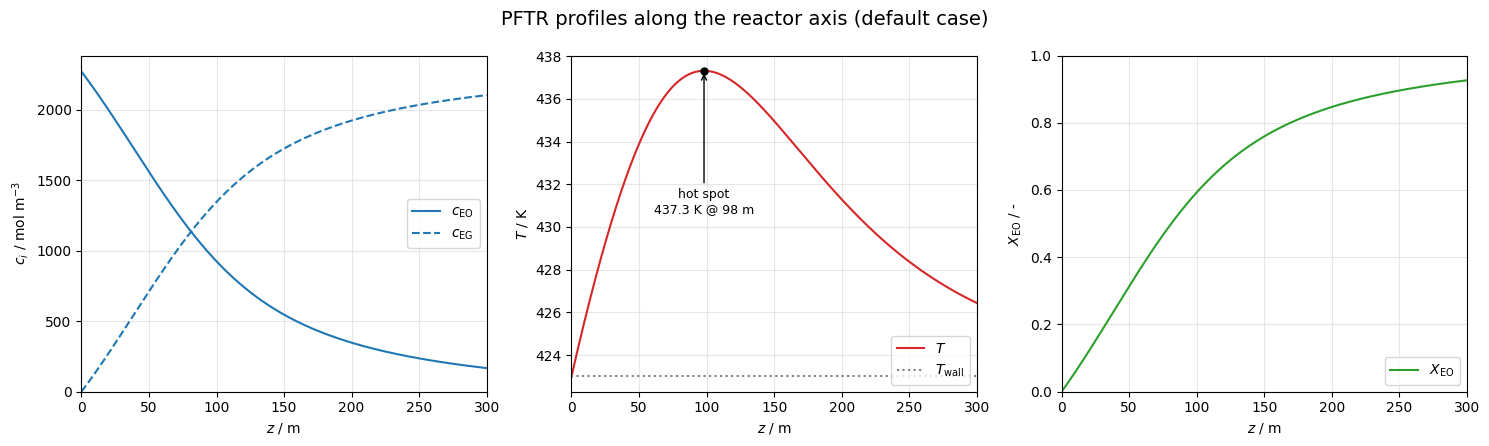

In [5]:
# ============================================================
# Section 3 — Visualization of the default case
# ============================================================
# Three panels along the reactor axis z:
#   (1) species concentrations, (2) temperature with hot spot,
#   (3) EO conversion. Axes are labelled as "symbol / unit".

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

# --- (1) Concentration profiles ---
ax1.plot(z_grid, c_EO, color="tab:blue", label=r"$c_\mathrm{EO}$")
ax1.plot(z_grid, c_EG, color="tab:blue", ls="--", label=r"$c_\mathrm{EG}$")
ax1.set(xlabel=r"$z$ / m", ylabel=r"$c_i$ / mol m$^{-3}$")
ax1.set_xlim(0, L); ax1.set_ylim(bottom=0)
ax1.legend(); ax1.grid(alpha=0.3)

# --- (2) Temperature profile with hot spot ---
i_hot = np.argmax(T)
ax2.plot(z_grid, T, color="tab:red", label=r"$T$")
ax2.axhline(T_wall, color="gray", ls=":", label=r"$T_\mathrm{wall}$")
ax2.plot(z_grid[i_hot], T[i_hot], "o", color="black", ms=5)
ax2.annotate(f"hot spot\n{T[i_hot]:.1f} K @ {z_grid[i_hot]:.0f} m",
                 xy=(z_grid[i_hot], T[i_hot]),          # arrow tip = hot spot
                 xytext=(z_grid[i_hot], T[i_hot] - 5.5),  # text directly below, same z
                 ha="center", va="top",                 # centred under the point
                 arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
ax2.set(xlabel=r"$z$ / m", ylabel=r"$T$ / K")
ax2.set_xlim(0, L); ax2.legend(loc="lower right"); ax2.grid(alpha=0.3)

# --- (3) Conversion profile ---
ax3.plot(z_grid, X_EO, color="tab:green", label=r"$X_\mathrm{EO}$")
ax3.set(xlabel=r"$z$ / m", ylabel=r"$X_\mathrm{EO}$ / -")
ax3.set_xlim(0, L); ax3.set_ylim(0, 1)
ax3.legend(loc="lower right"); ax3.grid(alpha=0.3)

fig.suptitle("PFTR profiles along the reactor axis (default case)", fontsize=14)

fig.tight_layout()

## 3.2 Verification of the model

To verify the model we created, we perform four different checks:

---

> **Verification 1:**

We use the isothermal case to check the numerical solver against a clean analytical solution. The temperature is held at the inlet value $T_{in}$, so the rate constant $k(T_{in})$ stays constant along the whole length of the reactor and the energy balance is inactive. The EO balance then reduces to

\begin{equation}
    u \, \frac{dc_{EO}}{dz} = -k(T_{in}) \, c_{EO}
    \tag{13}
\end{equation}

which has the clean analytical solution

\begin{equation}
    c_{EO}(z) = c_{EO,in} \, \exp\!\left(-\frac{k(T_{in})}{u} \, z\right)
    \tag{14}
\end{equation}

By simulating the reactor with the numerical solver for the isothermal case and comparing the result with the analytical solution, we obtain the maximum deviation between the two profiles over the length of the PFTR. Relative deviations smaller than 1e-5 are considered within the solver tolerance level.

---

> **Verification 2:**

We check the material balance for the correct conversion of EO to EG. The stoichiometric conversion is 1:1, so the sum of outgoing EO and EG must equal the incoming amount of EO. Because the density of the mixture is assumed constant, we can check the material balance directly via the concentrations of the incoming and outgoing streams. Values below 1e-6 are considered permissible for solver deviation.

---

> **Verification 3:**

We check the other edge case besides isothermal behaviour: an adiabatic PFTR. In this case, the heat transfer to the wall is set to 0, which simplifies the energy balance to:

\begin{equation}
    \rho \, c_p \, u \frac{dT}{dz} = - k_{0} \exp\!\left(-\frac{E_{A}}{R\, T}\right) c_{\mathrm{EO}} \, \Delta_R H_j
    \tag{15}
\end{equation}

In the adiabatic case we also obtain an analytical solution. The temperature rise can be described as

\begin{equation}
    T(z) = T_{in} + \Delta T_{ad} \, X_{EO}(z),
    \tag{16}
\end{equation}

with $\Delta T_{ad}$ being the adiabatic temperature increase, defined through the Prater number $\beta$ (a dimensionless number)

\begin{equation}
    \beta_j \equiv \frac{\Delta T_{\mathrm{ad}}}{T_i} = \frac{\Delta_R H \, c_{EO,i}}{\nu_{EO} \, \rho \, c_p \, T_i}
    \tag{17}
\end{equation}

and $X_{EO}(z)$ being the conversion of EO at the current point inside the reactor as a fraction (0 to 1). At 100% conversion the total possible temperature rise through heat released by the reaction equals the aforementioned adiabatic temperature increase. Comparing the analytical solution at all evaluated points inside the reactor gives the maximum deviation between the expected and calculated value. Deviations smaller than 1e-3 are considered permissible for solver deviation.

---

> **Verification 4:**

To confirm that the result is independent of the solver settings, we vary the tolerance values rtol/atol stepwise from 1e-4 to 1e-10 and verify that the key outputs stop changing. In addition, we repeat the integration with a different method than "LSODA", to rule out that the result is an artifact of one particular integration scheme. If all methods yield the same result, the solution can be considered solver-independent.

In [6]:
# ============================================================
# Verification 1 — Isothermal analytical limit
# ============================================================
# Rationale (CRE):
#   If all heat effects are switched off, the temperature stays at T_in and the EO balance reduces to a linear, first-order ODE in the axial coordinate: 
#   u * dc_EO/dz = -k(T_in) c_EO
#   This has the well-known closed-form solution of a first-order reaction in an ideal PFTR (analogous to a first-order batch reactor): 
#   c_EO(z) = c_EO_in * exp(-k(T_in)/u * z)
#   Comparing the numerical solver against this EXACT result validates the whole numerical pipeline (RHS assembly, kinetics, integration, division by u).

k_in = k0 * np.exp(-E_A / (R * T_in))                       # rate constant at inlet temperature [s^-1]

# (a) Numerical solution: PFTR with h_value=np.inf triggers the isothermal
#     sentinel branch (T pinned at T_in, only material balance active),
#     consistent with the solve_case() wrapper in Section 4.1.
sol_iso = integ.solve_ivp(
    lambda z, c: [-kinetics(T_in, c[0]) / u],
    (0.0, L), [c_EO_in],
    method="LSODA", t_eval=z_eval, rtol=1e-8, atol=1e-8
)
c_EO_num = sol_iso.y[0]                                     # numerical profile [mol m^-3]

# (b) Exact analytical solution on the same axial grid
c_EO_ana = c_EO_in * np.exp(-k_in / u * z_eval)            # closed-form profile [mol m^-3]

# (c) Compare numerical vs. analytical
abs_err = np.max(np.abs(c_EO_num - c_EO_ana))               # absolute deviation [mol m^-3]
rel_err = np.max(np.abs(c_EO_num - c_EO_ana) / c_EO_in)     # relative deviation [-]

print("Verification 1 - isothermal analytical limit")
print(f"  isothermal outlet conversion : X = {1 - c_EO_num[-1]/c_EO_in:.4f}")
print(f"  max |numerical - analytical| : {abs_err:.2e} mol/m^3")
print(f"  max relative deviation       : {rel_err:.2e}")
print(f"  -> {'PASS' if rel_err < 1e-5 else 'CHECK'} (deviation at solver-tolerance level)\n")

Verification 1 - isothermal analytical limit
  isothermal outlet conversion : X = 0.8126
  max |numerical - analytical| : 4.31e-05 mol/m^3
  max relative deviation       : 1.90e-08
  -> PASS (deviation at solver-tolerance level)



In [7]:
# ============================================================
# Verification 2 — Atom / mass balance
# ============================================================
# Rationale (CRE):
#   The stoichiometry is 1 EO -> 1 EG and the density is constant, so no carbon can be lost: every EO molecule consumed must appear as an EG molecule. Hence the sum of both concentrations equals the feed value at EVERY position:
#       c_EO(z) + c_EG(z) = c_EO_in
#   IMPORTANT: this is a NECESSARY but NOT SUFFICIENT check. It would also be satisfied if both reaction rates were scaled by the same wrong factor. It is therefore used together with the analytical checks 1 and 3.

mass_residual = np.max(np.abs(c_EO + c_EG - c_EO_in))    # on the default solution [mol m^-3]

print("Verification 2 - atom/mass balance (default case)")
print(f"  max |c_EO + c_EG - c_EO_in| : {mass_residual:.2e} mol/m^3")
print(f"  -> {'PASS' if mass_residual < 1e-6 else 'CHECK'} (conserved to machine precision)\n")

Verification 2 - atom/mass balance (default case)
  max |c_EO + c_EG - c_EO_in| : 1.82e-12 mol/m^3
  -> PASS (conserved to machine precision)



In [8]:
# ============================================================
# Verification 3 — Adiabatic limit (energy balance)
# ============================================================
# Rationale (CRE):
#   With no wall heat transfer (h_W = 0) the reactor is adiabatic: all reaction heat is stored as sensible heat of the fluid. Combining the material and energy balance then yields an EXACT first integral, independent of kinetics:
#       T(z) = T_in + dT_ad * X_EO(z)
#   with the ADIABATIC TEMPERATURE RISE
#       dT_ad = -dH_R * c_EO_in / (rho * c_p)
#   (equivalent to the dimensionless PRATER number beta via dT_ad = beta * T_in; Guettel & Turek, Chem. Reaktionstechnik, Eq. 11.6b, p. 143).
#   This validates the heat-release term and the rho*c_p*u factor of the energy balance - precisely the part that check 1 (with dH_R = 0) does not test.

dT_ad = -dH_R * c_EO_in / (rho * c_p)            # adiabatic temperature rise [K]

# Adiabatic solve: PFTR with h_value=0.0 (wall term switched off)
sol_ad = integ.solve_ivp(
    PFTR, (0.0, L), [c_EO_in, 0.0, T_in],
    method="LSODA", t_eval=z_eval,
    rtol=1e-8, atol=1e-8,
    args=(0.0,),                               # h_value=0 -> adiabatic, T_wall and u at defaults
)
c_EO_ad, T_ad = sol_ad.y[0], sol_ad.y[2]
X_ad = 1.0 - c_EO_ad / c_EO_in

# (a) Outlet temperature vs. expectation at the achieved conversion
T_expected_out = T_in + dT_ad * X_ad[-1]
# (b) Stronger: the linear T-X relation must hold along the WHOLE reactor
T_linear = T_in + dT_ad * X_ad
max_dev = np.max(np.abs(T_ad - T_linear))        # [K]

print("Verification 3 - adiabatic limit")
print(f"  adiabatic temperature rise dT_ad : {dT_ad:.2f} K")
print(f"  adiabatic outlet conversion      : X = {X_ad[-1]:.4f}")
print(f"  outlet temperature T_out         : {T_ad[-1]:.2f} K (expected {T_expected_out:.2f} K)")
print(f"  max |T - (T_in + dT_ad*X)|       : {max_dev:.2e} K")
print(f"  -> {'PASS' if max_dev < 1e-3 else 'CHECK'} (T-X coupling exact along the reactor)\n")

Verification 3 - adiabatic limit
  adiabatic temperature rise dT_ad : 49.95 K
  adiabatic outlet conversion      : X = 1.0000
  outlet temperature T_out         : 472.95 K (expected 472.95 K)
  max |T - (T_in + dT_ad*X)|       : 7.39e-13 K
  -> PASS (T-X coupling exact along the reactor)



In [9]:
# ============================================================
# Verification 4 — Numerical convergence & solver independence
# ============================================================
# Rationale (CRE / numerics):
#   A trustworthy result must be a property of the MODEL, not of the solver settings. We therefore (a) tighten the integration tolerances step by step and confirm that the key outputs stop changing, and (b) repeat the solve with different integration methods and confirm they agree.
#   NOTE: t_eval only sets the OUTPUT sampling (dense-output interpolation); the actual accuracy is controlled by rtol/atol, not by the output grid.

def solve_default(method, rtol, atol):
    """Solve the default polytropic case; return (X_out, T_max, T_out).
    Uses dense output evaluated on a fixed fine grid so that the hot-spot
    temperature T_max is captured consistently across all solvers."""
    s = integ.solve_ivp(PFTR, (0.0, L), [c_EO_in, 0.0, T_in], method=method, rtol=rtol, atol=atol, dense_output=True)
    zz = np.linspace(0.0, L, 3001)
    cc, _, TT = s.sol(zz)
    return 1.0 - cc[-1] / c_EO_in, TT.max(), TT[-1]

print("Verification 4 - convergence & solver independence")

# (a) Tolerance study with a single solver
print("  tolerance study (LSODA):")
print(f"    {'rtol=atol':>10} | {'X_out':>8} | {'T_max/K':>9} | {'T_out/K':>9}")
for tol in [1e-4, 1e-6, 1e-8, 1e-10]:
    X_out, T_max, T_out = solve_default("LSODA", tol, tol)
    print(f"    {tol:>10.0e} | {X_out:8.5f} | {T_max:9.4f} | {T_out:9.4f}")

# (b) Cross-check with different solvers at tight tolerance
print("  solver comparison at rtol = atol = 1e-10:")
for m in ["LSODA", "BDF", "Radau"]:
    X_out, T_max, T_out = solve_default(m, 1e-10, 1e-10)
    print(f"    {m:>6}: X_out = {X_out:.6f}, T_max = {T_max:.4f} K, T_out = {T_out:.4f} K")

Verification 4 - convergence & solver independence
  tolerance study (LSODA):
     rtol=atol |    X_out |   T_max/K |   T_out/K
         1e-04 |  0.92626 |  437.3162 |  426.4415
         1e-06 |  0.92621 |  437.3120 |  426.4401
         1e-08 |  0.92621 |  437.3120 |  426.4402
         1e-10 |  0.92621 |  437.3120 |  426.4402
  solver comparison at rtol = atol = 1e-10:


     LSODA: X_out = 0.926207, T_max = 437.3120 K, T_out = 426.4402 K
       BDF: X_out = 0.926207, T_max = 437.3120 K, T_out = 426.4402 K
     Radau: X_out = 0.926207, T_max = 437.3120 K, T_out = 426.4402 K


All four verification checks returned positive results / results within the accepted margins. Therefor we can assume our model to be mathematically and physically sound. The behaviour of the model results within our to-be-done parameter variation can thus be analyzed without seeking for explanations in the implementation of the model.

## 3.3 Code structure: how the calculation and plotting cells work

Sections 3 and 4 are built from two recurring cell templates: **calculation cells** that produce the data and **plotting cells** that visualize it. In the spirit of the FAIR principle *"R" (Reusable / readable)*, the shared building blocks are explained once here instead of commenting every individual figure line — which would bloat the notebook without improving readability. The underlying balance equations and symbols follow Güttel, *Chemische Reaktionstechnik* (see Section 2); the code below is only their numerical realization.

Throughout the notebook, every result is produced by **one calculation cell immediately followed by one plotting cell**. The calculation cell stores its output in a list (e.g. `results`, `results_42`); the plotting cell consumes exactly that list. The two are always read as a pair.

### A) Calculation cells — *"computing the data"*

A calculation cell follows four steps: \
**(1)** define the array of cases being varied plus a shared output grid, \
**(2)** wrap the solver in a small function so that *one call = one case*, \
**(3)** run that function over every case, \
**(4)** optionally derive scalar quantities (outlet conversion, hot-spot temperature, required length) and print a quick sanity check.

### Functions used:

**Grid and array construction**
- [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) — evenly spaced axial output grid `z_eval`; the *same* grid is reused for every case so all profiles share one x-sampling.
- [`np.arange`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html) — integer index positions, e.g. for bar-group placement on the x-axis.
- [`np.logspace`](https://numpy.org/doc/stable/reference/generated/numpy.logspace.html) — logarithmically spaced sweep values where a quantity spans several orders of magnitude (e.g. velocity scans).
- [`np.array`](https://numpy.org/doc/stable/reference/generated/numpy.array.html) — turns Python lists of results into NumPy arrays so they can be sorted and sliced.
- [`np.full_like`](https://numpy.org/doc/stable/reference/generated/numpy.full_like.html) — constant-valued array with the same shape as `z_eval`; used to pin `T = T_in` in the isothermal branch.

**The IVP solver (the core of every calculation cell)**
- [`integ.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) — integrates the coupled PFTR ODE system `d[c_EO, c_EG, T]/dz` over `z ∈ [0, L]`. The arguments used throughout are:
  - `method="LSODA"` — automatic stiff/non-stiff switching; robust against the Arrhenius-driven stiffness near the hot spot ([LSODA docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.LSODA.html)).
  - `t_eval=z_eval` — the axial positions at which the solution is reported.
  - `rtol=1e-8, atol=1e-8` — tight tolerances for a reproducible, solver-independent result.
  - `args=(value,)` — injects the varied parameter (e.g. `h_wall`) into the right-hand side without redefining it.
- `sol.t`, `sol.y`, `sol.success` — the returned solution object: `sol.t` is the z-grid, `sol.y` holds the state rows `[c_EO, c_EG, T]`, and `sol.success` flags convergence.
- `lambda z, c: [...]` — an inline one-line right-hand side used for the isothermal limit, where only the material balance is integrated and the temperature is held constant.

**Element-wise math**
- [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) — Arrhenius factor in the rate constant.
- [`np.log`](https://numpy.org/doc/stable/reference/generated/numpy.log.html), [`np.sqrt`](https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html) — used in the convergence and dimensionless-number helpers.
- [`np.abs`](https://numpy.org/doc/stable/reference/generated/numpy.absolute.html), [`np.max`](https://numpy.org/doc/stable/reference/generated/numpy.max.html) — residuals and maxima for the verification checks and hot-spot detection.

**Search and case logic**
- [`np.argmax`](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) — first index where a condition holds (first `z` with `X ≥ X_target`; hot-spot location via `argmax(T)`).
- [`np.argsort`](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html) — sorting indices so connecting lines stay monotone even if the case array is unordered.
- [`np.isinf`](https://numpy.org/doc/stable/reference/generated/numpy.isinf.html), [`np.isclose`](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html) — detect the `np.inf` sentinel and compare floats safely in the checks.
- [`np.inf`](https://numpy.org/doc/stable/reference/constants.html) — sentinel value that switches the solver wrapper into the pinned-temperature isothermal branch, avoiding feeding `h_wall → ∞` directly to the solver.

**Sweep pattern and custom helper functions**
- List comprehension `results = [solve_case(v) for v in case_values]` — runs the solver once per case and collects all profiles in a single list. Adding or removing a case means editing only the value array.
- Custom functions defined inside these cells:
  - `kinetics(T, c_EO)` — the reaction rate law.
  - `PFTR(z, f)` / local `rhs(z, f)` — the ODE right-hand side returned to `solve_ivp`.
  - `solve_case(...)`, `solve_Twall(...)`, `solve_Tin(...)`, `solve_cEO(...)` — per-case solver wrappers.
  - `length_to_target(X, z, X_target)` — first axial position reaching a conversion target, or `None` if it is never reached.
  - small label helpers (`case_label`, `label_Twall`) that build LaTeX legend strings.

### B) Plotting cells — *"plotting the data"*

A plotting cell follows six steps: \
**(1)** define all plot variables at the top,\
**(2)** create the figure/axes canvas, \
**(3)** draw one curve or bar per case by looping over the results, \
**(4)** format the axes, \
**(5)** build a legend from manual handles, \
**(6)** lay out the figure and export it as a PNG.

> **Convention in every plotting cell:** all plot variables — case count `n_cases`, colour arrays, bar `width`, x-positions `x_pos` — are defined at the **top of the same cell**. Nothing relies on a variable surviving from an earlier cell, so each figure cell runs correctly on its own after a kernel restart.

**Canvas**
- [`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) — creates the `fig` and a grid of `ax` objects in one call (mostly `1×3` profile panels, or a single `1×1` bar chart); `figsize=(w, h)` sets the size in inches.

**Drawing**
- [`ax.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html) — line plots of `T(z)`, `X(z)` and concentrations; `color`, `ls` (linestyle) and `label` distinguish the curves.
- [`ax.bar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html) — grouped bars for required reactor length; solid bars = `X ≥ 0.90`, half-transparent hatched bars (`hatch="///"`) = `X ≥ 0.999`.
- [`ax.axhline`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axhline.html) / `ax.axvline` — horizontal/vertical reference lines (`T_wall`, the `L = 300 m` reactor limit).
- [`ax.axvspan`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvspan.html) — shaded vertical band marking a reference region.

**Annotation**
- [`ax.text`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html) — free-form text labels (e.g. the *"> 300 m"* caps on bars that miss the target).
- [`ax.annotate`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html) — text with an arrow pointing at a feature (e.g. the hot-spot marker).

**Axes formatting**
- [`ax.set`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set.html) — sets `xlabel`, `ylabel` (and more) in one call; axes are labelled as *"symbol / unit"*.
- `ax.set_xlim` / `ax.set_ylim` — fix the visible ranges.
- `ax.set_xticks` / `ax.set_xticklabels` — categorical x-ticks for bar charts (e.g. the `T_wall` cases).
- [`ax.set_xscale`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_xscale.html) — logarithmic x-axis where a swept quantity spans decades.
- [`ax.grid`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.grid.html) — light reference grid (`alpha=0.3`).
- [`ax.twinx`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.twinx.html) — a second y-axis sharing the x-axis (conversion left, temperature right in the trade-off panel).
- [`ax.tick_params`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.tick_params.html) — colours the tick labels to match their respective axis.

**Colour**
- [`plt.cm.<map>`](https://matplotlib.org/stable/users/explain/colors/colormaps.html) — perceptual colormaps keyed to the case *index*, so the scheme adapts to any number of cases: `coolwarm` for `h_wall`, `plasma` for `T_in`, `viridis` for concentration variations.

**Legends from manual handles**
- [`ax.legend`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html) / [`fig.legend`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.legend.html) — axis-level vs. figure-level legend (the shared case legend sits below all panels).
- [`Line2D`](https://matplotlib.org/stable/api/_as_gen/matplotlib.lines.Line2D.html), [`Patch`](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Patch.html) — manually built legend entries (a coloured line per case; a solid vs. hatched patch for the two conversion targets) so the legend stays correct regardless of draw order.

**Figure layout and export**
- [`fig.suptitle`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.suptitle.html) — overall figure title.
- [`fig.tight_layout`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.tight_layout.html) / [`fig.subplots_adjust`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.subplots_adjust.html) — spacing so labels and the external legend do not overlap.
- [`fig.savefig`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html) — writes the figure to PNG (`dpi=150`, `bbox_inches="tight"`). The saved files are embedded in the report through HTML `<img src="fig_….png" width="…">` tags in the Markdown cells.

### Cell mockups

The two templates below show the *skeleton* shared by every calculation and plotting cell in this notebook. Real cells only add more cases, panels or annotations on top of this structure.

## **Mockup 1 — a calculation cell**

```python
# ============================================================
# Section X — what is being computed
# ============================================================

# 1) CASES + SHARED GRID  (defined at the TOP of the cell)
case_values = [0.0, 250.0, 500.0, np.inf]      # the quantity being varied
z_eval      = np.linspace(0.0, L, 3001)        # shared axial output grid

# 2) SOLVER WRAPPER  — one call = one case
def solve_case(value):
    """Integrate the PFTR for a single parameter value -> profiles."""
    sol = integ.solve_ivp(
        PFTR, (0.0, L), [c_EO_in, 0.0, T_in],
        method="LSODA", t_eval=z_eval,
        rtol=1e-8, atol=1e-8, args=(value,),
    )
    c_EO, c_EG, T = sol.y
    X_EO = 1.0 - c_EO / c_EO_in
    return z_eval, c_EO, c_EG, T, X_EO          # always the same 5-tuple

# 3) RUN THE SWEEP  — list comprehension over all cases
results = [solve_case(v) for v in case_values]

# 4) (optional) DERIVED QUANTITIES / sanity check
print(f"Outlet conversion (case 0): X = {results[0][4][-1]:.4f}")
```

## **Mockup 2 — a plotting cell**

```python
# ============================================================
# Section X — Visualization of what was computed
# ============================================================

# 1) PLOT VARIABLES  (ALL defined at the TOP — nothing inherited)
n_cases = len(case_values)
colors  = [plt.cm.coolwarm(i / max(n_cases - 1, 1)) for i in range(n_cases)]
# bar charts additionally define here: x_pos = np.arange(n_cases); width = 0.35

# 2) CANVAS — figure + axes grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 3) DRAW — loop over the results list, one curve per case
for (z, c_EO, c_EG, T, X), col in zip(results, colors):
    ax1.plot(z, T, color=col)
    ax2.plot(z, X, color=col)
ax1.axhline(T_wall, color="gray", ls=":")        # reference line

# 4) AXES COSMETICS — labels, limits, grid
ax1.set(xlabel=r"$z$ / m", ylabel=r"$T$ / K"); ax1.set_xlim(0, L); ax1.grid(alpha=0.3)
ax2.set(xlabel=r"$z$ / m", ylabel=r"$X$ / -"); ax2.set_ylim(0, 1); ax2.grid(alpha=0.3)

# 5) LEGEND — manual handles so it matches the cases
handles = [Line2D([0], [0], color=c, lw=2, label=case_label(v))
           for c, v in zip(colors, case_values)]
fig.legend(handles=handles, loc="lower center", ncol=4)

# 6) LAYOUT + EXPORT
fig.suptitle("…"); fig.tight_layout()
fig.savefig("fig_X.png", dpi=150, bbox_inches="tight")
```

### **How to read the two mockups together:** 
The calculation cell always returns the same fixed tuple `(z, c_EO, c_EG, T, X_EO)` per case and bundles them in `results`. The plotting cell never recomputes anything — it only unpacks that tuple inside a `for … zip(results, colors)` loop and maps each case to one colour and one curve/bar. Because the case list drives both the solving (step 3 of the calculation cell) and the colouring/legend (steps 1 + 5 of the plotting cell), adding or removing a case requires editing a single array, and every figure updates automatically.

<svg viewBox="0 0 820 470" xmlns="http://www.w3.org/2000/svg" role="img" style="width:100%;max-width:820px;height:auto;display:block;margin:0 auto;" font-family="Segoe UI, Helvetica, Arial, sans-serif">
  <title>From calculation cell to plotting cell</title>
  <desc>Data-flow schematic: a shared case array feeds a calculation cell that produces a results list, which a plotting cell consumes to draw figures and export a PNG embedded in the report.</desc>
  <defs>
    <marker id="arrow" markerWidth="9" markerHeight="9" refX="6.5" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L7,3 L0,6 Z" fill="#475569"/>
    </marker>
  </defs>
  <text x="410" y="26" text-anchor="middle" font-size="17" font-weight="700" fill="#ffffff" stroke="#000000" stroke-width="3" paint-order="stroke" stroke-linejoin="round">From calculation cell to plotting cell</text>
  <text x="410" y="46" text-anchor="middle" font-size="12" fill="#ffffff" stroke="#000000" stroke-width="1.6" paint-order="stroke" stroke-linejoin="round">one calculation cell produces a results list that one plotting cell consumes</text>
  <rect x="230" y="64" width="360" height="48" rx="8" fill="#f8fafc" stroke="#475569" stroke-width="1.5"/>
  <text x="410" y="86" text-anchor="middle" font-size="12" font-weight="700" fill="#0f172a" font-family="monospace">case array  (h_wall &#183; T_in &#183; c_EO,in &#183; T_wall)</text>
  <text x="410" y="103" text-anchor="middle" font-size="10.5" fill="#475569">defined once &#8212; feeds both cells</text>
  <path d="M330,112 L210,148" fill="none" stroke="#475569" stroke-width="1.5" marker-end="url(#arrow)"/>
  <path d="M490,112 L610,148" fill="none" stroke="#475569" stroke-width="1.5" marker-end="url(#arrow)"/>
  <rect x="40" y="150" width="310" height="180" rx="8" fill="#eff6ff" stroke="#2563eb" stroke-width="1.5"/>
  <rect x="40" y="150" width="310" height="30" rx="8" fill="#2563eb"/>
  <rect x="40" y="166" width="310" height="14" fill="#2563eb"/>
  <text x="56" y="170" font-size="13" font-weight="700" fill="#ffffff">CALCULATION CELL &#8212; computes the data</text>
  <text x="56" y="206" font-size="10.5" fill="#1e3a8a" font-family="monospace">z_eval = np.linspace(0, L, 3001)</text>
  <text x="56" y="230" font-size="10.5" fill="#1e3a8a" font-family="monospace">def solve_case(v):</text>
  <text x="56" y="250" font-size="10.5" fill="#1e3a8a" font-family="monospace">    integ.solve_ivp(&#8230;, "LSODA")</text>
  <text x="56" y="270" font-size="10.5" fill="#1e3a8a" font-family="monospace">    return z, c_EO, c_EG, T, X</text>
  <text x="56" y="302" font-size="10.5" fill="#1e3a8a" font-family="monospace" font-weight="700">results = [solve_case(v) for v in cases]</text>
  <rect x="470" y="150" width="310" height="180" rx="8" fill="#f0fdf4" stroke="#16a34a" stroke-width="1.5"/>
  <rect x="470" y="150" width="310" height="30" rx="8" fill="#16a34a"/>
  <rect x="470" y="166" width="310" height="14" fill="#16a34a"/>
  <text x="486" y="170" font-size="13" font-weight="700" fill="#ffffff">PLOTTING CELL &#8212; visualizes the data</text>
  <text x="486" y="206" font-size="10.5" fill="#15803d" font-family="monospace"># all plot vars at top</text>
  <text x="486" y="230" font-size="10.5" fill="#14532d" font-family="monospace">fig, ax = plt.subplots(&#8230;)</text>
  <text x="486" y="250" font-size="10.5" fill="#14532d" font-family="monospace">for (&#8230;, X), col in zip(results, colors):</text>
  <text x="486" y="270" font-size="10.5" fill="#14532d" font-family="monospace">    ax.plot(z, X, color=col)</text>
  <text x="486" y="302" font-size="10.5" fill="#14532d" font-family="monospace" font-weight="700">legend via Line2D / Patch handles</text>
  <path d="M350,240 L362,240" fill="none" stroke="#475569" stroke-width="1.8" marker-end="url(#arrow)"/>
  <path d="M456,240 L470,240" fill="none" stroke="#475569" stroke-width="1.8" marker-end="url(#arrow)"/>
  <rect x="364" y="214" width="92" height="52" rx="8" fill="#fef3c7" stroke="#d97706" stroke-width="1.5"/>
  <text x="410" y="236" text-anchor="middle" font-size="12" font-weight="700" fill="#92400e" font-family="monospace">results</text>
  <text x="410" y="252" text-anchor="middle" font-size="8" fill="#92400e" font-family="monospace">(z,c_EO,c_EG,T,X)</text>
  <path d="M625,330 L625,356" fill="none" stroke="#475569" stroke-width="1.5" marker-end="url(#arrow)"/>
  <rect x="470" y="356" width="310" height="32" rx="6" fill="#f1f5f9" stroke="#64748b" stroke-width="1.2"/>
  <text x="625" y="376" text-anchor="middle" font-size="10.5" fill="#334155" font-family="monospace">fig.savefig("fig_X.png", dpi=150)</text>
  <path d="M625,388 L625,406" fill="none" stroke="#475569" stroke-width="1.5" marker-end="url(#arrow)"/>
  <rect x="470" y="406" width="310" height="32" rx="6" fill="#f1f5f9" stroke="#64748b" stroke-width="1.2"/>
  <text x="625" y="426" text-anchor="middle" font-size="10.5" fill="#334155" font-family="monospace">&lt;img src="fig_X.png"&gt; in report</text>
</svg>

## 4. Parameter variation and discussion

In this section, we will vary different parameters and plot the results for discussion. We decided to start by varying the wall and inlet temperatures, to see how the system behaves when the heating is changed. Our subsequent parameter variations are based on the results of the variations before. For readability, we decided to only vary parameters and plot them in section 4. For the discussion of results and reasoning behind further parameter variation, please refer to section 5 "Conclusions". We included the plots in the discussion for better readability, as we found the amount of code between two plots to be very disruptive for the reader. For questions of how the data was calculated and visualized, you are of course welcome to read the code. To find your way from the plot in the discussion to the corresponding code cells, we numbered them from 4.1 onwards and name the sections in the discussion accordingly.

In [10]:
# ============================================================
# Section 4.1 — Parameter variation: wall heat transfer
#             (adiabatic -> isothermal via h_wall)
# ============================================================

# >>> EDIT ONLY THIS ARRAY to add/remove/change cases. <
# Sentinel values:  0   -> adiabatic   (no wall heat removal)
#                   inf -> isothermal  (temperature pinned at T_in)
# Any positive finite value is a polytropic case with that h_wall.
# The plotting cell adapts automatically to ANY number of cases.
# h_wall_values = [0.0, 125.0, 250.0, 500.0, 1000.0, 2000.0, np.inf]   # [W m^-2 K^-1]
h_wall_values = [0.0, 125.0, 250.0, 350.0, 500.0, 750.0, 1000.0, 2000.0, 3000.0, np.inf]   # [W m^-2 K^-1]

# Shared axial output grid (same x-axis sampling for every case)
z_eval = np.linspace(0.0, L, 3001)

def solve_case(h_wall_value):
    """Solve the PFTR for a single wall heat-transfer coefficient.

    Returns the axial profiles (z, c_EO, c_EG, T, X_EO) sampled on z_eval.
    - h_wall_value = inf -> isothermal limit: the temperature is pinned at T_in
      and only the material balance is integrated (avoids stiffness / 'inf').
    - any finite value (including 0 = adiabatic) -> full 3-equation system.
    """
    if np.isinf(h_wall_value):
        # isothermal: u dc_EO/dz = -k(T_in) c_EO,  T = T_in = const.
        sol = integ.solve_ivp(lambda z, c: [-kinetics(T_in, c[0]) / u], (0.0, L), [c_EO_in], method="LSODA", t_eval=z_eval, rtol=1e-8, atol=1e-8)
        c_EO = sol.y[0]
        c_EG = c_EO_in - c_EO                 # from the 1:1 mass balance
        T = np.full_like(z_eval, T_in)        # temperature stays constant
    else:
        # polytropic / adiabatic: full system with the given h_wall
        sol = integ.solve_ivp(PFTR, (0.0, L), [c_EO_in, 0.0, T_in], method="LSODA", t_eval=z_eval, rtol=1e-8, atol=1e-8, args = (h_wall_value,))
        c_EO, c_EG, T = sol.y

    X_EO = 1.0 - c_EO / c_EO_in
    return z_eval, c_EO, c_EG, T, X_EO

# Solve every case in the array
results = [solve_case(h) for h in h_wall_values]

def case_label(h):
    """Legend label for a given h_wall value (handles the two limits)."""
    if h == 0:      return r"$h_\mathrm{wall}=0$ (adiabatic)"
    if np.isinf(h): return r"$h_\mathrm{wall}\to\infty$ (isothermal)"
    return rf"$h_\mathrm{{wall}}={h:.0f}$"

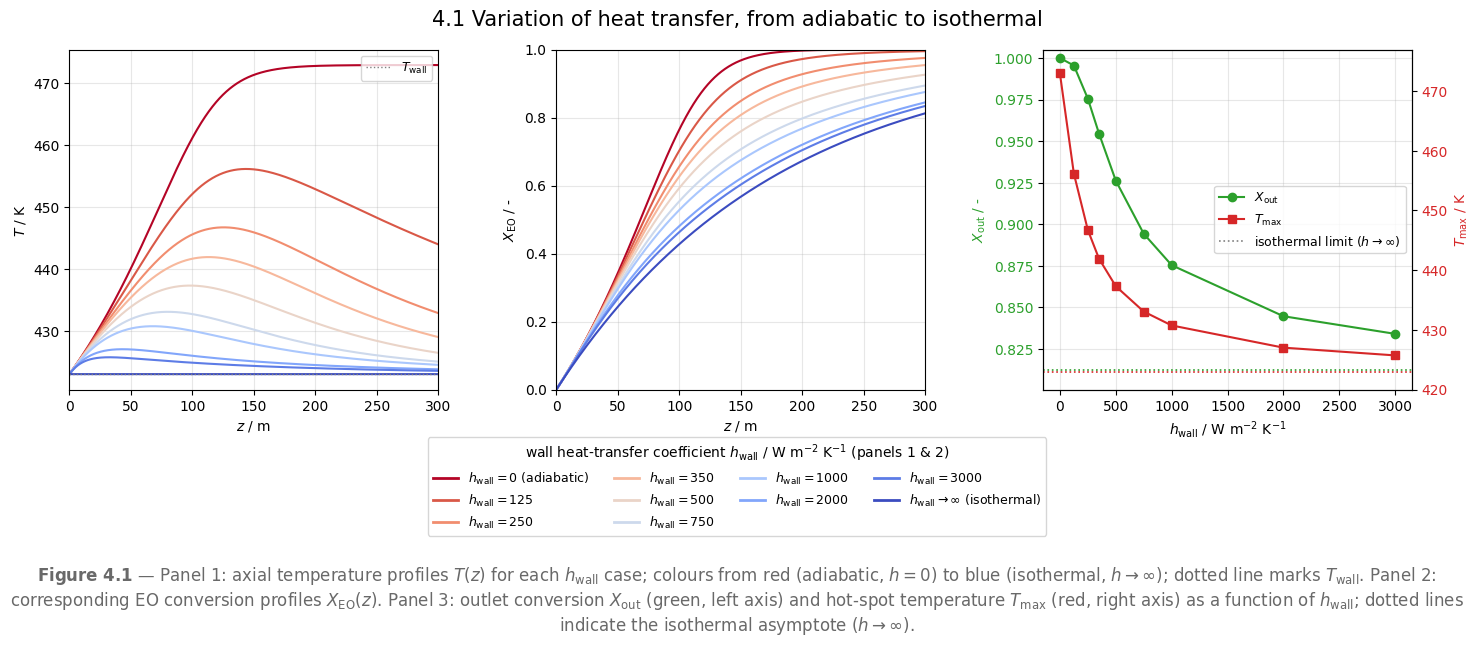

In [11]:
# ============================================================
# Section 4.1 — Heat-transfer variation: temperature & conversion
#             profiles plus the conversion/temperature trade-off
# ============================================================
n_cases = len(h_wall_values)

# Colour map keyed to the case INDEX -> adapts to any number of cases.
# Low cooling (adiabatic) = warm/red, strong cooling (isothermal) = cool/blue.
colors = [plt.cm.coolwarm(1.0 - i / max(n_cases - 1, 1)) for i in range(n_cases)]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: temperature profiles T(z) ; Panel 2: conversion profiles X(z) ---
for (z, c_EO, c_EG, T, X), col in zip(results, colors):
    ax1.plot(z, T, color=col)
    ax2.plot(z, X, color=col)

ax1.axhline(T_wall, color="gray", ls=":", lw=1, label=r"$T_\mathrm{wall}$")   # reference
ax1.set(xlabel=r"$z$ / m", ylabel=r"$T$ / K");            ax1.set_xlim(0, L)
ax2.set(xlabel=r"$z$ / m", ylabel=r"$X_\mathrm{EO}$ / -"); ax2.set_xlim(0, L); ax2.set_ylim(0, 1)
ax1.legend(loc="upper right", fontsize=9)
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)

# --- Panel 3: trade-off of outlet conversion and hot-spot temperature vs h_wall ---
h_fin, X_out, T_max = [], [], []
X_iso = T_iso = None
for h, (z, c_EO, c_EG, T, X) in zip(h_wall_values, results):
    if np.isinf(h):
        X_iso, T_iso = X[-1], T.max()
    else:
        h_fin.append(h); X_out.append(X[-1]); T_max.append(T.max())

order = np.argsort(h_fin)
h_fin = np.array(h_fin)[order]; X_out = np.array(X_out)[order]; T_max = np.array(T_max)[order]

ax3b = ax3.twinx()
l1, = ax3.plot(h_fin, X_out, "o-", color="tab:green", label=r"$X_\mathrm{out}$")
l2, = ax3b.plot(h_fin, T_max, "s-", color="tab:red", label=r"$T_\mathrm{max}$")
handles = [l1, l2]

if X_iso is not None:
    ax3.axhline(X_iso, color="tab:green", ls=":", lw=1.2)
    ax3b.axhline(T_iso, color="tab:red", ls=":", lw=1.2)
    ax3.set_ylim(X_iso - 0.012, 1.005)
    ax3b.set_ylim(T_iso - 3, T_max.max() + 4)
    handles.append(plt.Line2D([0], [0], color="gray", ls=":", lw=1.2, label=r"isothermal limit ($h\to\infty$)"))

ax3.set_xlabel(r"$h_\mathrm{wall}$ / W m$^{-2}$ K$^{-1}$")
ax3.set_ylabel(r"$X_\mathrm{out}$ / -", color="tab:green")
ax3b.set_ylabel(r"$T_\mathrm{max}$ / K", color="tab:red")
ax3.tick_params(axis="y", labelcolor="tab:green")
ax3b.tick_params(axis="y", labelcolor="tab:red")
ax3.grid(alpha=0.3)
ax3.legend(handles=handles, loc="center right", fontsize=9)

# --- shared, adaptive case legend (panels 1 & 2) below the figure ---
from matplotlib.lines import Line2D
case_handles = [Line2D([0], [0], color=col, lw=2, label=case_label(h))
                for col, h in zip(colors, h_wall_values)]
fig.legend(handles=case_handles, loc="lower center", bbox_to_anchor=(0.5, -0.085),
           ncol=min(n_cases, 4), fontsize=9,
           title=r"wall heat-transfer coefficient $h_\mathrm{wall}$ / W m$^{-2}$ K$^{-1}$ (panels 1 & 2)")

# --- figure description below the legend ---
fig.text(
    0.5, -0.13,
    r"$\bf{Figure\ 4.1}$"
    " — Panel 1: axial temperature profiles $T(z)$ for each $h_\\mathrm{wall}$ case; "
    "colours from red (adiabatic, $h=0$) to blue (isothermal, $h\\to\\infty$); "
    "dotted line marks $T_\\mathrm{wall}$. "
    "Panel 2: corresponding EO conversion profiles $X_\\mathrm{EO}(z)$. "
    "Panel 3: outlet conversion $X_\\mathrm{out}$ (green, left axis) and hot-spot temperature "
    "$T_\\mathrm{max}$ (red, right axis) as a function of $h_\\mathrm{wall}$; "
    "dotted lines indicate the isothermal asymptote ($h\\to\\infty$).",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig.transFigure
)

fig.suptitle("4.1 Variation of heat transfer, from adiabatic to isothermal", fontsize=15)
fig.subplots_adjust(left=0.055, right=0.95, top=0.90, bottom=0.22, wspace=0.32)

fig.savefig("fig_3_1_hwall_variation.png", dpi=150, bbox_inches="tight")

In [12]:
# ============================================================
# Section 4.2 — Parameter variation: wall temperature T_wall
#               Fixed: T_in = 423 K, h_W = 500 W m^-2 K^-1, L = 300 m
#               Varied: T_wall from 323 K (50 °C) to 473 K (200 °C)
# ============================================================
# Physical motivation:
#   T_wall < T_in  -> net cooling throughout the reactor
#   T_wall = T_in  -> base case (reference)
#   T_wall > T_in  -> initial heating of the fluid before reaction heat
#                     dominates; resembles steam-jacket heating at ~20 bar
#   Upper bound 473 K chosen as the condensation temperature of 20-bar steam
#   (~212 °C) minus heat losses through insulation between jacket and inner wall.

T_wall_values = [373.15, 408.0, 423.0, 453.0, 473.0, 513.0]   # [K]  (100, 135 150, 180, 200, 240 °C)
T_in_fixed    = 423.0                                   # inlet temperature fixed at base case [K]
h_W_fixed     = 500.0                                   # wall heat-transfer coeff, base case  [W m^-2 K^-1]
L_fixed       = 300.0                                   # reactor length, base case             [m]

z_eval_42 = np.linspace(0.0, L_fixed, 3001)            # shared axial output grid

def solve_Twall(T_wall_val):
    """Solve the PFTR for a given wall temperature T_wall_val.

    All other parameters are held at their base-case values.
    Uses the central PFTR function via args=(h_W_fixed, T_wall_val).
    Returns axial profiles (z, c_EO, c_EG, T, X_EO).
    """
    sol = integ.solve_ivp(
        PFTR, (0.0, L_fixed), [c_EO_in, 0.0, T_in_fixed],
        method="LSODA", t_eval=z_eval_42,
        rtol=1e-8, atol=1e-8,
        args=(h_W_fixed, T_wall_val),              # h_value=500, T_wall_val varied, u at default
    )
    c_EO, c_EG, T_prof = sol.y
    X_EO = 1.0 - c_EO / c_EO_in
    return z_eval_42, c_EO, c_EG, T_prof, X_EO

# Solve for all wall temperatures
results_42 = [solve_Twall(Tw) for Tw in T_wall_values]

def label_Twall(Tw):
    """Legend label including both K and °C; marks base case explicitly."""
    celsius = Tw - 273.15
    tag = " (base case)" if np.isclose(Tw, 423.0) else ""
    return rf"$T_\mathrm{{wall}}$ = {Tw:.0f} K ({celsius:.0f} °C){tag}"

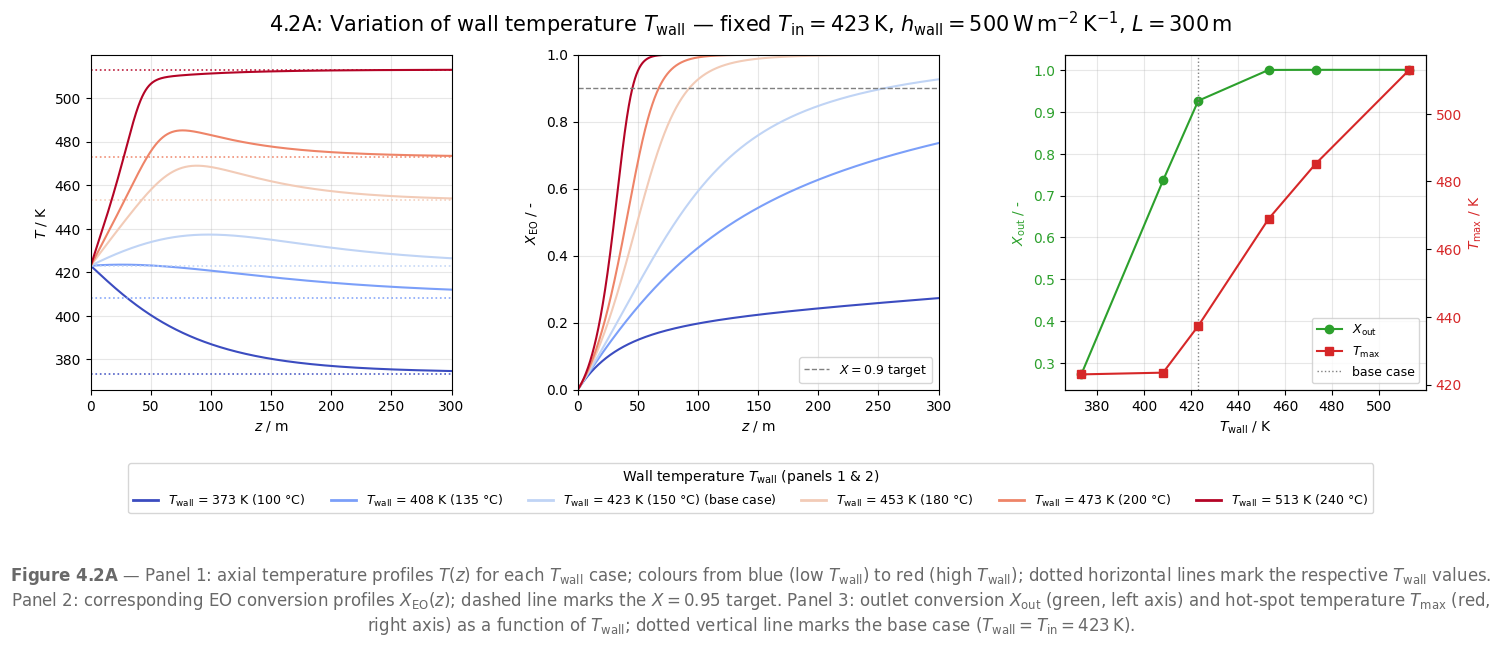

In [13]:
# ============================================================
# Section 4.2 — Plotting: T_wall variation
# Three panels:
#   (1) Temperature profiles T(z)
#   (2) Conversion profiles X_EO(z)
#   (3) Summary: outlet conversion and hot-spot temperature vs T_wall
# ============================================================
from matplotlib.lines import Line2D

n_cases_42 = len(T_wall_values)

# Color map: cold blue (low T_wall) -> warm red (high T_wall)
colors_42 = [plt.cm.coolwarm(i / (n_cases_42 - 1)) for i in range(n_cases_42)]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# --- Panels 1 & 2: profiles ---
for (z, c_EO, c_EG, T, X), col, Tw in zip(results_42, colors_42, T_wall_values):
    ax1.plot(z, T,   color=col)
    ax2.plot(z, X,   color=col)
    # mark T_wall as horizontal reference on the temperature panel
    ax1.axhline(Tw, color=col, lw=1.2, ls=":", alpha=0.9)

ax1.axvline(0, color="k", lw=0.4)          # reactor inlet marker
ax1.set(xlabel=r"$z$ / m", ylabel=r"$T$ / K")
ax1.set_xlim(0, L_fixed); ax1.grid(alpha=0.3)

ax2.axhline(0.9, color="gray", ls="--", lw=1.0, label=r"$X = 0.9$ target")
ax2.set(xlabel=r"$z$ / m", ylabel=r"$X_\mathrm{EO}$ / -")
ax2.set_xlim(0, L_fixed); ax2.set_ylim(0, 1)
ax2.legend(loc="lower right", fontsize=9); ax2.grid(alpha=0.3)

# --- Panel 3: summary (X_out and T_max vs T_wall) ---
X_out_42  = [res[4][-1]      for res in results_42]   # outlet conversion
T_max_42  = [res[3].max()    for res in results_42]   # hot-spot temperature

ax3b = ax3.twinx()
l1, = ax3.plot( T_wall_values, X_out_42, "o-", color="tab:green", label=r"$X_\mathrm{out}$")
l2, = ax3b.plot(T_wall_values, T_max_42, "s-", color="tab:red",   label=r"$T_\mathrm{max}$")

# Mark base case
ax3.axvline(423.0, color="gray", ls=":", lw=1.0, label=r"base case ($T_\mathrm{wall}=T_\mathrm{in}$)")

ax3.set_xlabel(r"$T_\mathrm{wall}$ / K")
ax3.set_ylabel(r"$X_\mathrm{out}$ / -",   color="tab:green")
ax3b.set_ylabel(r"$T_\mathrm{max}$ / K",  color="tab:red")
ax3.tick_params(axis="y", labelcolor="tab:green")
ax3b.tick_params(axis="y", labelcolor="tab:red")
ax3.grid(alpha=0.3)
ax3.legend(handles=[l1, l2,
    Line2D([0],[0], color="gray", ls=":", lw=1.0, label=r"base case")],
    loc="lower right", fontsize=9)

# --- Shared legend for panels 1 & 2 ---
case_handles_42 = [
    Line2D([0],[0], color=col, lw=2, label=label_Twall(Tw))
    for col, Tw in zip(colors_42, T_wall_values)
]
fig.legend(handles=case_handles_42, loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=n_cases_42, fontsize=9,
           title=r"Wall temperature $T_\mathrm{wall}$ (panels 1 & 2)")

# --- figure description below the legend ---
fig.text(
    0.5, -0.13,
    r"$\bf{Figure\ 4.2 A}$"
    " — Panel 1: axial temperature profiles $T(z)$ for each $T_\\mathrm{wall}$ case; "
    "colours from blue (low $T_\\mathrm{wall}$) to red (high $T_\\mathrm{wall}$); "
    "dotted horizontal lines mark the respective $T_\\mathrm{wall}$ values. "
    "Panel 2: corresponding EO conversion profiles $X_\\mathrm{EO}(z)$; "
    "dashed line marks the $X = 0.95$ target. "
    "Panel 3: outlet conversion $X_\\mathrm{out}$ (green, left axis) and hot-spot temperature "
    "$T_\\mathrm{max}$ (red, right axis) as a function of $T_\\mathrm{wall}$; "
    "dotted vertical line marks the base case ($T_\\mathrm{wall} = T_\\mathrm{in} = 423\\,\\mathrm{K}$).",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig.transFigure
)

fig.suptitle(r"4.2A: Variation of wall temperature $T_\mathrm{wall}$ — fixed $T_\mathrm{in}=423\,\mathrm{K}$, "
             r"$h_\mathrm{wall}=500\,\mathrm{W\,m^{-2}\,K^{-1}}$, $L=300\,\mathrm{m}$", fontsize=15)
fig.subplots_adjust(left=0.06, right=0.95, top=0.89, bottom=0.22, wspace=0.35)

fig.savefig("fig_4_2_Twall_variation.png", dpi=150, bbox_inches="tight")

      T_wall |   L (X≥0.90) |   L (X≥0.999)
-------------------------------------------
   373.15 K |      > 300 m |       > 300 m
   408.00 K |      > 300 m |       > 300 m
   423.00 K |      255.6 m |       > 300 m
   453.00 K |       92.8 m |       242.9 m
   473.00 K |       67.3 m |       131.5 m
   513.00 K |       45.4 m |        71.3 m


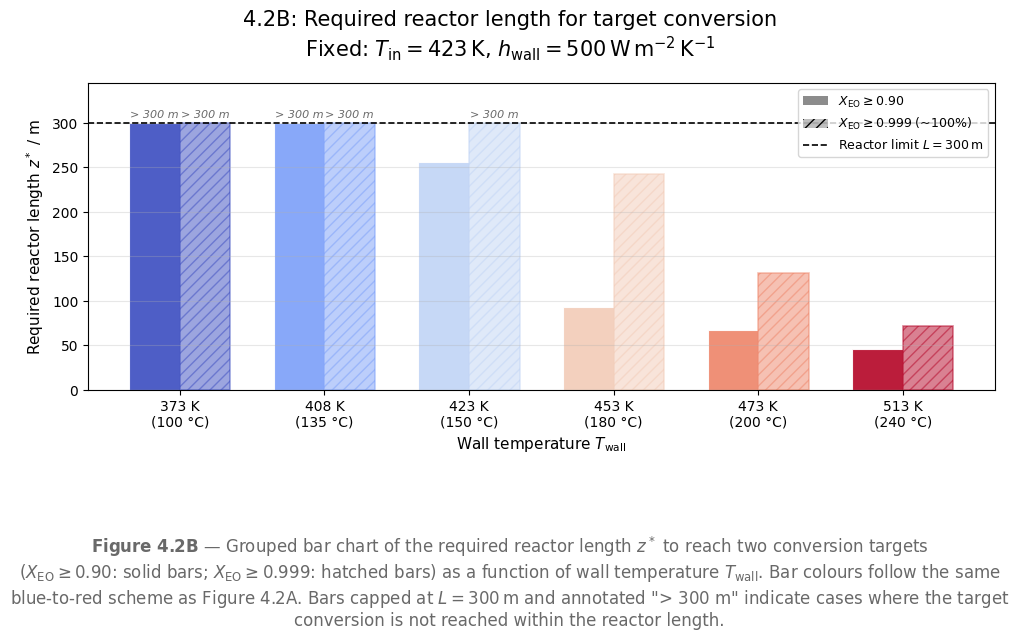

In [14]:
# ============================================================
# Section 4.2 — Bar chart: reactor length required for target conversion
#               Targets: X >= 0.90 and X >= 0.999 (~100%)
#               If target not reached within L = 300 m: bar capped at 300 m,
#               annotated with "> 300 m"
# ============================================================

X_target_95  = 0.90
X_target_100 = 0.999   # numerical proxy for "complete" conversion

def length_to_target(X_profile, z_profile, X_target):
    """Return the axial position z [m] at which X first exceeds X_target.

    If the target is never reached, returns None.
    """
    idx = np.argmax(X_profile >= X_target)   # first True index
    if X_profile[idx] < X_target:            # argmax returns 0 if never True
        return None
    return z_profile[idx]

# Collect required lengths for all T_wall cases
L_95  = []
L_100 = []

for (z, _, _, _, X) in results_42:
    L_95.append( length_to_target(X, z, X_target_95))
    L_100.append(length_to_target(X, z, X_target_100))

# --- Plotting ---
T_wall_labels = [f"{Tw:.0f} K\n({Tw - 273.15:.0f} °C)" for Tw in T_wall_values]

x_pos   = np.arange(len(T_wall_values))   # bar group positions
width   = 0.35                             # bar half-width
cap     = L_fixed                         # cap value for "not reached" bars [m]
cap_clr = "dimgray"                        # color for annotation text

fig, ax = plt.subplots(figsize=(10, 5))

for i, (l95, l100, col) in enumerate(zip(L_95, L_100, colors_42)):

    # --- X >= 0.90 bar ---
    val_95  = l95  if l95  is not None else cap
    bar_95  = ax.bar(x_pos[i] - width/2, val_95,  width, color=col, alpha=0.9,
                     edgecolor="white", linewidth=0.8, label="_nolegend_")
    if l95 is None:
        ax.text(x_pos[i] - width/2, cap + 4, "> 300 m",
                ha="center", va="bottom", fontsize=8, color=cap_clr, fontstyle="italic")

    # --- X >= 0.999 bar ---
    val_100 = l100 if l100 is not None else cap
    bar_100 = ax.bar(x_pos[i] + width/2, val_100, width, color=col, alpha=0.5,
                     edgecolor=col, linewidth=1.2, hatch="///", label="_nolegend_")
    if l100 is None:
        ax.text(x_pos[i] + width/2, cap + 4, "> 300 m",
                ha="center", va="bottom", fontsize=8, color=cap_clr, fontstyle="italic")

# Reference line at 300 m (reactor limit)
ax.axhline(cap, color="black", ls="--", lw=1.2, label=r"Reactor limit $L = 300\,\mathrm{m}$")

# Axis formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(T_wall_labels, fontsize=10)
ax.set_xlabel(r"Wall temperature $T_\mathrm{wall}$", fontsize=11)
ax.set_ylabel(r"Required reactor length $z^*$ / m", fontsize=11)
ax.set_ylim(0, cap * 1.15)
ax.grid(axis="y", alpha=0.3)

# Manual legend entries (bar style + line)
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="gray", alpha=0.9,                         label=r"$X_\mathrm{EO} \geq 0.90$"),
    Patch(facecolor="gray", alpha=0.5, hatch="///",            label=r"$X_\mathrm{EO} \geq 0.999$ (~100%)"),
    plt.Line2D([0],[0], color="black", ls="--", lw=1.2,        label=r"Reactor limit $L=300\,\mathrm{m}$"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)

# --- figure description below the legend ---
fig.text(
    0.5, -0.07,
    r"$\bf{Figure\ 4.2B}$"
    " — Grouped bar chart of the required reactor length $z^*$ to reach two conversion targets "
    "($X_\\mathrm{EO} \\geq 0.90$: solid bars; $X_\\mathrm{EO} \\geq 0.999$: hatched bars) "
    "as a function of wall temperature $T_\\mathrm{wall}$. "
    "Bar colours follow the same blue-to-red scheme as Figure 4.2A. "
    "Bars capped at $L = 300\\,\\mathrm{m}$ and annotated \"> 300 m\" indicate "
    "cases where the target conversion is not reached within the reactor length.",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig.transFigure
)

fig.suptitle(r"4.2B: Required reactor length for target conversion"
             "\n"
             r"Fixed: $T_\mathrm{in}=423\,\mathrm{K}$, $h_\mathrm{wall}=500\,\mathrm{W\,m^{-2}\,K^{-1}}$",
             fontsize=15)
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

# Print required reactor lengths for all T_wall cases
print(f"{'T_wall':>12} | {'L (X≥0.90)':>12} | {'L (X≥0.999)':>13}")
print("-" * 43)
for Tw, l95, l100 in zip(T_wall_values, L_95, L_100):
    s95  = f"{l95:.1f} m"  if l95  is not None else "> 300 m"
    s100 = f"{l100:.1f} m" if l100 is not None else "> 300 m"
    print(f"{Tw:>9.2f} K | {s95:>12} | {s100:>13}")

fig.savefig("fig_4_2_Twall_variation_wall_length.png", dpi=150, bbox_inches="tight")

In [15]:
# ============================================================
# Section 4.3 — Parameter variation: inlet temperature T_in
#               Two heating conditions (4 bar / 20 bar steam)
#               Fixed: h_W = 500 W m^-2 K^-1, L = 300 m
#               Varied: T_in from 393 K to 473 K
# ============================================================

T_in_values  = [393.0, 408.0, 423.0, 453.0, 473.0]          # [K]  (120, 135, 150, 180, 200 °C)
T_wall_4bar  = 408.15                                  # 4 bar steam  ~ 135 °C  [K]
T_wall_20bar = 473.15                                  # 20 bar steam ~ 200 °C  [K]
heating_cases = [(T_wall_4bar,  "4 bar steam ($T_\\mathrm{wall}=408\\,\\mathrm{K}$, 135 °C)"),
                 (T_wall_20bar, "20 bar steam ($T_\\mathrm{wall}=473\\,\\mathrm{K}$, 200 °C)")]

h_W_43   = 500.0    # wall heat-transfer coefficient  [W m^-2 K^-1]
L_43     = 300.0    # reactor length                  [m]
z_eval_43 = np.linspace(0.0, L_43, 3001)

def solve_Tin(T_in_val, T_wall_val):
    """Solve the PFTR for a given inlet and wall temperature.

    All other parameters held at base-case values.
    Uses the central PFTR function via args=(h_W_43, T_wall_val).
    Returns axial profiles (z, c_EO, c_EG, T, X_EO).
    """
    sol = integ.solve_ivp(
        PFTR, (0.0, L_43), [c_EO_in, 0.0, T_in_val],  # T_in_val in initial condition
        method="LSODA", t_eval=z_eval_43,
        rtol=1e-8, atol=1e-8,
        args=(h_W_43, T_wall_val),                     # h_value=500, T_wall_val varied, u at default
    )
    c_EO, c_EG, T_prof = sol.y
    X_EO = 1.0 - c_EO / c_EO_in
    return z_eval_43, c_EO, c_EG, T_prof, X_EO

# Solve all combinations
results_43 = {
    Tw: [solve_Tin(Ti, Tw) for Ti in T_in_values]
    for Tw, _ in heating_cases
}

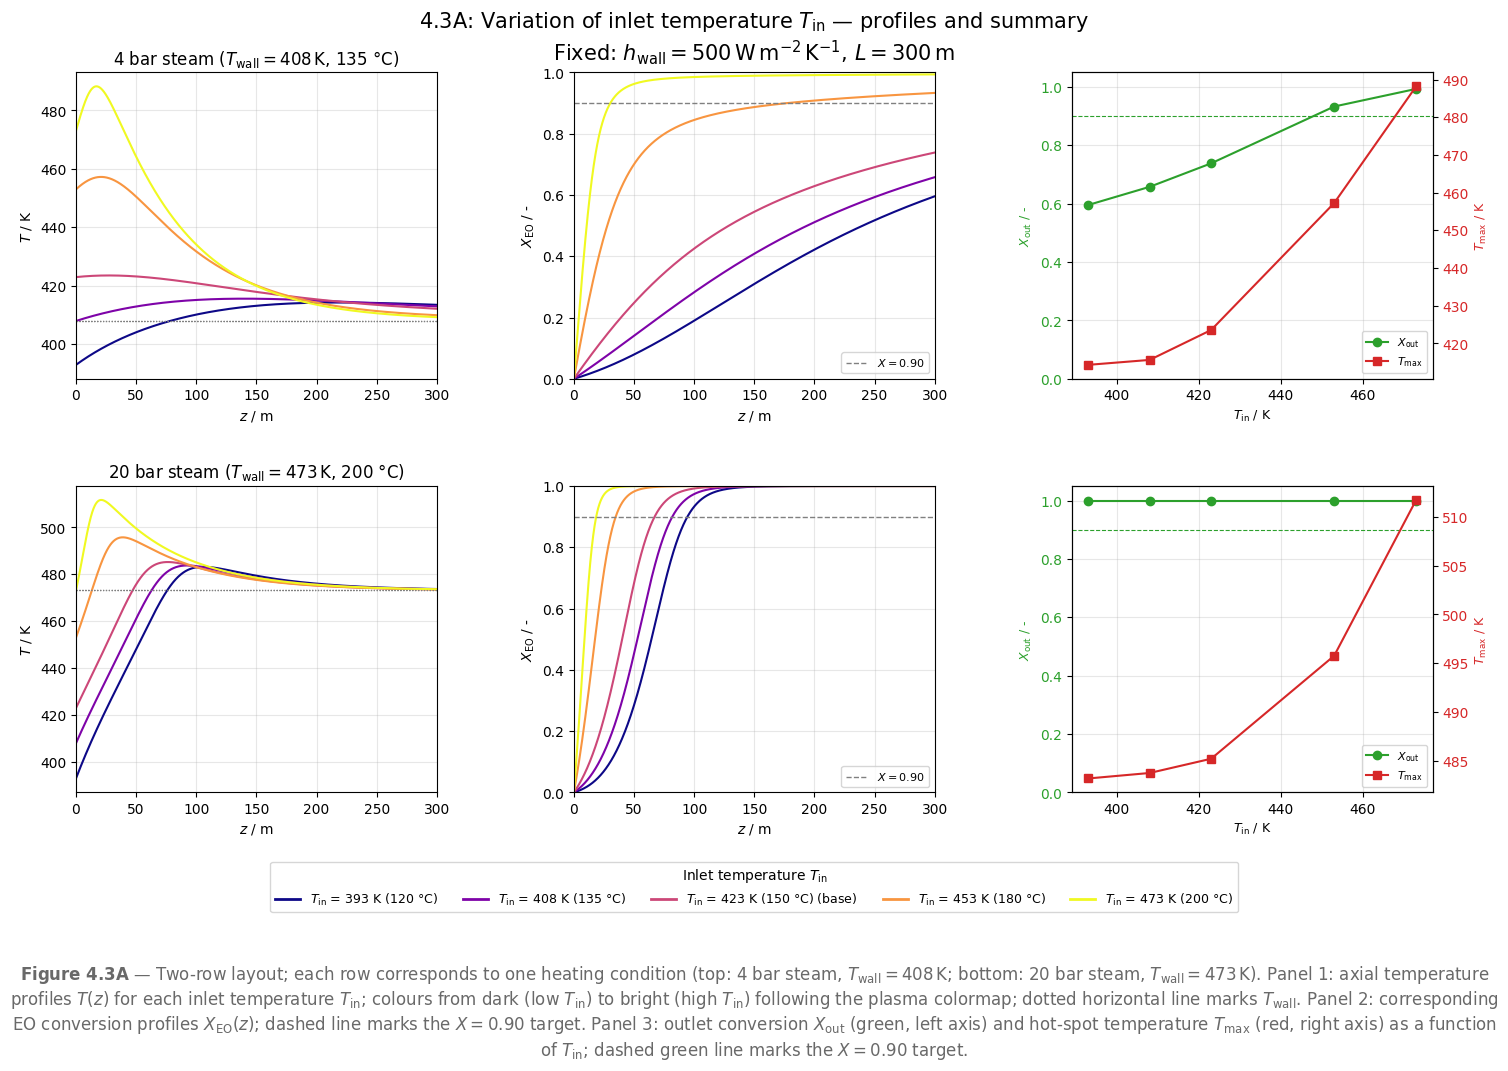

In [16]:
# ============================================================
# Section 4.3 — Plot A: profiles + summary  (2 rows x 3 cols)
#   Rows: heating condition (4 bar / 20 bar)
#   Cols: (1) T(z)  (2) X(z)  (3) X_out & T_max vs T_in
# ============================================================
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

n_Tin     = len(T_in_values)
colors_43 = [plt.cm.plasma(i / (n_Tin - 1)) for i in range(n_Tin)]

X_t90  = 0.90
X_t100 = 0.999

# Pre-collect all results for reuse in both figures
all_L90, all_L100, all_Xout, all_Tmax = {}, {}, {}, {}

fig_A, axes_A = plt.subplots(2, 3, figsize=(15, 9))

for row, (T_wall_val, wall_label) in enumerate(heating_cases):
    ax_T, ax_X, ax_S = axes_A[row]
    res_row = results_43[T_wall_val]

    L90_row, L100_row, X_out_row, T_max_row = [], [], [], []

    for (z, _, _, T_prof, X), col, Ti in zip(res_row, colors_43, T_in_values):

        ax_T.plot(z, T_prof, color=col)
        ax_X.plot(z, X,      color=col)
        ax_T.axhline(T_wall_val, color="gray", ls=":", lw=0.8)

        L90_row.append( length_to_target(X, z, X_t90))
        L100_row.append(length_to_target(X, z, X_t100))
        X_out_row.append(X[-1])
        T_max_row.append(T_prof.max())

    # store for fig_B
    all_L90[T_wall_val]  = L90_row
    all_L100[T_wall_val] = L100_row
    all_Xout[T_wall_val] = X_out_row
    all_Tmax[T_wall_val] = T_max_row

    # --- Panel 1: T(z) ---
    ax_T.set(xlabel=r"$z$ / m", ylabel=r"$T$ / K", title=wall_label)
    ax_T.set_xlim(0, L_43); ax_T.grid(alpha=0.3)

    # --- Panel 2: X(z) ---
    ax_X.axhline(X_t90, color="gray", ls="--", lw=1.0, label=r"$X=0.90$")
    ax_X.set(xlabel=r"$z$ / m", ylabel=r"$X_\mathrm{EO}$ / -")
    ax_X.set_xlim(0, L_43); ax_X.set_ylim(0, 1)
    ax_X.legend(loc="lower right", fontsize=8); ax_X.grid(alpha=0.3)

    # --- Panel 3: X_out & T_max vs T_in ---
    ax_Sb = ax_S.twinx()
    l1, = ax_S.plot( T_in_values, X_out_row, "o-", color="tab:green",
                     label=r"$X_\mathrm{out}$")
    l2, = ax_Sb.plot(T_in_values, T_max_row, "s-", color="tab:red",
                     label=r"$T_\mathrm{max}$")

    ax_S.axhline(X_t90, color="tab:green", ls="--", lw=0.8)
    ax_S.set_xlabel(r"$T_\mathrm{in}$ / K", fontsize=9)
    ax_S.set_ylabel(r"$X_\mathrm{out}$ / -",  color="tab:green", fontsize=9)
    ax_Sb.set_ylabel(r"$T_\mathrm{max}$ / K", color="tab:red",   fontsize=9)
    ax_S.tick_params(axis="y", labelcolor="tab:green")
    ax_Sb.tick_params(axis="y", labelcolor="tab:red")
    ax_S.set_ylim(0, 1.05); ax_S.grid(alpha=0.3)
    ax_S.legend(handles=[l1, l2], loc="lower right", fontsize=8)

# shared legend
tin_handles = [
    Line2D([0],[0], color=col, lw=2,
           label=f"$T_{{\\mathrm{{in}}}}$ = {Ti:.0f} K ({Ti-273.15:.0f} °C)"
                 + (" (base)" if np.isclose(Ti, 423.0) else ""))
    for col, Ti in zip(colors_43, T_in_values)
]
fig_A.legend(handles=tin_handles, loc="lower center", bbox_to_anchor=(0.5, -0.03),
             ncol=n_Tin, fontsize=9, title=r"Inlet temperature $T_\mathrm{in}$")

# --- figure description below the legend ---
fig_A.text(
    0.5, -0.08,
    r"$\bf{Figure\ 4.3A}$"
    " — Two-row layout; each row corresponds to one heating condition "
    "(top: 4 bar steam, $T_\\mathrm{wall}=408\\,\\mathrm{K}$; "
    "bottom: 20 bar steam, $T_\\mathrm{wall}=473\\,\\mathrm{K}$). "
    "Panel 1: axial temperature profiles $T(z)$ for each inlet temperature $T_\\mathrm{in}$; "
    "colours from dark (low $T_\\mathrm{in}$) to bright (high $T_\\mathrm{in}$) following the plasma colormap; "
    "dotted horizontal line marks $T_\\mathrm{wall}$. "
    "Panel 2: corresponding EO conversion profiles $X_\\mathrm{EO}(z)$; "
    "dashed line marks the $X = 0.90$ target. "
    "Panel 3: outlet conversion $X_\\mathrm{out}$ (green, left axis) and hot-spot temperature "
    "$T_\\mathrm{max}$ (red, right axis) as a function of $T_\\mathrm{in}$; "
    "dashed green line marks the $X = 0.90$ target.",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig_A.transFigure
)

fig_A.suptitle(
    r"4.3A: Variation of inlet temperature $T_\mathrm{in}$ — profiles and summary"
    "\n"
    r"Fixed: $h_\mathrm{wall}=500\,\mathrm{W\,m^{-2}\,K^{-1}}$, $L=300\,\mathrm{m}$",
    fontsize=15)
fig_A.tight_layout()
fig_A.subplots_adjust(top=0.91, bottom=0.11, hspace=0.35, wspace=0.38)
fig_A.savefig("fig_4_3A_Tin_profiles.png", dpi=150, bbox_inches="tight")

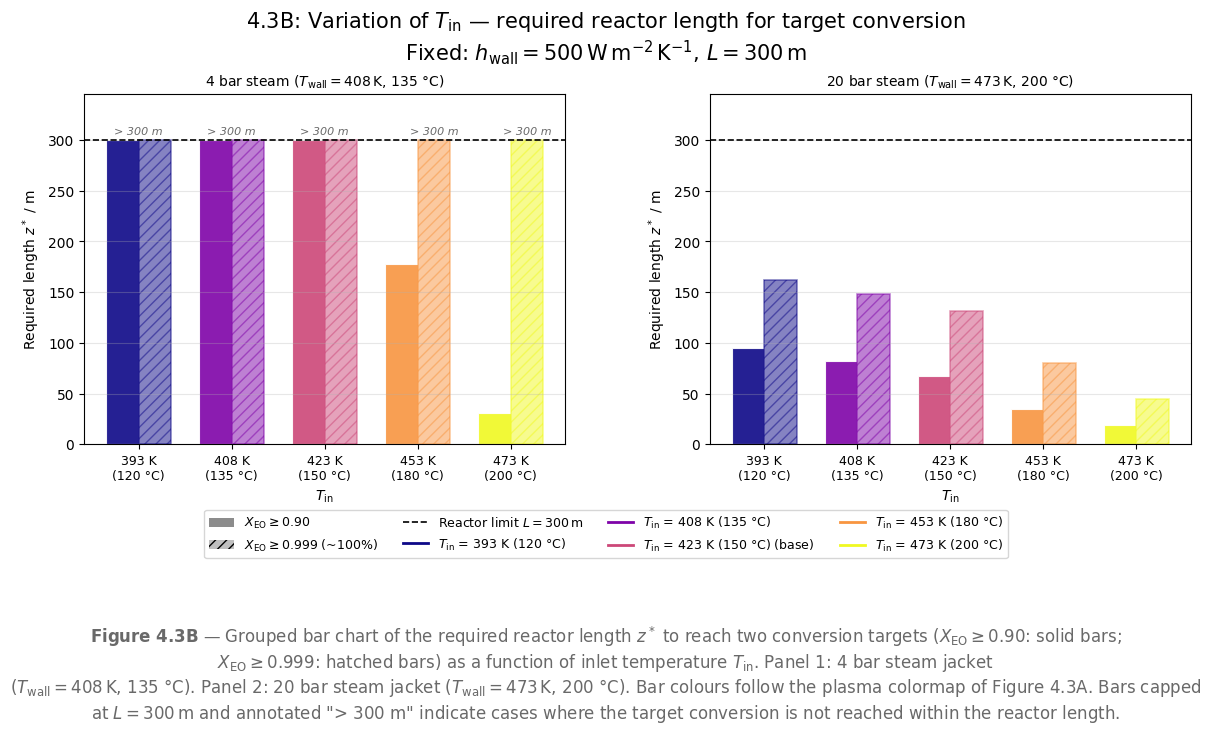

In [17]:
# ============================================================
# Section 4.3 — Plot B: required reactor length  (1 row x 2 cols)
#   Cols: (1) 4 bar steam  (2) 20 bar steam
# ============================================================
fig_B, axes_B = plt.subplots(1, 2, figsize=(12, 5))

for col_idx, (T_wall_val, wall_label) in enumerate(heating_cases):
    ax_B = axes_B[col_idx]
    L90_row  = all_L90[T_wall_val]
    L100_row = all_L100[T_wall_val]

    x_pos = np.arange(n_Tin)
    width = 0.35
    cap   = L_43

    for i, (l90, l100, col) in enumerate(zip(L90_row, L100_row, colors_43)):
        val_90  = l90  if l90  is not None else cap
        val_100 = l100 if l100 is not None else cap

        ax_B.bar(x_pos[i] - width/2, val_90,  width, color=col, alpha=0.9,
                 edgecolor="white", linewidth=0.8)
        ax_B.bar(x_pos[i] + width/2, val_100, width, color=col, alpha=0.5,
                 edgecolor=col, linewidth=1.2, hatch="///")

        if l90 is None and l100 is None:
            ax_B.text(x_pos[i], cap + 4, "> 300 m",
                      ha="center", va="bottom", fontsize=8,
                      color="dimgray", fontstyle="italic")
        else:
            if l90 is None:
                ax_B.text(x_pos[i] - width/2, cap + 4, "> 300 m",
                          ha="center", va="bottom", fontsize=8,
                          color="dimgray", fontstyle="italic")
            if l100 is None:
                ax_B.text(x_pos[i] + width/2, cap + 4, "> 300 m",
                          ha="center", va="bottom", fontsize=8,
                          color="dimgray", fontstyle="italic")

    ax_B.axhline(cap, color="black", ls="--", lw=1.2)
    ax_B.set_xticks(x_pos)
    ax_B.set_xticklabels(
        [f"{Ti:.0f} K\n({Ti-273.15:.0f} °C)" for Ti in T_in_values], fontsize=9)
    ax_B.set_xlabel(r"$T_\mathrm{in}$", fontsize=10)
    ax_B.set_ylabel(r"Required length $z^*$ / m", fontsize=10)
    ax_B.set_ylim(0, cap * 1.15)
    ax_B.set_title(wall_label, fontsize=10)
    ax_B.grid(axis="y", alpha=0.3)

# shared legend
bar_handles = [
    Patch(facecolor="gray", alpha=0.9,              label=r"$X_\mathrm{EO} \geq 0.90$"),
    Patch(facecolor="gray", alpha=0.5, hatch="///", label=r"$X_\mathrm{EO} \geq 0.999$ (~100%)"),
    Line2D([0],[0], color="black", ls="--", lw=1.2,  label=r"Reactor limit $L = 300\,\mathrm{m}$"),
] + tin_handles

fig_B.legend(handles=bar_handles, loc="lower center", bbox_to_anchor=(0.5, -0.06),
             ncol=4, fontsize=9)

# --- figure description below the legend ---
fig_B.text(
    0.5, -0.18,
    r"$\bf{Figure\ 4.3B}$"
    " — Grouped bar chart of the required reactor length $z^*$ to reach two conversion targets "
    "($X_\\mathrm{EO} \\geq 0.90$: solid bars; $X_\\mathrm{EO} \\geq 0.999$: hatched bars) "
    "as a function of inlet temperature $T_\\mathrm{in}$. "
    "Panel 1: 4 bar steam jacket ($T_\\mathrm{wall} = 408\\,\\mathrm{K}$, 135 °C). "
    "Panel 2: 20 bar steam jacket ($T_\\mathrm{wall} = 473\\,\\mathrm{K}$, 200 °C). "
    "Bar colours follow the plasma colormap of Figure 4.3A. "
    "Bars capped at $L = 300\\,\\mathrm{m}$ and annotated \"> 300 m\" indicate "
    "cases where the target conversion is not reached within the reactor length.",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig_B.transFigure
)

fig_B.suptitle(
    r"4.3B: Variation of $T_\mathrm{in}$ — required reactor length for target conversion"
    "\n"
    r"Fixed: $h_\mathrm{wall}=500\,\mathrm{W\,m^{-2}\,K^{-1}}$, $L=300\,\mathrm{m}$",
    fontsize=15, y = 1.05)
fig_B.tight_layout()
fig_B.subplots_adjust(top=0.88, bottom=0.18, wspace=0.3)
fig_B.savefig("fig_4_3B_Tin_lengths.png", dpi=150, bbox_inches="tight")

In [18]:
# ============================================================
# Section 4.4 — Parameter variation: inlet concentration c_EO,in
#               "Optimised" base conditions from sections 4.2/4.3:
#               T_in = 473 K (200 °C, pre-heated via heat exchanger)
#               L   = 150 m, h_W = 500 W m^-2 K^-1
#               Two heating cases: 4 bar / 20 bar steam wall
# ============================================================

c_EO_in_values = [0.5e3, 1.0e3, 2.27e3, 4.0e3]   # [mol m^-3]  (converted from mol/L)
c_EO_in_labels_mol_L = [0.5, 1.0, 2.27, 4.0]      # [mol/L]     (for labels only)

T_in_44   = 473.0    # inlet temperature: 200 °C pre-heated  [K]
L_44      = 150.0    # reduced reactor length                 [m]
h_W_44    = 500.0    # wall heat-transfer coefficient         [W m^-2 K^-1]

z_eval_44 = np.linspace(0.0, L_44, 3001)

def solve_cEO(c_EO_in_val, T_wall_val):
    """Solve the PFTR for a given inlet concentration and wall temperature.

    All other parameters held at optimised values (T_in=473 K, L=150 m).
    Uses the central PFTR function via args=(h_W_44, T_wall_val).
    Returns axial profiles (z, c_EO, c_EG, T, X_EO).
    """
    sol = integ.solve_ivp(
        PFTR, (0.0, L_44), [c_EO_in_val, 0.0, T_in_44],  # c_EO_in_val and T_in_44 in initial condition
        method="LSODA", t_eval=z_eval_44,
        rtol=1e-8, atol=1e-8,
        args=(h_W_44, T_wall_val),                        # h_value=500, T_wall_val varied, u at default
    )
    c_EO, c_EG, T_prof = sol.y
    X_EO = 1.0 - c_EO / c_EO_in_val                      # normalised to the varied inlet concentration
    return z_eval_44, c_EO, c_EG, T_prof, X_EO

# Solve all combinations
results_44 = {
    Tw: [solve_cEO(c, Tw) for c in c_EO_in_values]
    for Tw, _ in heating_cases
}

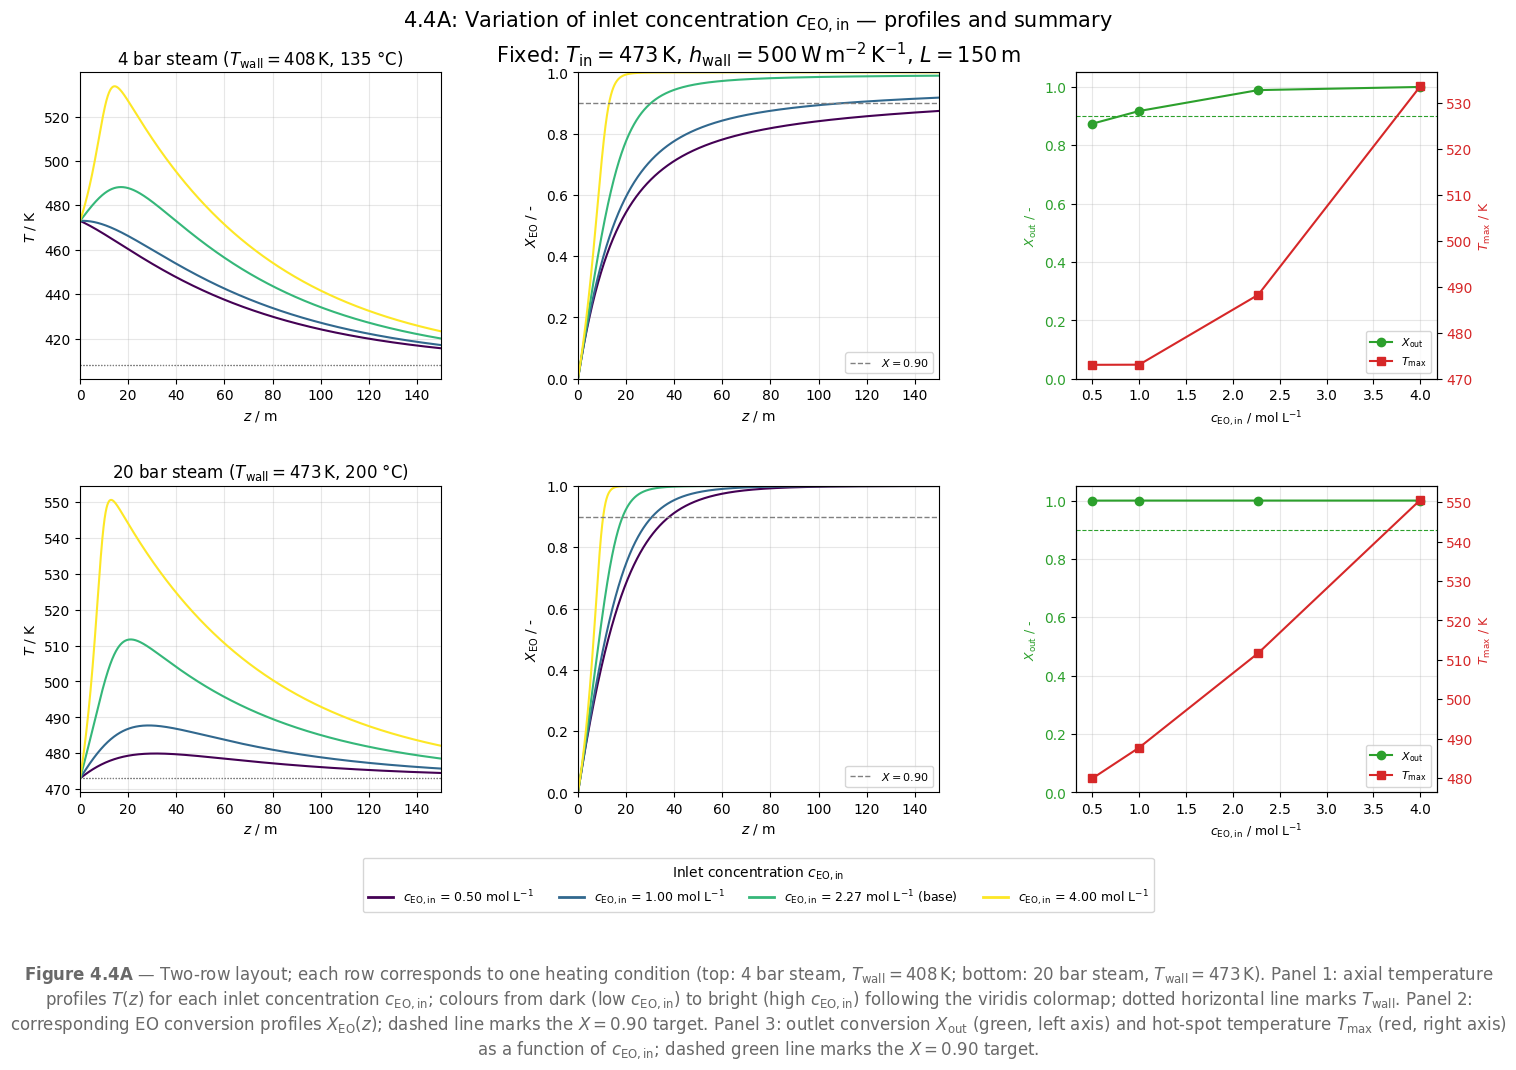

In [19]:
# ============================================================
# Section 4.4 — Plot A: profiles + summary  (2 rows x 3 cols)
#   Rows: heating condition (4 bar / 20 bar)
#   Cols: (1) T(z)  (2) X(z)  (3) X_out & T_max vs c_EO,in
# ============================================================
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

n_c44     = len(c_EO_in_values)
colors_44 = [plt.cm.viridis(i / (n_c44 - 1)) for i in range(n_c44)]

X_t90  = 0.90
X_t100 = 0.999

# Storage for fig_B
all_L90_44, all_L100_44 = {}, {}

fig_44A, axes_44A = plt.subplots(2, 3, figsize=(15, 9))

for row, (T_wall_val, wall_label) in enumerate(heating_cases):
    ax_T, ax_X, ax_S = axes_44A[row]
    res_row = results_44[T_wall_val]

    L90_row, L100_row, X_out_row, T_max_row = [], [], [], []

    for (z, _, _, T_prof, X), col, c_val in zip(res_row, colors_44, c_EO_in_labels_mol_L):

        ax_T.plot(z, T_prof, color=col)
        ax_X.plot(z, X,      color=col)
        ax_T.axhline(T_wall_val, color="gray", ls=":", lw=0.8)

        L90_row.append( length_to_target(X, z, X_t90))
        L100_row.append(length_to_target(X, z, X_t100))
        X_out_row.append(X[-1])
        T_max_row.append(T_prof.max())

    all_L90_44[T_wall_val]  = L90_row
    all_L100_44[T_wall_val] = L100_row

    # --- Panel 1: T(z) ---
    ax_T.set(xlabel=r"$z$ / m", ylabel=r"$T$ / K", title=wall_label)
    ax_T.set_xlim(0, L_44); ax_T.grid(alpha=0.3)

    # --- Panel 2: X(z) ---
    ax_X.axhline(X_t90, color="gray", ls="--", lw=1.0, label=r"$X=0.90$")
    ax_X.set(xlabel=r"$z$ / m", ylabel=r"$X_\mathrm{EO}$ / -")
    ax_X.set_xlim(0, L_44); ax_X.set_ylim(0, 1)
    ax_X.legend(loc="lower right", fontsize=8); ax_X.grid(alpha=0.3)

    # --- Panel 3: X_out & T_max vs c_EO,in ---
    ax_Sb = ax_S.twinx()
    l1, = ax_S.plot( c_EO_in_labels_mol_L, X_out_row, "o-", color="tab:green",
                     label=r"$X_\mathrm{out}$")
    l2, = ax_Sb.plot(c_EO_in_labels_mol_L, T_max_row, "s-", color="tab:red",
                     label=r"$T_\mathrm{max}$")

    ax_S.axhline(X_t90, color="tab:green", ls="--", lw=0.8)
    ax_S.set_xlabel(r"$c_\mathrm{EO,in}$ / mol L$^{-1}$", fontsize=9)
    ax_S.set_ylabel(r"$X_\mathrm{out}$ / -",  color="tab:green", fontsize=9)
    ax_Sb.set_ylabel(r"$T_\mathrm{max}$ / K", color="tab:red",   fontsize=9)
    ax_S.tick_params(axis="y", labelcolor="tab:green")
    ax_Sb.tick_params(axis="y", labelcolor="tab:red")
    ax_S.set_ylim(0, 1.05); ax_S.grid(alpha=0.3)
    ax_S.legend(handles=[l1, l2], loc="lower right", fontsize=8)

# shared legend
c_handles_44 = [
    Line2D([0],[0], color=col, lw=2,
           label=rf"$c_\mathrm{{EO,in}}$ = {c_val:.2f} mol L$^{{-1}}$"
                 + (" (base)" if np.isclose(c_val, 2.27) else ""))
    for col, c_val in zip(colors_44, c_EO_in_labels_mol_L)
]
fig_44A.legend(handles=c_handles_44, loc="lower center", bbox_to_anchor=(0.5, -0.03),
               ncol=n_c44, fontsize=9,
               title=r"Inlet concentration $c_\mathrm{EO,in}$")

# --- figure description below the legend ---
fig_44A.text(
    0.5, -0.08,
    r"$\bf{Figure\ 4.4A}$"
    " — Two-row layout; each row corresponds to one heating condition "
    "(top: 4 bar steam, $T_\\mathrm{wall}=408\\,\\mathrm{K}$; "
    "bottom: 20 bar steam, $T_\\mathrm{wall}=473\\,\\mathrm{K}$). "
    "Panel 1: axial temperature profiles $T(z)$ for each inlet concentration $c_\\mathrm{EO,in}$; "
    "colours from dark (low $c_\\mathrm{EO,in}$) to bright (high $c_\\mathrm{EO,in}$) "
    "following the viridis colormap; "
    "dotted horizontal line marks $T_\\mathrm{wall}$. "
    "Panel 2: corresponding EO conversion profiles $X_\\mathrm{EO}(z)$; "
    "dashed line marks the $X = 0.90$ target. "
    "Panel 3: outlet conversion $X_\\mathrm{out}$ (green, left axis) and hot-spot temperature "
    "$T_\\mathrm{max}$ (red, right axis) as a function of $c_\\mathrm{EO,in}$; "
    "dashed green line marks the $X = 0.90$ target.",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig_44A.transFigure
)

fig_44A.suptitle(
    r"4.4A: Variation of inlet concentration $c_\mathrm{EO,in}$ — profiles and summary"
    "\n"
    r"Fixed: $T_\mathrm{in}=473\,\mathrm{K}$, $h_\mathrm{wall}=500\,\mathrm{W\,m^{-2}\,K^{-1}}$, $L=150\,\mathrm{m}$",
    fontsize=15)
fig_44A.tight_layout()
fig_44A.subplots_adjust(top=0.91, bottom=0.11, hspace=0.35, wspace=0.38)
fig_44A.savefig("fig_4_4A_cEO_profiles.png", dpi=150, bbox_inches="tight")

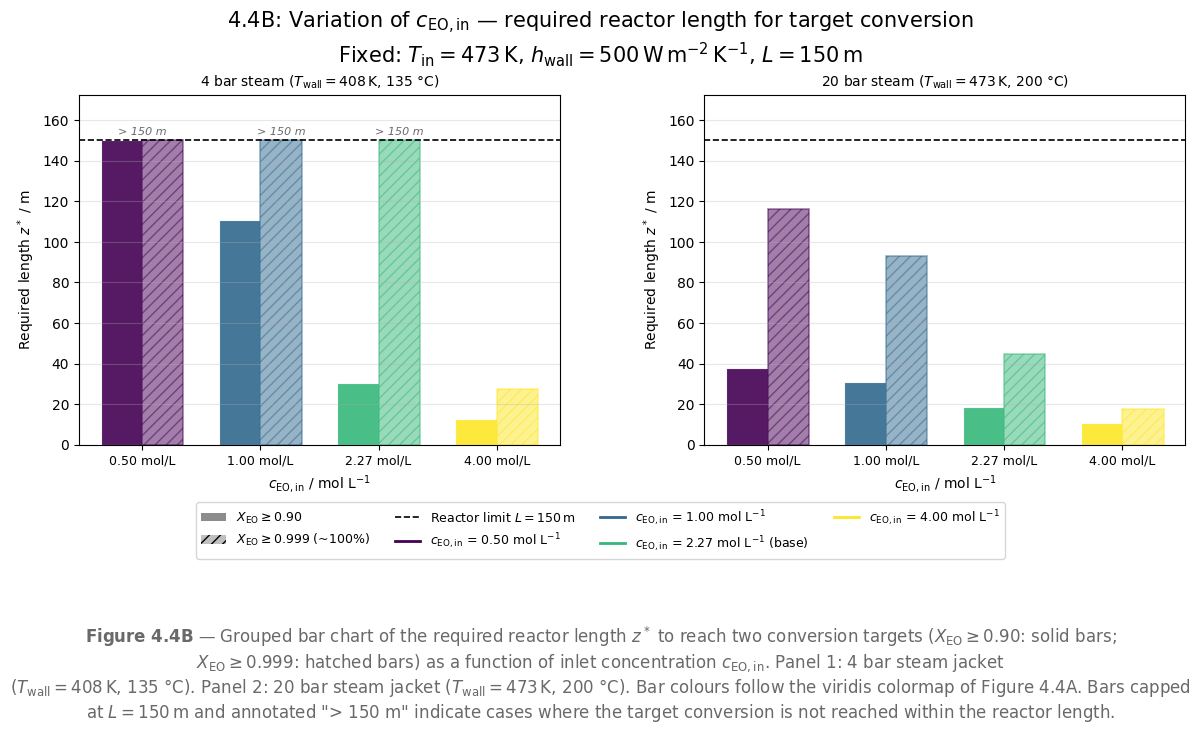

In [20]:
# ============================================================
# Section 4.4 — Plot B: required reactor length  (1 row x 2 cols)
#   Cols: (1) 4 bar steam  (2) 20 bar steam
# ============================================================
fig_44B, axes_44B = plt.subplots(1, 2, figsize=(12, 5))

for col_idx, (T_wall_val, wall_label) in enumerate(heating_cases):
    ax_B = axes_44B[col_idx]
    L90_row  = all_L90_44[T_wall_val]
    L100_row = all_L100_44[T_wall_val]

    x_pos = np.arange(n_c44)
    width = 0.35
    cap   = L_44

    for i, (l90, l100, col) in enumerate(zip(L90_row, L100_row, colors_44)):
        val_90  = l90  if l90  is not None else cap
        val_100 = l100 if l100 is not None else cap

        ax_B.bar(x_pos[i] - width/2, val_90,  width, color=col, alpha=0.9,
                 edgecolor="white", linewidth=0.8)
        ax_B.bar(x_pos[i] + width/2, val_100, width, color=col, alpha=0.5,
                 edgecolor=col, linewidth=1.2, hatch="///")

        if l90 is None and l100 is None:
            ax_B.text(x_pos[i], cap + 2, "> 150 m",
                      ha="center", va="bottom", fontsize=8,
                      color="dimgray", fontstyle="italic")
        else:
            if l90 is None:
                ax_B.text(x_pos[i] - width/2, cap + 2, "> 150 m",
                          ha="center", va="bottom", fontsize=8,
                          color="dimgray", fontstyle="italic")
            if l100 is None:
                ax_B.text(x_pos[i] + width/2, cap + 2, "> 150 m",
                          ha="center", va="bottom", fontsize=8,
                          color="dimgray", fontstyle="italic")

    ax_B.axhline(cap, color="black", ls="--", lw=1.2)
    ax_B.set_xticks(x_pos)
    ax_B.set_xticklabels(
        [f"{c:.2f} mol/L" for c in c_EO_in_labels_mol_L], fontsize=9)
    ax_B.set_xlabel(r"$c_\mathrm{EO,in}$ / mol L$^{-1}$", fontsize=10)
    ax_B.set_ylabel(r"Required length $z^*$ / m", fontsize=10)
    ax_B.set_ylim(0, cap * 1.15)
    ax_B.set_title(wall_label, fontsize=10)
    ax_B.grid(axis="y", alpha=0.3)

bar_handles_44 = [
    Patch(facecolor="gray", alpha=0.9,              label=r"$X_\mathrm{EO} \geq 0.90$"),
    Patch(facecolor="gray", alpha=0.5, hatch="///", label=r"$X_\mathrm{EO} \geq 0.999$ (~100%)"),
    Line2D([0],[0], color="black", ls="--", lw=1.2,  label=r"Reactor limit $L = 150\,\mathrm{m}$"),
] + c_handles_44

fig_44B.legend(handles=bar_handles_44, loc="lower center", bbox_to_anchor=(0.5, -0.06),
               ncol=4, fontsize=9)

# --- figure description below the legend ---
fig_44B.text(
    0.5, -0.18,
    r"$\bf{Figure\ 4.4B}$"
    " — Grouped bar chart of the required reactor length $z^*$ to reach two conversion targets "
    "($X_\\mathrm{EO} \\geq 0.90$: solid bars; $X_\\mathrm{EO} \\geq 0.999$: hatched bars) "
    "as a function of inlet concentration $c_\\mathrm{EO,in}$. "
    "Panel 1: 4 bar steam jacket ($T_\\mathrm{wall} = 408\\,\\mathrm{K}$, 135 °C). "
    "Panel 2: 20 bar steam jacket ($T_\\mathrm{wall} = 473\\,\\mathrm{K}$, 200 °C). "
    "Bar colours follow the viridis colormap of Figure 4.4A. "
    "Bars capped at $L = 150\\,\\mathrm{m}$ and annotated \"> 150 m\" indicate "
    "cases where the target conversion is not reached within the reactor length.",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig_44B.transFigure
)

fig_44B.suptitle(
    r"4.4B: Variation of $c_\mathrm{EO,in}$ — required reactor length for target conversion"
    "\n"
    r"Fixed: $T_\mathrm{in}=473\,\mathrm{K}$, $h_\mathrm{wall}=500\,\mathrm{W\,m^{-2}\,K^{-1}}$, $L=150\,\mathrm{m}$",
    fontsize=15, y = 1.05)
fig_44B.tight_layout()
fig_44B.subplots_adjust(top=0.88, bottom=0.18, wspace=0.3)
fig_44B.savefig("fig_4_4B_cEO_lengths.png", dpi=150, bbox_inches="tight")

In [21]:
# ============================================================
# Section 4.5 — Batch reactor model
#               Cylindrical vessel, V_R = 15 m^3, H/D = 1
#               Heating via steam jacket: h_W = 500 W m^-2 K^-1
#               Same heating cases as PFTR: 4 bar / 20 bar steam
# ============================================================

# --- Batch reactor geometry (H/D = 1 -> H = D) ---
V_R_batch = 15.0                                    # reactor volume            [m^3]
D_batch   = (4.0 * V_R_batch / np.pi) ** (1/3)     # diameter from V = pi/4 D^2 H, H=D [m]
H_batch   = D_batch                                 # height = diameter (H/D = 1)  [m]

# Wall area: cylindrical mantle + bottom disk (no top lid assumed sealed/insulated)
A_mantle  = np.pi * D_batch * H_batch               # lateral surface area      [m^2]
A_bottom  = np.pi * D_batch**2 / 4.0               # bottom disk area          [m^2]
A_wall_batch = A_mantle + A_bottom                  # total heat exchange area  [m^2]

# Ratio A/V for reference (analogous to 4/d_R in the PFTR)
AV_batch  = A_wall_batch / V_R_batch                # [m^-1]

print("Batch reactor geometry:")
print(f"  Volume      V_R   = {V_R_batch:.2f} m^3")
print(f"  Diameter    D     = {D_batch:.3f} m")
print(f"  Height      H     = {H_batch:.3f} m")
print(f"  Mantle area       = {A_mantle:.3f} m^2")
print(f"  Bottom area       = {A_bottom:.3f} m^2")
print(f"  Total wall area   = {A_wall_batch:.3f} m^2")
print(f"  A/V ratio         = {AV_batch:.4f} m^-1  (PFTR: 4/d_R = {4/d_R:.1f} m^-1)")

# --- Batch reactor ODE system ---
h_W_batch = 500.0    # wall heat-transfer coefficient, same as PFTR  [W m^-2 K^-1]

def batch_reactor(t, f, T_wall_val):
    """RHS of the batch reactor ODE system in the time coordinate t.

    State vector f = [c_EO, c_EG, T].

    Material balances (Guettel, analogous to bSTR example):
        dc_EO/dt = -r
        dc_EG/dt = +r

    Energy balance (Guettel Eq. for polytropic bSTR):
        dT/dt = (-dH_R * r) / (rho * c_p)
                - (h_W * A_wall) / (V_R * rho * c_p) * (T - T_wall)

    Note: the geometric factor A_wall/V_R plays the same role as
    4/d_R in the PFTR energy balance, but reflects the different
    surface-to-volume ratio of a stirred vessel vs. a tube.
    """
    c_EO, c_EG, T = f

    r = kinetics(T, c_EO)                           # reaction rate  [mol m^-3 s^-1]

    dc_EO_dt = -r                                   # EO consumed    [mol m^-3 s^-1]
    dc_EG_dt = +r                                   # EG formed      [mol m^-3 s^-1]

    # heat released by reaction - heat removed through wall
    dT_dt = ((-dH_R * r) / (rho * c_p)
             - (h_W_batch * A_wall_batch) / (V_R_batch * rho * c_p) * (T - T_wall_val))

    return [dc_EO_dt, dc_EG_dt, dT_dt]


def solve_batch(T_wall_val, X_stop=0.95, t_max=7200.0):
    """Integrate the batch reactor until X_EO >= X_stop or t_max is reached.

    Uses a terminal event to stop integration exactly at the target conversion,
    avoiding unnecessary integration time after the target is met.

    Parameters
    ----------
    T_wall_val : float   Wall (steam jacket) temperature  [K]
    X_stop     : float   Target conversion to stop at     [-]
    t_max      : float   Maximum integration time         [s]

    Returns
    -------
    t    : array   Time grid                              [s]
    c_EO : array   EO concentration profile               [mol m^-3]
    c_EG : array   EG concentration profile               [mol m^-3]
    T    : array   Temperature profile                    [K]
    X    : array   Conversion profile                     [-]
    t_95 : float   Time to reach X_stop (None if not reached within t_max)
    """
    c_EO_in_batch = 2.27e3    # inlet concentration, same as comparison case  [mol m^-3]

    # Terminal event: stop when X_EO reaches X_stop
    def event_conversion(t, f, T_wall_val):
        c_EO = f[0]
        return (1.0 - c_EO / c_EO_in_batch) - X_stop   # zero crossing at X = X_stop

    event_conversion.terminal  = True    # stop integration at this event
    event_conversion.direction = 1       # only trigger on upward crossing

    f_init  = [c_EO_in_batch, 0.0, T_in_44]             # [c_EO, c_EG, T] at t=0
    t_span  = (0.0, t_max)
    t_eval  = np.linspace(0.0, t_max, 5001)

    sol = integ.solve_ivp(
        batch_reactor, t_span, f_init,
        args=(T_wall_val,),                              # pass T_wall to RHS
        method="LSODA",
        t_eval=t_eval,
        events=event_conversion,
        rtol=1e-8, atol=1e-8
    )

    c_EO = sol.y[0]
    c_EG = sol.y[1]
    T    = sol.y[2]
    t    = sol.t
    X    = 1.0 - c_EO / c_EO_in_batch

    # Extract time at which target conversion was reached
    t_95 = sol.t_events[0][0] if len(sol.t_events[0]) > 0 else None

    return t, c_EO, c_EG, T, X, t_95


# --- Solve both heating cases ---
results_batch = {}
for T_wall_val, wall_label in heating_cases:
    t, c_EO, c_EG, T, X, t_95 = solve_batch(T_wall_val)
    results_batch[T_wall_val] = (t, c_EO, c_EG, T, X, t_95)
    t_str = f"{t_95:.1f} s ({t_95/60:.1f} min)" if t_95 is not None else "> 7200 s"
    print(f"  T_wall = {T_wall_val:.2f} K: X=0.95 reached at t = {t_str}")

Batch reactor geometry:
  Volume      V_R   = 15.00 m^3
  Diameter    D     = 2.673 m
  Height      H     = 2.673 m
  Mantle area       = 22.447 m^2
  Bottom area       = 5.612 m^2
  Total wall area   = 28.058 m^2
  A/V ratio         = 1.8706 m^-1  (PFTR: 4/d_R = 133.3 m^-1)
  T_wall = 408.15 K: X=0.95 reached at t = 20.1 s (0.3 min)
  T_wall = 473.15 K: X=0.95 reached at t = 20.0 s (0.3 min)


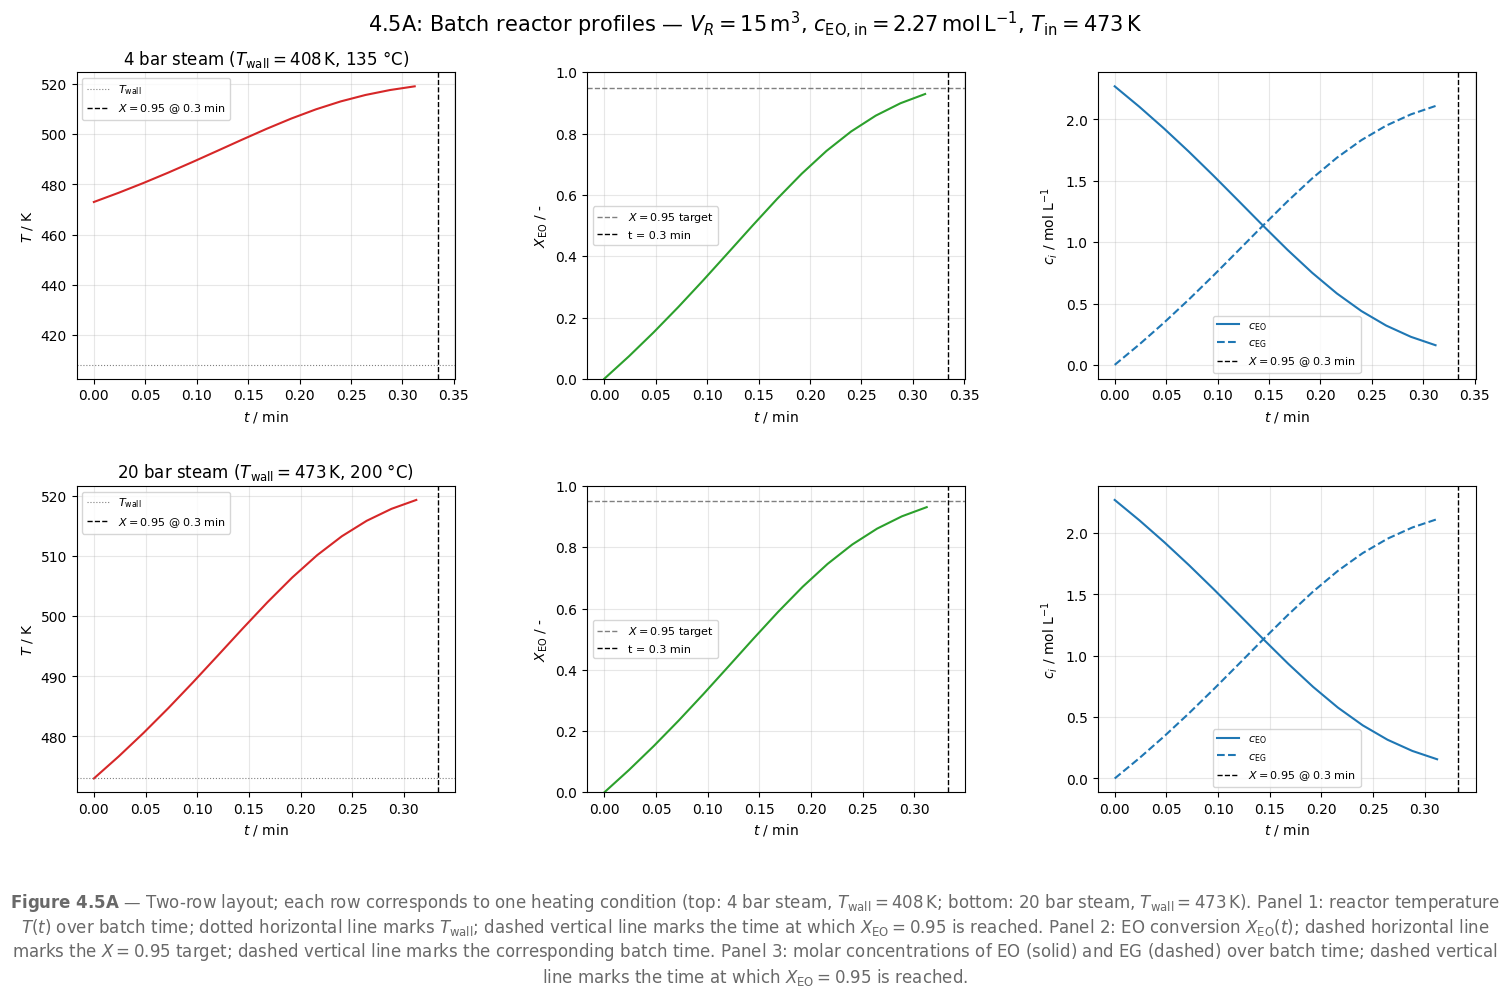

In [22]:
# ============================================================
# Section 4.5 — Batch reactor: profile plot (2 rows x 3 cols)
#   Rows: heating condition (4 bar / 20 bar)
#   Cols: (1) T(t)  (2) X(t)  (3) c_EO & c_EG(t)
# ============================================================

fig_batch, axes_batch = plt.subplots(2, 3, figsize=(15, 9))

for row, (T_wall_val, wall_label) in enumerate(heating_cases):
    ax_T, ax_X, ax_C = axes_batch[row]
    t, c_EO, c_EG, T, X, t_95 = results_batch[T_wall_val]

    # --- Panel 1: Temperature profile ---
    ax_T.plot(t / 60, T, color="tab:red")
    ax_T.axhline(T_wall_val, color="gray", ls=":", lw=0.8,
                 label=r"$T_\mathrm{wall}$")
    if t_95 is not None:
        ax_T.axvline(t_95 / 60, color="black", ls="--", lw=1.0,
                     label=f"$X=0.95$ @ {t_95/60:.1f} min")
    ax_T.set(xlabel=r"$t$ / min", ylabel=r"$T$ / K", title=wall_label)
    ax_T.legend(fontsize=8); ax_T.grid(alpha=0.3)

    # --- Panel 2: Conversion profile ---
    ax_X.plot(t / 60, X, color="tab:green")
    ax_X.axhline(0.95, color="gray", ls="--", lw=1.0, label=r"$X=0.95$ target")
    if t_95 is not None:
        ax_X.axvline(t_95 / 60, color="black", ls="--", lw=1.0,
                     label=f"t = {t_95/60:.1f} min")
    ax_X.set(xlabel=r"$t$ / min", ylabel=r"$X_\mathrm{EO}$ / -")
    ax_X.set_ylim(0, 1); ax_X.legend(fontsize=8); ax_X.grid(alpha=0.3)

    # --- Panel 3: Concentration profiles ---
    ax_C.plot(t / 60, c_EO / 1e3, color="tab:blue",  label=r"$c_\mathrm{EO}$")
    ax_C.plot(t / 60, c_EG / 1e3, color="tab:blue",  label=r"$c_\mathrm{EG}$", ls="--")
    if t_95 is not None:
        ax_C.axvline(t_95 / 60, color="black", ls="--", lw=1.0,
                     label=f"$X=0.95$ @ {t_95/60:.1f} min")
    ax_C.set(xlabel=r"$t$ / min",
             ylabel=r"$c_i$ / mol L$^{-1}$")
    ax_C.legend(fontsize=8); ax_C.grid(alpha=0.3)

# --- figure description below the figure ---
fig_batch.text(
    0.5, 0,
    r"$\bf{Figure\ 4.5A}$"
    " — Two-row layout; each row corresponds to one heating condition "
    "(top: 4 bar steam, $T_\\mathrm{wall}=408\\,\\mathrm{K}$; "
    "bottom: 20 bar steam, $T_\\mathrm{wall}=473\\,\\mathrm{K}$). "
    "Panel 1: reactor temperature $T(t)$ over batch time; "
    "dotted horizontal line marks $T_\\mathrm{wall}$; "
    "dashed vertical line marks the time at which $X_\\mathrm{EO} = 0.95$ is reached. "
    "Panel 2: EO conversion $X_\\mathrm{EO}(t)$; "
    "dashed horizontal line marks the $X = 0.95$ target; "
    "dashed vertical line marks the corresponding batch time. "
    "Panel 3: molar concentrations of EO (solid) and EG (dashed) over batch time; "
    "dashed vertical line marks the time at which $X_\\mathrm{EO} = 0.95$ is reached.",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig_batch.transFigure
)

fig_batch.suptitle(
    r"4.5A: Batch reactor profiles — $V_R = 15\,\mathrm{m^3}$, "
    r"$c_\mathrm{EO,in} = 2.27\,\mathrm{mol\,L^{-1}}$, "
    r"$T_\mathrm{in} = 473\,\mathrm{K}$",
    fontsize=15)
fig_batch.tight_layout()
fig_batch.subplots_adjust(top=0.91, bottom=0.11, hspace=0.35, wspace=0.35)
fig_batch.savefig("fig_4_5A_batch_profiles.png", dpi=150, bbox_inches="tight")

In [23]:
# ============================================================
# Section 4.5 — Throughput comparison: Batch vs PFTR
#               Shift duration: 8 hours = 28800 s
#               Batch overhead: 20 min = 1200 s between batches
#               PFTR: continuous operation for full shift duration
# ============================================================

t_shift    = 8.0 * 3600.0    # shift duration                        [s]
t_overhead = 20.0 * 60.0     # batch turnaround time (drain, test,
                              # reload, restart)                      [s]
c_EO_comp  = 2.27e3          # inlet concentration, comparison case  [mol m^-3]
X_batch    = 0.95            # batch target conversion               [-]

# --- PFTR throughput ---
# Volumetric flow rate: Q = u * A_cross = u * pi/4 * d_R^2
A_cross   = np.pi / 4.0 * d_R**2                   # tube cross-section        [m^2]
Q_pftr    = u * A_cross                             # volumetric flow rate      [m^3 s^-1]

# Molar throughput per second: n_dot = Q * c_EO_out
# c_EO_out from the 150 m PFTR solve (T_in = 473 K, section 4.4 conditions)
pftr_throughput = {}
for T_wall_val, wall_label in heating_cases:
    # reuse results_44 at c_EO_in = 2.27e3 (index 2 in c_EO_in_values)
    _, c_EO_pftr, _, _, X_pftr = results_44[T_wall_val][2]
    c_EO_out  = c_EO_pftr[-1]                       # outlet concentration      [mol m^-3]
    n_dot_EG  = Q_pftr * (c_EO_comp - c_EO_out)    # EG production rate        [mol s^-1]
    n_total   = n_dot_EG * t_shift                  # total EG produced         [mol]
    pftr_throughput[T_wall_val] = {
        "Q"       : Q_pftr,
        "X_out"   : X_pftr[-1],
        "n_dot_EG": n_dot_EG,
        "n_total" : n_total,
    }

# --- Batch throughput ---
batch_throughput = {}
for T_wall_val, wall_label in heating_cases:
    t_b, _, _, _, _, t_95 = results_batch[T_wall_val]

    if t_95 is not None:
        t_cycle   = t_95 + t_overhead               # total cycle time per batch [s]
        n_batches = int(t_shift / t_cycle)          # full batches per shift     [-]
        # EG produced per batch: V_R * c_EO_in * X_batch
        n_EG_per_batch = V_R_batch * c_EO_comp * X_batch   # [mol]
        n_total        = n_batches * n_EG_per_batch         # [mol]
    else:
        t_cycle, n_batches, n_EG_per_batch, n_total = None, 0, None, 0.0

    batch_throughput[T_wall_val] = {
        "t_95"        : t_95,
        "t_cycle"     : t_cycle,
        "n_batches"   : n_batches,
        "n_EG_per_batch": n_EG_per_batch,
        "n_total"     : n_total,
    }

# --- Print summary table ---
print(f"{'Reactor':<30} | {'X_out':>6} | {'Batches/cycles':>14} | "
      f"{'n_EG total / mol':>18} | {'n_EG total / kg':>15}")
print("-" * 90)
M_EG = 62.07    # molar mass of ethylene glycol  [g mol^-1]

for T_wall_val, wall_label in heating_cases:
    p  = pftr_throughput[T_wall_val]
    b  = batch_throughput[T_wall_val]
    Tc = T_wall_val - 273.15

    print(f"  PFTR  {Tc:.0f}°C wall   ({wall_label[:6]}) | "
          f"{p['X_out']:>6.4f} | {'continuous':>14} | "
          f"{p['n_total']:>18.1f} | {p['n_total']*M_EG/1000:>13.1f} kg")
    print(f"  Batch {Tc:.0f}°C wall   ({wall_label[:6]}) | "
          f"{X_batch:>6.3f} | {b['n_batches']:>14d} | "
          f"{b['n_total']:>18.1f} | {b['n_total']*M_EG/1000:>13.1f} kg")

Reactor                        |  X_out | Batches/cycles |   n_EG total / mol | n_EG total / kg
------------------------------------------------------------------------------------------
  PFTR  135°C wall   (4 bar ) | 0.9892 |     continuous |            45711.3 |        2837.3 kg
  Batch 135°C wall   (4 bar ) |  0.950 |             23 |           743992.5 |       46179.6 kg
  PFTR  200°C wall   (20 bar) | 1.0000 |     continuous |            46211.6 |        2868.4 kg
  Batch 200°C wall   (20 bar) |  0.950 |             23 |           743992.5 |       46179.6 kg


In [24]:
# ============================================================
# Section 4.5 — Shared variables for throughput comparison plots
# ============================================================

# Reactor volumes
V_pftr     = np.pi / 4.0 * d_R**2 * 150.0    # PFTR: cross-section * length  [m^3]
# V_R_batch already defined in the batch geometry cell above

# Molar mass of ethylene glycol
M_EG = 62.07                                   # [g mol^-1]

# Bar chart shared styling (4 cases: PFTR 4bar, PFTR 20bar, Batch 4bar, Batch 20bar)
labels_vol = [
    f"PFTR\n4 bar\n({T_wall_4bar-273.15:.0f} °C)",
    f"PFTR\n20 bar\n({T_wall_20bar-273.15:.0f} °C)",
    f"Batch\n4 bar\n({T_wall_4bar-273.15:.0f} °C)",
    f"Batch\n20 bar\n({T_wall_20bar-273.15:.0f} °C)",
]
bar_colors = ["tab:blue", "tab:red", "tab:cyan", "tab:orange"]
hatch_list = ["", "", "///", "///"]

# Legend handles (reused across throughput plots)
legend_handles = [
    Patch(facecolor="tab:blue",   alpha=0.85,              label="PFTR — 4 bar steam"),
    Patch(facecolor="tab:red",    alpha=0.85,              label="PFTR — 20 bar steam"),
    Patch(facecolor="tab:cyan",   alpha=0.85, hatch="///", label="Batch — 4 bar steam"),
    Patch(facecolor="tab:orange", alpha=0.85, hatch="///", label="Batch — 20 bar steam"),
]

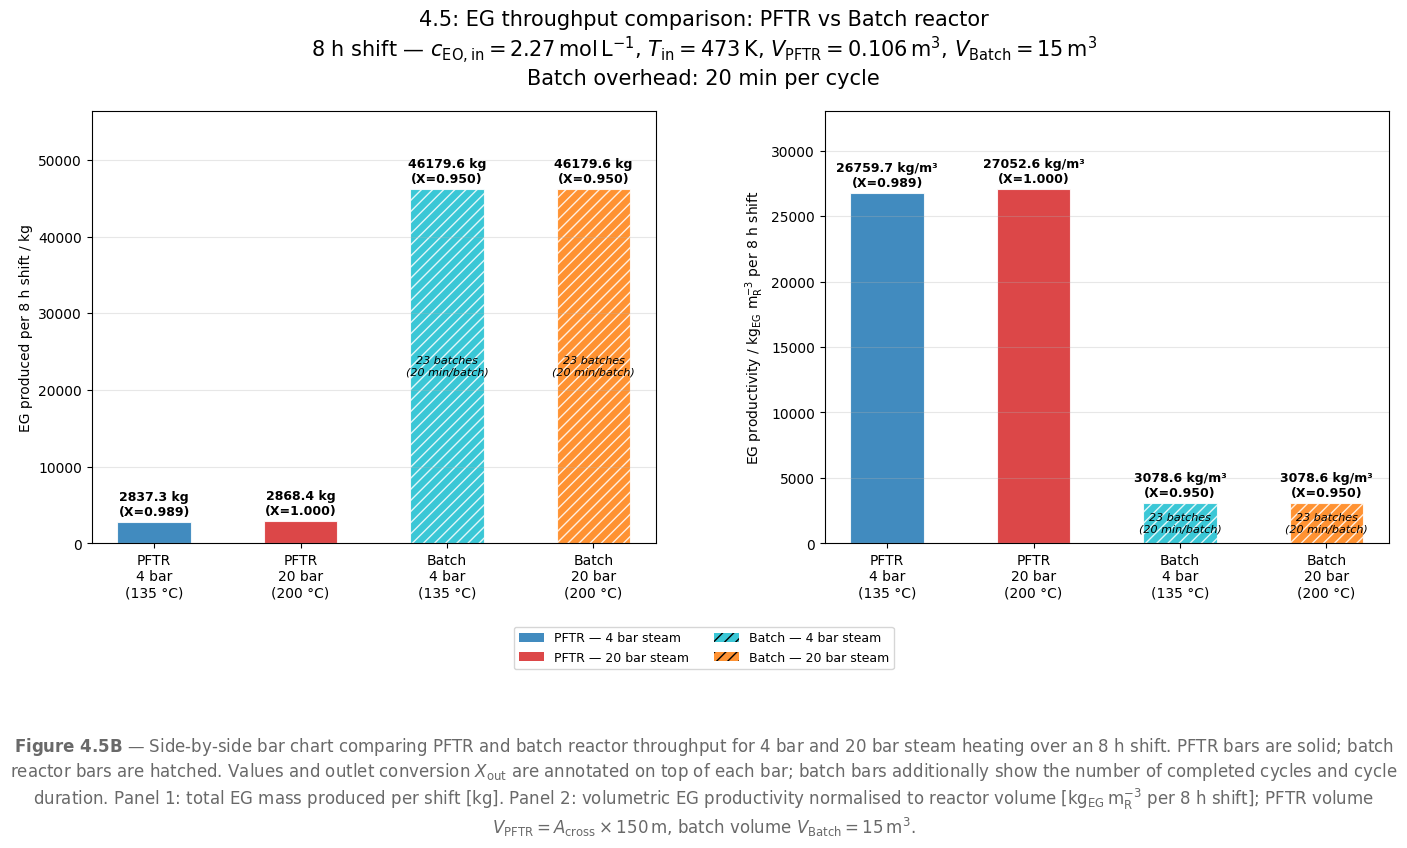

In [25]:
# ============================================================
# Section 4.5 — Bar chart: total EG per shift AND volumetric
#               productivity side by side (2 panels)
# ============================================================
from matplotlib.patches import Patch

kg_total_comp = [
    pftr_throughput[T_wall_4bar] ["n_total"] * M_EG / 1000,
    pftr_throughput[T_wall_20bar]["n_total"] * M_EG / 1000,
    batch_throughput[T_wall_4bar] ["n_total"] * M_EG / 1000,
    batch_throughput[T_wall_20bar]["n_total"] * M_EG / 1000,
]
kg_perm3_comp = [
    kg_total_comp[0] / V_pftr,
    kg_total_comp[1] / V_pftr,
    kg_total_comp[2] / V_R_batch,
    kg_total_comp[3] / V_R_batch,
]
X_out_comp = [
    pftr_throughput[T_wall_4bar] ["X_out"],
    pftr_throughput[T_wall_20bar]["X_out"],
    X_batch,
    X_batch,
]

fig_tp2, (ax_L, ax_R) = plt.subplots(1, 2, figsize=(14, 6))

for ax, values, ylabel, unit in [
    (ax_L, kg_total_comp, r"EG produced per 8 h shift / kg",                        "kg"),
    (ax_R, kg_perm3_comp, r"EG productivity / kg$_\mathrm{EG}$ m$^{-3}_\mathrm{R}$ per 8 h shift", "kg/m³"),
]:
    bars = ax.bar(labels_vol, values, color=bar_colors,
                  hatch=hatch_list, edgecolor="white",
                  linewidth=0.8, alpha=0.85, width=0.5)

    # Value label + conversion on top
    for bar, val, X in zip(bars, values, X_out_comp):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:.1f} {unit}\n(X={X:.3f})",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    # Annotate batch bars with number of batches
    for i, T_wall_val in enumerate([T_wall_4bar, T_wall_20bar]):
        n_b = batch_throughput[T_wall_val]["n_batches"]
        t_c = batch_throughput[T_wall_val]["t_cycle"]
        t_c_str = f"{t_c/60:.0f} min/batch" if t_c is not None else ""
        ax.text(2 + i, values[2 + i] / 2,
                f"{n_b} batches\n({t_c_str})",
                ha="center", va="center", fontsize=8,
                color="black", fontstyle="italic")

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, max(values) * 1.22)
    ax.grid(axis="y", alpha=0.3)

fig_tp2.legend(handles=legend_handles, loc="lower center",
               bbox_to_anchor=(0.5, -0.06), ncol=2, fontsize=9)

# --- figure description below the legend ---
fig_tp2.text(
    0.5, -0.16,
    r"$\bf{Figure\ 4.5B}$"
    " — Side-by-side bar chart comparing PFTR and batch reactor throughput "
    "for 4 bar and 20 bar steam heating over an 8 h shift. "
    "PFTR bars are solid; batch reactor bars are hatched. "
    "Values and outlet conversion $X_\\mathrm{out}$ are annotated on top of each bar; "
    "batch bars additionally show the number of completed cycles and cycle duration. "
    "Panel 1: total EG mass produced per shift [kg]. "
    "Panel 2: volumetric EG productivity normalised to reactor volume "
    "[$\\mathrm{kg_{EG}\\,m^{-3}_R}$ per 8 h shift]; "
    "PFTR volume $V_\\mathrm{PFTR} = A_\\mathrm{cross} \\times 150\\,\\mathrm{m}$, "
    "batch volume $V_\\mathrm{Batch} = 15\\,\\mathrm{m^3}$.",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig_tp2.transFigure
)

fig_tp2.suptitle(
    "4.5: EG throughput comparison: PFTR vs Batch reactor\n"
    r"8 h shift — $c_\mathrm{EO,in}=2.27\,\mathrm{mol\,L^{-1}}$, "
    r"$T_\mathrm{in}=473\,\mathrm{K}$, "
    f"$V_{{\\mathrm{{PFTR}}}}={V_pftr:.3f}\\,\\mathrm{{m^3}}$, "
    r"$V_\mathrm{Batch}=15\,\mathrm{m^3}$"
    "\n"
    r"Batch overhead: 20 min per cycle",
    fontsize=15, y =1.05)
fig_tp2.tight_layout()
fig_tp2.subplots_adjust(top=0.88, bottom=0.16, wspace=0.3)
fig_tp2.savefig("fig_4_5B_throughput_sidebyside.png", dpi=150, bbox_inches="tight")

In [26]:
# ============================================================
# Section 4.6 — PFTR throughput comparison: 4 combinations
#               of wall heating and inlet pre-heating
#               L = 150 m, c_EO,in = 2.27 mol/L
#               T_in: 4 bar pre-heat -> 135 °C (408.15 K)
#                     20 bar pre-heat -> 200 °C (473.15 K)
# ============================================================

T_in_4bar_preheat  = 408.15    # 4 bar pre-heat exchanger   [K]
T_in_20bar_preheat = 473.15    # 20 bar pre-heat exchanger  [K]

# Four cases: (T_wall, T_in, label)
cases_46 = [
    (T_wall_4bar,  T_in_4bar_preheat,  "4 bar wall\n4 bar pre-heat\n(135/135 °C)"),
    (T_wall_20bar, T_in_4bar_preheat,  "20 bar wall\n4 bar pre-heat\n(200/135 °C)"),
    (T_wall_4bar,  T_in_20bar_preheat, "4 bar wall\n20 bar pre-heat\n(135/200 °C)"),
    (T_wall_20bar, T_in_20bar_preheat, "20 bar wall\n20 bar pre-heat\n(200/200 °C)"),
]
bar_colors_46 = ["tab:blue", "tab:red", "tab:cyan", "tab:orange"]

h_W_46     = 500.0    # wall heat-transfer coefficient         [W m^-2 K^-1]
L_46       = 150.0    # reactor length                         [m]

# Solve all four PFTR cases
def solve_pftr_46(T_wall_val, T_in_val):
    """Solve PFTR for given wall and inlet temperature at L=150 m.

    Uses the central PFTR function via args=(h_W_46, T_wall_val).
    Returns outlet EO concentration and outlet conversion.
    """
    sol = integ.solve_ivp(
        PFTR, (0.0, L_46), [c_EO_in, 0.0, T_in_val],     # T_in_val in initial condition
        method="LSODA", t_eval=np.linspace(0.0, L_46, 3001),
        rtol=1e-8, atol=1e-8,
        args=(h_W_46, T_wall_val),                        # h_value=500, T_wall_val varied, u at default
    )
    c_EO, c_EG, T_prof = sol.y
    X_EO = 1.0 - c_EO / c_EO_in
    return c_EO[-1], X_EO[-1]

# Compute volumetric productivity for each case
A_cross_46 = np.pi / 4.0 * d_R**2     # tube cross-section  [m^2]
Q_46       = u * A_cross_46            # volumetric flow     [m^3 s^-1]
V_pftr_46  = A_cross_46 * L_46        # reactor volume      [m^3]

results_46 = []
for T_wall_val, T_in_val, label in cases_46:
    c_EO_out, X_out = solve_pftr_46(T_wall_val, T_in_val)
    n_dot_EG  = Q_46 * (c_EO_in - c_EO_out)           # molar EG rate     [mol s^-1]
    kg_total  = n_dot_EG * t_shift * M_EG / 1000       # kg EG per shift   [kg]
    kg_per_m3 = kg_total / V_pftr_46                   # volumetric prod.  [kg m^-3]
    results_46.append((X_out, kg_total, kg_per_m3))

    print(f"{label.replace(chr(10), ' '):<35} | X_out = {X_out:.4f} | "
          f"{kg_total:.1f} kg/shift | {kg_per_m3:.1f} kg/m³")

4 bar wall 4 bar pre-heat (135/135 °C) | X_out = 0.4093 | 1174.0 kg/shift | 11072.1 kg/m³
20 bar wall 4 bar pre-heat (200/135 °C) | X_out = 0.9991 | 2865.8 kg/shift | 27028.1 kg/m³
4 bar wall 20 bar pre-heat (135/200 °C) | X_out = 0.9894 | 2838.0 kg/shift | 26766.5 kg/m³
20 bar wall 20 bar pre-heat (200/200 °C) | X_out = 1.0000 | 2868.4 kg/shift | 27052.6 kg/m³


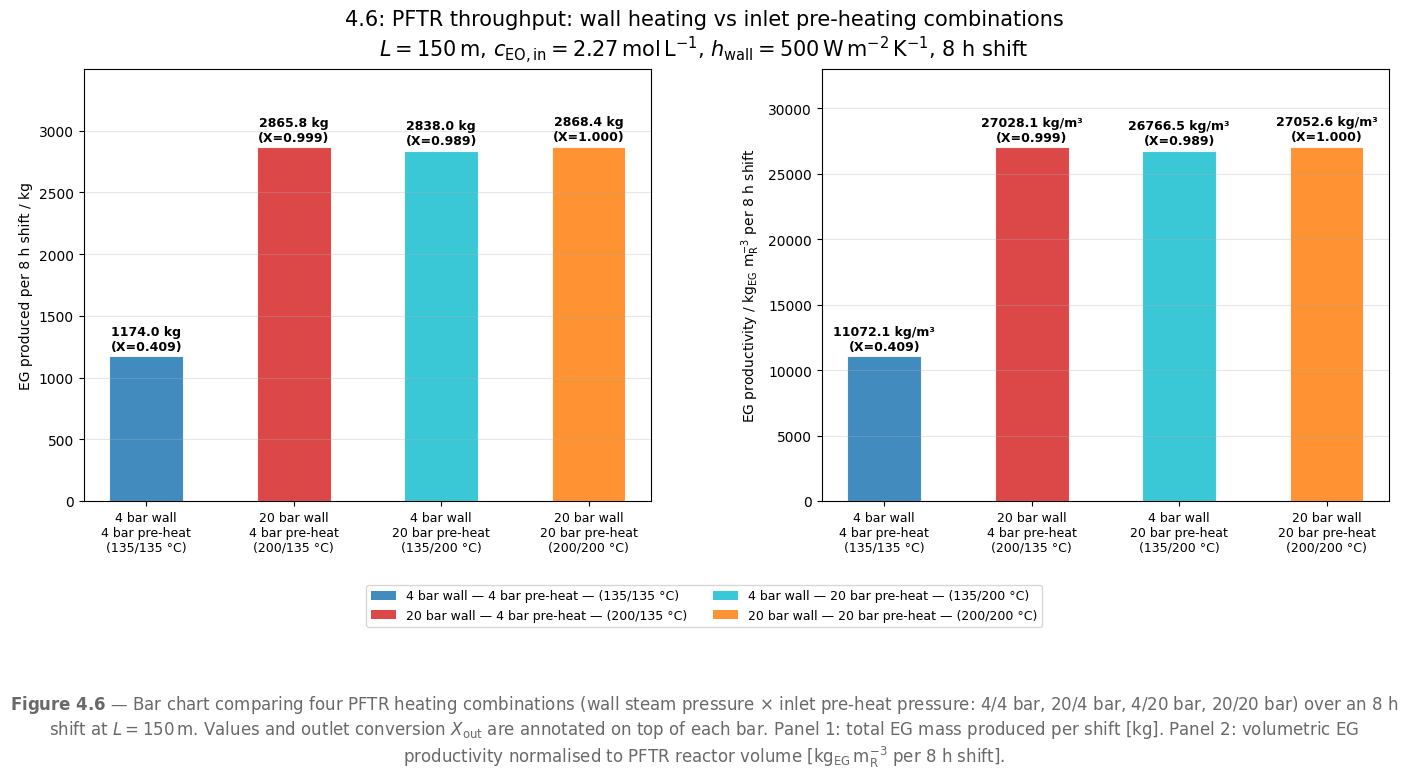

In [27]:
# ============================================================
# Section 4.6 — Bar chart: volumetric productivity (2 panels)
#   Left:  total EG per shift [kg]
#   Right: volumetric productivity [kg m^-3]
# ============================================================
from matplotlib.patches import Patch

labels_46    = [c[2] for c in cases_46]
kg_total_46  = [r[1] for r in results_46]
kg_perm3_46  = [r[2] for r in results_46]
X_out_46     = [r[0] for r in results_46]

x_pos_46 = np.arange(4)
width_46  = 0.5

fig_46, (ax_L, ax_R) = plt.subplots(1, 2, figsize=(14, 6))

for ax, values, ylabel, unit in [
    (ax_L, kg_total_46,  r"EG produced per 8 h shift / kg",                       "kg"),
    (ax_R, kg_perm3_46,  r"EG productivity / kg$_\mathrm{EG}$ m$^{-3}_\mathrm{R}$ per 8 h shift", "kg/m³"),
]:
    bars = ax.bar(x_pos_46, values, width=width_46,
                  color=bar_colors_46, alpha=0.85,
                  edgecolor="white", linewidth=0.8)

    # Value label + conversion on top of each bar
    for bar, val, X in zip(bars, values, X_out_46):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:.1f} {unit}\n(X={X:.3f})",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_xticks(x_pos_46)
    ax.set_xticklabels(labels_46, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, max(values) * 1.22)
    ax.grid(axis="y", alpha=0.3)

# Shared legend
legend_46 = [
    Patch(facecolor=c, alpha=0.85, label=cases_46[i][2].replace("\n", " — "))
    for i, c in enumerate(bar_colors_46)
]
fig_46.legend(handles=legend_46, loc="lower center",
              bbox_to_anchor=(0.5, -0.06), ncol=2, fontsize=9)

# --- figure description below the legend ---
fig_46.text(
    0.5, -0.16,
    r"$\bf{Figure\ 4.6}$"
    " — Bar chart comparing four PFTR heating combinations "
    "(wall steam pressure × inlet pre-heat pressure: "
    "4/4 bar, 20/4 bar, 4/20 bar, 20/20 bar) "
    "over an 8 h shift at $L = 150\\,\\mathrm{m}$. "
    "Values and outlet conversion $X_\\mathrm{out}$ are annotated on top of each bar. "
    "Panel 1: total EG mass produced per shift [kg]. "
    "Panel 2: volumetric EG productivity normalised to PFTR reactor volume "
    "[$\\mathrm{kg_{EG}\\,m^{-3}_R}$ per 8 h shift].",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig_46.transFigure
)

fig_46.suptitle(
    "4.6: PFTR throughput: wall heating vs inlet pre-heating combinations\n"
    r"$L=150\,\mathrm{m}$, $c_\mathrm{EO,in}=2.27\,\mathrm{mol\,L^{-1}}$, "
    r"$h_\mathrm{wall}=500\,\mathrm{W\,m^{-2}\,K^{-1}}$, 8 h shift",
    fontsize=15)
fig_46.tight_layout()
fig_46.subplots_adjust(top=0.88, bottom=0.16, wspace=0.3)
fig_46.savefig("fig_4_6_pftr_heating_comparison.png", dpi=150, bbox_inches="tight")

In [28]:
# ============================================================
# Section 4.7 — Maximum throughput optimisation
#               Find maximum fluid velocity u* such that
#               X(z = 0.9 * L) >= 0.99
#               Method: bisection search over u
# ============================================================

def solve_pftr_at_u(u_val, T_wall_val, T_in_val, L_val):
    """Solve the PFTR for a given fluid velocity u_val.

    Uses the central PFTR function via args=(h_W, T_wall_val, u_val).
    All other parameters are taken from the global parameter block.
    Returns X at z = 0.9 * L.
    """
    z_target = 0.9 * L_val                          # target position           [m]
    z_out    = np.linspace(0.0, z_target, 1001)     # output grid up to z*      [m]

    sol = integ.solve_ivp(
        PFTR, (0.0, z_target), [c_EO_in, 0.0, T_in_val],  # T_in_val in initial condition
        method="LSODA", t_eval=z_out,
        rtol=1e-8, atol=1e-8,
        args=(h_W, T_wall_val, u_val),              # h_value=h_W, T_wall_val and u_val varied
    )
    c_EO_out = sol.y[0, -1]
    return 1.0 - c_EO_out / c_EO_in                 # X at z = 0.9 * L


def find_max_velocity(T_wall_val, T_in_val, L_val,
                      X_target=0.99,
                      u_low=1e-3, u_high=10.0, tol=1e-4):
    """Bisection search for the maximum fluid velocity u* such that
    X(z = 0.9 * L) >= X_target.

    Parameters
    ----------
    T_wall_val : float   Wall temperature                    [K]
    T_in_val   : float   Inlet temperature                   [K]
    L_val      : float   Reactor length                      [m]
    X_target   : float   Required conversion at 0.9 * L      [-]
    u_low      : float   Lower bound for bisection           [m s^-1]
    u_high     : float   Upper bound for bisection           [m s^-1]
    tol        : float   Velocity tolerance for convergence  [m s^-1]

    Returns
    -------
    u_star     : float   Maximum admissible fluid velocity   [m s^-1]
    X_star     : float   Conversion at u* and z = 0.9 * L   [-]
    m_dot_star : float   Maximum mass flow rate              [kg s^-1]
    V_dot_star : float   Maximum volumetric flow rate        [m^3 s^-1]
    """
    # Verify that X_target is achievable at all within the search range
    X_at_low = solve_pftr_at_u(u_low, T_wall_val, T_in_val, L_val)
    if X_at_low < X_target:
        return None, X_at_low, None, None   # not achievable even at minimum u

    # Bisection loop
    while (u_high - u_low) > tol:
        u_mid = 0.5 * (u_low + u_high)
        X_mid = solve_pftr_at_u(u_mid, T_wall_val, T_in_val, L_val)
        if X_mid >= X_target:
            u_low = u_mid        # feasible: try higher u
        else:
            u_high = u_mid       # infeasible: reduce u

    u_star     = u_low
    X_star     = solve_pftr_at_u(u_star, T_wall_val, T_in_val, L_val)
    A_cross    = np.pi / 4.0 * d_R**2               # tube cross-section        [m^2]
    V_dot_star = u_star * A_cross                    # volumetric flow rate      [m^3 s^-1]
    m_dot_star = V_dot_star * rho                    # mass flow rate            [kg s^-1]

    return u_star, X_star, m_dot_star, V_dot_star


# --- Four heating combinations x two reactor lengths ---
L_options  = [150.0, 300.0]                          # reactor lengths           [m]

# (T_wall, T_in, label)
cases_47 = [
    (T_wall_4bar,  T_in_4bar_preheat,  "4 bar wall\n4 bar pre-heat\n(135/135 °C)"),
    (T_wall_4bar,  T_in_20bar_preheat, "4 bar wall\n20 bar pre-heat\n(135/200 °C)"),
    (T_wall_20bar, T_in_4bar_preheat,  "20 bar wall\n4 bar pre-heat\n(200/135 °C)"),
    (T_wall_20bar, T_in_20bar_preheat, "20 bar wall\n20 bar pre-heat\n(200/200 °C)"),
]

# Solve and store results
results_47 = {}
print(f"{'Case':<35} | {'L / m':>6} | {'u* / m/s':>9} | "
      f"{'X at 0.9L':>10} | {'V_dot / L/s':>11} | {'m_dot / kg/s':>12}")
print("-" * 95)

for T_wall_val, T_in_val, label in cases_47:
    results_47[label] = {}
    for L_val in L_options:
        u_star, X_star, m_dot, V_dot = find_max_velocity(T_wall_val, T_in_val, L_val)

        results_47[label][L_val] = {
            "u_star" : u_star,
            "X_star" : X_star,
            "m_dot"  : m_dot,
            "V_dot"  : V_dot,
        }

        label_short = label.replace("\n", " ")
        if u_star is not None:
            print(f"  {label_short:<33} | {L_val:>6.0f} | {u_star:>9.4f} | "
                  f"{X_star:>10.4f} | {V_dot*1000:>11.4f} | {m_dot:>12.4f}")
        else:
            print(f"  {label_short:<33} | {L_val:>6.0f} | {'n/a':>9} | "
                  f"{X_star:>10.4f} | {'n/a':>11} | {'n/a':>12}")

Case                                |  L / m |  u* / m/s |  X at 0.9L | V_dot / L/s | m_dot / kg/s
-----------------------------------------------------------------------------------------------
  4 bar wall 4 bar pre-heat (135/135 °C) |    150 |    0.0862 |     0.9900 |      0.0609 |       0.0609
  4 bar wall 4 bar pre-heat (135/135 °C) |    300 |    0.1725 |     0.9900 |      0.1219 |       0.1219
  4 bar wall 20 bar pre-heat (135/200 °C) |    150 |    0.8321 |     0.9900 |      0.5882 |       0.5882
  4 bar wall 20 bar pre-heat (135/200 °C) |    300 |    1.6642 |     0.9900 |      1.1763 |       1.1763
  20 bar wall 4 bar pre-heat (200/135 °C) |    150 |    1.1921 |     0.9900 |      0.8426 |       0.8426
  20 bar wall 4 bar pre-heat (200/135 °C) |    300 |    2.3842 |     0.9900 |      1.6853 |       1.6853
  20 bar wall 20 bar pre-heat (200/200 °C) |    150 |    4.4432 |     0.9900 |      3.1407 |       3.1407
  20 bar wall 20 bar pre-heat (200/200 °C) |    300 |    8.8863 |     0

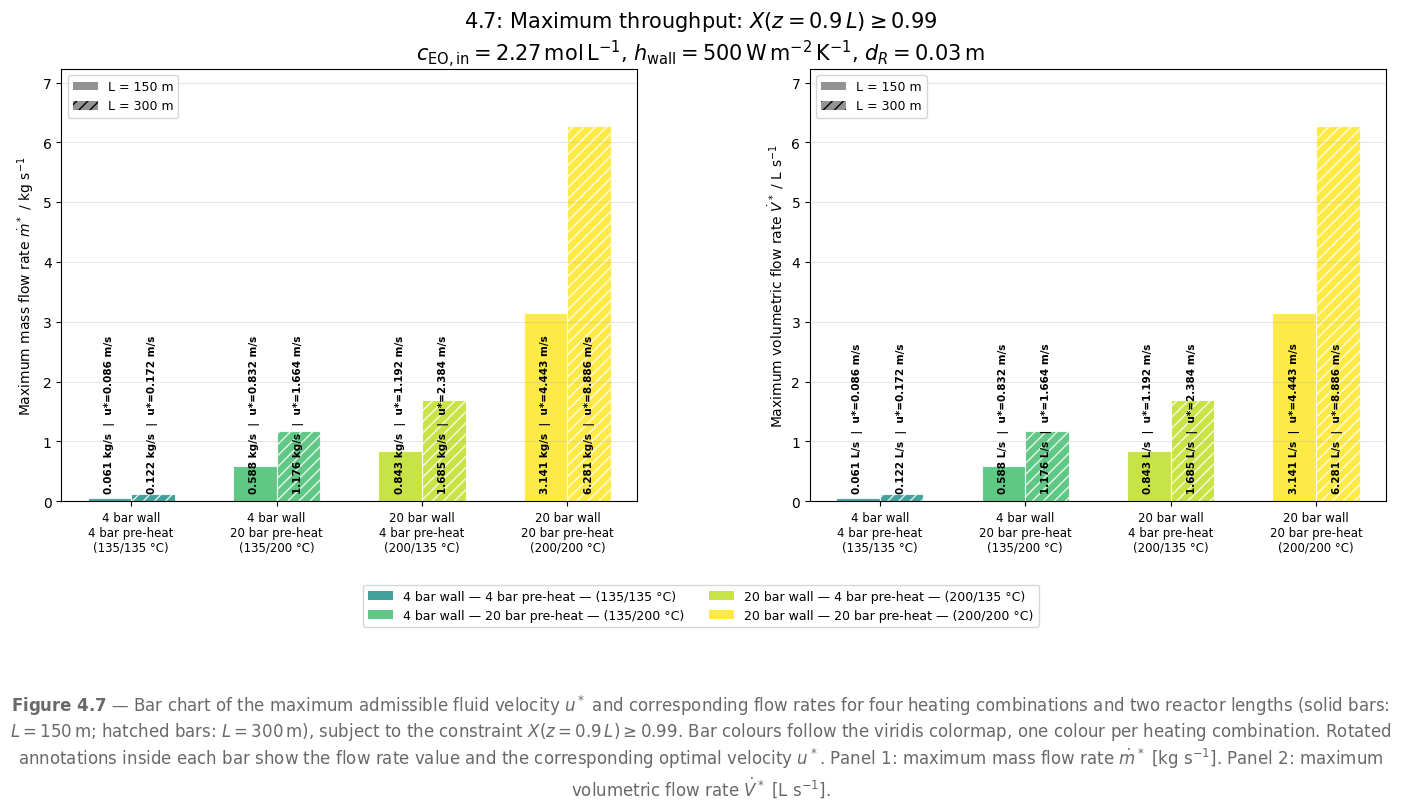

In [29]:
# ============================================================
# Section 4.7 — Bar chart: maximum mass flow rate (revised)
#               Original label style, 4 colors for 4 cases,
#               hatching to distinguish 150 m / 300 m
# ============================================================

n_cases_47 = len(cases_47)
x_pos_47   = np.arange(n_cases_47)
width_47   = 0.3

# Four distinct viridis colors, one per heating combination
case_colors_47 = [plt.cm.viridis(0.5 + i * 0.2) for i in range(n_cases_47)]
hatch_L_47     = {150.0: "",     300.0: "///"}   # solid = 150 m, hatched = 300 m

fig_47, (ax_L, ax_R) = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel, unit, scale in [
    (ax_L, "m_dot", r"Maximum mass flow rate $\dot{m}^*$ / kg s$^{-1}$",      "kg/s", 1.0),
    (ax_R, "V_dot", r"Maximum volumetric flow rate $\dot{V}^*$ / L s$^{-1}$", "L/s",  1000.0),
]:
    all_vals = [
        results_47[label][L_val][metric] * scale
        for _, _, label in cases_47
        for L_val in L_options
        if results_47[label][L_val][metric] is not None
    ]
    y_max = max(all_vals)

    for j, L_val in enumerate(L_options):
        offset = (j - 0.5) * width_47
        vals, u_vals = [], []

        for T_wall_val, T_in_val, label in cases_47:
            r = results_47[label][L_val]
            vals.append( r[metric] * scale if r[metric] is not None else 0.0)
            u_vals.append(r["u_star"]       if r["u_star"] is not None else 0.0)

        for i, (bar_val, u, col) in enumerate(zip(vals, u_vals, case_colors_47)):
            bar = ax.bar(x_pos_47[i] + offset, bar_val,
                         width=width_47,
                         color=col, alpha=0.85,
                         hatch=hatch_L_47[L_val],
                         edgecolor="white", linewidth=0.8)

            # Value + u* rotated 90°, anchored at x-axis, black text
            ax.text(x_pos_47[i] + offset,
                y_max * 0.02,
                f"{bar_val:.3f} {unit}  |  u*={u:.3f} m/s",
                ha="center", va="bottom",
                fontsize=7.5, fontweight="bold",
                color="black", rotation=90)

    ax.set_xticks(x_pos_47)
    ax.set_xticklabels([c[2] for c in cases_47], fontsize=8.5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, y_max * 1.15)
    ax.grid(axis="y", alpha=0.3)

    # Legend: L distinction via hatch
    ax.legend(handles=[
        Patch(facecolor="gray", alpha=0.85,              label="L = 150 m"),
        Patch(facecolor="gray", alpha=0.85, hatch="///", label="L = 300 m"),
    ], fontsize=9, loc="upper left")

# Shared color legend for the 4 heating cases
case_handles_47 = [
    Patch(facecolor=col, alpha=0.85, label=label.replace("\n", " — "))
    for col, (_, _, label) in zip(case_colors_47, cases_47)
]
fig_47.legend(handles=case_handles_47, loc="lower center",
              bbox_to_anchor=(0.5, -0.06), ncol=2, fontsize=9)

# --- figure description below the legend ---
fig_47.text(
    0.5, -0.16,
    r"$\bf{Figure\ 4.7}$"
    " — Bar chart of the maximum admissible fluid velocity $u^*$ and corresponding "
    "flow rates for four heating combinations and two reactor lengths "
    "(solid bars: $L = 150\\,\\mathrm{m}$; hatched bars: $L = 300\\,\\mathrm{m}$), "
    "subject to the constraint $X(z = 0.9\\,L) \\geq 0.99$. "
    "Bar colours follow the viridis colormap, one colour per heating combination. "
    "Rotated annotations inside each bar show the flow rate value and the "
    "corresponding optimal velocity $u^*$. "
    "Panel 1: maximum mass flow rate $\\dot{m}^*$ [kg s$^{-1}$]. "
    "Panel 2: maximum volumetric flow rate $\\dot{V}^*$ [L s$^{-1}$].",
    ha="center", va="top", fontsize=12, color="dimgray",
    wrap=True, transform=fig_47.transFigure
)

fig_47.suptitle(
    r"4.7: Maximum throughput: $X(z=0.9\,L) \geq 0.99$"
    "\n"
    r"$c_\mathrm{EO,in}=2.27\,\mathrm{mol\,L^{-1}}$, "
    r"$h_\mathrm{wall}=500\,\mathrm{W\,m^{-2}\,K^{-1}}$, "
    r"$d_R=0.03\,\mathrm{m}$",
    fontsize=15)
fig_47.tight_layout()
fig_47.subplots_adjust(top=0.88, bottom=0.16, wspace=0.3)
fig_47.savefig("fig_4_7_max_throughput.png", dpi=150, bbox_inches="tight")

In [35]:
# ============================================================
# Section 4.8 — Industrial scale-up
#               Target: 0.5 Mt EG/a at 8000 operating hours/a
#               Comparison: Option A (single large pipe, varying d)
#                           Option B (tube bundle, d = 0.03 m)
#               Two heating cases: 4 bar / 20 bar wall
#               L = 150 m, 20 bar pre-heat (T_in = 473.15 K)
# ============================================================

# --- Target production rate ---
m_EG_annual  = 0.5e9                              # target EG production     [kg/a]
t_operating  = 8000.0 * 3600.0                    # operating time per year  [s/a]
m_dot_target = m_EG_annual / t_operating          # required EG mass flow    [kg/s]

# --- Scale-up parameters ---
L_49        = 150.0                               # reactor length            [m]
T_in_49     = T_in_20bar_preheat                  # 20 bar pre-heat           [K]
d_values_49 = [0.03, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0]   # pipe diameters       [m]
X_target_49 = 0.99                                # conversion target         [-]
L_target_49 = 0.9 * L_49                         # must reach X at 90% of L  [m]

def find_max_velocity_d(T_wall_val, T_in_val, L_val, d_val,
                        X_target=0.99, u_low=1e-3, u_high=10.0, tol=1e-4):
    """Bisection search for maximum u* for a given pipe diameter d_val.

    Identical to find_max_velocity but with d_val as explicit parameter,
    allowing diameter variation without changing the global d_R.
    """
    def solve_at_u(u_val):
        z_target = 0.9 * L_val
        z_out    = np.linspace(0.0, z_target, 1001)

        def rhs(z, f):
            c_EO, c_EG, T = f
            r     = kinetics(T, c_EO)
            dc_EO = -r / u_val
            dc_EG = +r / u_val
            dT    = (-r * dH_R - h_W * (4.0 / d_val) * (T - T_wall_val)) / (rho * c_p * u_val)
            return [dc_EO, dc_EG, dT]

        sol = integ.solve_ivp(
            rhs, (0.0, z_target), [c_EO_in, 0.0, T_in_val],
            method="LSODA", t_eval=z_out, rtol=1e-8, atol=1e-8
        )
        return 1.0 - sol.y[0, -1] / c_EO_in

    # Check feasibility at minimum velocity
    if solve_at_u(u_low) < X_target:
        return None, solve_at_u(u_low), None, None

    # Bisection
    while (u_high - u_low) > tol:
        u_mid = 0.5 * (u_low + u_high)
        if solve_at_u(u_mid) >= X_target:
            u_low = u_mid
        else:
            u_high = u_mid

    u_star     = u_low
    X_star     = solve_at_u(u_star)
    A_cross    = np.pi / 4.0 * d_val**2
    V_dot_star = u_star * A_cross                 # per single pipe           [m^3/s]
    m_dot_star = V_dot_star * rho                 # per single pipe           [kg/s]

    return u_star, X_star, m_dot_star, V_dot_star


# --- Compute EG mass flow per pipe for each diameter and heating case ---
def m_dot_EG_pipe(m_dot_total, d_val, u_star, X_star):
    """EG mass flow rate produced by a single pipe."""
    A_cross   = np.pi / 4.0 * d_val**2
    V_dot     = u_star * A_cross
    n_dot_EG  = V_dot * c_EO_in * X_star          # mol/s
    return n_dot_EG * M_EG / 1000                 # kg/s


results_49 = {}

print(f"Target EG production : {m_EG_annual/1e6:.1f} Mt/a")
print(f"Operating time       : {t_operating/3600:.0f} h/a")
print(f"Required EG mass flow: {m_dot_target:.3f} kg/s  ({m_dot_target*3600:.1f} kg/h)")
print()

for T_wall_val, wall_label in heating_cases:
    results_49[T_wall_val] = []

    print(f"  === {wall_label} ===")
    print(f"  {'d / m':>6} | {'u* / m/s':>9} | {'m_dot EG (1 pipe) / kg/s':>24} | "
          f"{'N pipes':>8} | {'Annual capacity / Mt/a':>22} | {'Note':>22}")
    print("  " + "-" * 100)

    for d_val in d_values_49:
        u_star, X_star, m_dot_pipe, V_dot_pipe = find_max_velocity_d(
            T_wall_val, T_in_49, L_49, d_val)

        if u_star is None:
            n_pipes  = None
            m_dot_EG = None
            note     = "X target not reached"
            n_str, m_str, u_str, annual_str = "n/a", "n/a", "n/a", "n/a"
        else:
            m_dot_EG = m_dot_EG_pipe(m_dot_target, d_val, u_star, X_star)
            u_str    = f"{u_star:.4f}"
            m_str    = f"{m_dot_EG:.5f}"

            if m_dot_EG >= m_dot_target:
                n_pipes    = 1
                note       = "1 pipe sufficient"
                n_str      = "1"
                annual     = m_dot_EG * t_operating / 1e9      # [Mt/a]      # [Mt/a]
                annual_str = f"{annual:.4f}"
            else:
                n_pipes    = int(np.ceil(m_dot_target / m_dot_EG))
                note       = f"{n_pipes} pipes needed"
                n_str      = str(n_pipes)
                annual     = n_pipes * m_dot_EG * t_operating / 1e9   # [Mt/a]
                annual_str = f"{annual:.4f}"

        results_49[T_wall_val].append({
            "d"        : d_val,
            "u_star"   : u_star,
            "X_star"   : X_star,
            "m_dot_EG" : m_dot_EG,
            "n_pipes"  : n_pipes,
            "note"     : note,
        })

        print(f"  {d_val:>6.2f} | {u_str:>9} | {m_str:>24} | "
              f"{n_str:>8} | {annual_str:>22} | {note:>22}")
    print()

Target EG production : 500.0 Mt/a
Operating time       : 8000 h/a
Required EG mass flow: 17.361 kg/s  (62500.0 kg/h)

  === 4 bar steam ($T_\mathrm{wall}=408\,\mathrm{K}$, 135 °C) ===
   d / m |  u* / m/s | m_dot EG (1 pipe) / kg/s |  N pipes | Annual capacity / Mt/a |                   Note
  ----------------------------------------------------------------------------------------------------
    0.03 |    0.8321 |                  0.08204 |      212 |                 0.5009 |       212 pipes needed
    0.10 |    4.2778 |                  4.68659 |        4 |                 0.5399 |         4 pipes needed
    0.20 |    4.7872 |                 20.97852 |        1 |                 0.6042 |      1 pipe sufficient
    0.30 |    4.9500 |                 48.80683 |        1 |                 1.4056 |      1 pipe sufficient
    0.40 |    5.0303 |                 88.17571 |        1 |                 2.5395 |      1 pipe sufficient
    0.50 |    5.0781 |                139.08262 |        1 

In [33]:
# ============================================================
# Section 4.9 — Material cost estimation for pipe bundle
#               Pipe material: stainless steel 316L
#               Wall thickness: PN10 (10 bar) per DIN EN 13480
#               t = (p * d_i) / (2 * sigma_allow - p)
#               sigma_allow (316L, ~150°C) = 115 MPa
#               Source: AD 2000 Merkblatt B1, 316L at 150°C
#               Steel density: 7900 kg/m^3
#               Material price: 4.50 EUR/kg (316L seamless tube,
#               market estimate 2024, e.g. Metalldatenbank.de)
# ============================================================

p_design     = 10.0e5        # design pressure PN10              [Pa]
sigma_allow  = 115.0e6       # allowable stress 316L at 150°C    [Pa]
rho_steel    = 7900.0        # density stainless steel 316L      [kg m^-3]
price_per_kg = 4.50          # material price 316L seamless      [EUR/kg]

def wall_thickness_PN10(d_inner):
    """Calculate minimum wall thickness for PN10 per DIN EN 13480.

    t = (p * d_i) / (2 * sigma_allow - p)

    A corrosion allowance of 1 mm is added as per standard practice
    for aqueous service.

    Parameters
    ----------
    d_inner : float   Inner pipe diameter    [m]

    Returns
    -------
    t : float   Wall thickness (with corrosion allowance)  [m]
    """
    t_calc = (p_design * d_inner) / (2.0 * sigma_allow - p_design)
    t_corr = t_calc + 0.001          # +1 mm corrosion allowance  [m]
    return t_corr


def pipe_mass(d_inner, t_wall, L_val, n_pipes):
    """Total mass of pipe bundle.

    m = rho_steel * pi * ((d_o/2)^2 - (d_i/2)^2) * L * N

    Parameters
    ----------
    d_inner : float   Inner diameter          [m]
    t_wall  : float   Wall thickness          [m]
    L_val   : float   Pipe length             [m]
    n_pipes : int     Number of pipes         [-]

    Returns
    -------
    m : float   Total pipe mass               [kg]
    """
    d_outer = d_inner + 2.0 * t_wall
    A_steel = np.pi / 4.0 * (d_outer**2 - d_inner**2)   # cross-sectional area [m^2]
    return rho_steel * A_steel * L_val * n_pipes


# --- Compute costs for all cases ---
print(f"Material cost estimation — PN10, 316L stainless steel")
print(f"sigma_allow = {sigma_allow/1e6:.0f} MPa, "
      f"price = {price_per_kg:.2f} EUR/kg, "
      f"L = {L_49:.0f} m\n")

for T_wall_val, wall_label in heating_cases:
    print(f"  === {wall_label} ===")
    print(f"  {'d_i / m':>8} | {'t_wall / mm':>11} | {'d_o / m':>8} | "
          f"{'N pipes':>8} | {'Mass / t':>9} | {'Cost / TEUR':>12}")
    print("  " + "-" * 75)

    for r in results_49[T_wall_val]:
        if r["n_pipes"] is None:
            print(f"  {r['d']:>8.2f} | {'n/a':>11} | {'n/a':>8} | "
                  f"{'n/a':>8} | {'n/a':>9} | {'n/a':>12}")
            continue

        d_i    = r["d"]
        t_w    = wall_thickness_PN10(d_i)
        d_o    = d_i + 2.0 * t_w
        n_p    = r["n_pipes"]
        m_pipe = pipe_mass(d_i, t_w, L_49, n_p)
        cost   = m_pipe * price_per_kg / 1e3             # [TEUR]

        print(f"  {d_i:>8.2f} | {t_w*1000:>11.2f} | {d_o:>8.4f} | "
              f"{n_p:>8} | {m_pipe/1000:>9.1f} | {cost:>12.3f}")
    print()

Material cost estimation — PN10, 316L stainless steel
sigma_allow = 115 MPa, price = 4.50 EUR/kg, L = 150 m

  === 4 bar steam ($T_\mathrm{wall}=408\,\mathrm{K}$, 135 °C) ===
   d_i / m | t_wall / mm |  d_o / m |  N pipes |  Mass / t |  Cost / TEUR
  ---------------------------------------------------------------------------
      0.03 |        1.13 |   0.0323 |      212 |      27.8 |      125.047
      0.10 |        1.44 |   0.1029 |        4 |       2.2 |        9.766
      0.20 |        1.87 |   0.2037 |        1 |       1.4 |        6.336
      0.30 |        2.31 |   0.3046 |        1 |       2.6 |       11.699
      0.40 |        2.75 |   0.4055 |        1 |       4.1 |       18.532
      0.50 |        3.18 |   0.5064 |        1 |       6.0 |       26.835
      1.00 |        5.37 |   1.0107 |        1 |      20.1 |       90.390

  === 20 bar steam ($T_\mathrm{wall}=473\,\mathrm{K}$, 200 °C) ===
   d_i / m | t_wall / mm |  d_o / m |  N pipes |  Mass / t |  Cost / TEUR
  -----------

# 5. Conclusions

For this assignment we set out to investigate the behaviour of a PFTR when its operating conditions are varied. The goal is to, in the end, give a reasonable set of parameters under which to operate a PFTR with the given dimensions for an optimized throughput and efficient energy usage. 

From the theoretical and mathematical background we concluded, that the temperature of the mixture is gouverning the reaction rate (eq.5), and therefor the conversion of EO to EG. As seen in equation 12, the temperature of the mixture can be changed in two ways: by the heat of reaction released with conversion of EO to EG or by heat transfer between the fluid and the inner tube wall. The heat of reaction is a fixed value and cannot be varied, the rate of reaction can not be varied directly, but only by varying the process parameters. This is why we focused on varying the parameters of the fluid-wall heat transfer to investigate the behaviour of the reaction under different temperature profiles. 

### **4.1 Heat transfer coefficient**

As a first variation we chose to simulate different levels of heat transport between the fluid and the inner tube wall. The possible parameters that have an influence on this are the temperature of the ingoing fluid, the temperature of the wall or the heat transfer coefficient between fluid and wall. We started by varying the heat transfer coefficient, and leaving the inlet and wall temperature at base case values. This approach was chosen, because by varying the heat transfer coefficient we can easily simulate the two edgecases of either **isothermal** or **adiabatic** behaviour. This will lead to temperatur profiles of the maximal reached temperature in the case of adiabatic behaviour and the lowest possible temperature under isothermal conditions. 

<div align="center"><img src="fig_3_1_hwall_variation.png" width="1300"></div>

Figure 4.1 shows from left to right three plots in Panels 1, 2 and 3. Panel 1 shows the temperature of the reaction mixture at a given point along the z-axis of the reactor. We can observe that lower heat transfer coefficients lead to higher maximum temperatures of the reaction mixture. This is expected, as the heat of reaction released by the formation of EG ($\Delta_R H = -92.2\,\mathrm{kJ\,mol^{-1}}$) cannot be transfered to the wall as fast, leading to the reaction mixture taking up more heat and showing a higher rise in Temperature. Equation 18 is a rewritten form of equation 12 showing the explanation in mathematical terms. The left side has the same value for all cases, at least in the first centimeters inside the reactor. Afterwards, the difference in heat distribution to the wall or the fluid mixture is changing the temperature differently in each case, leading to different reaction rates on the left side. 

\begin{equation}
    - k_{0} \exp \left(-\frac{E_{A}}{R\, T} \right) c_{\mathrm{EO}} \, \Delta_R H = \rho \, c_p \, u \frac{dT}{dz} + h_{\mathrm{wall}} \frac{4}{d_R} \left( T - T_{\mathrm{wall}} \right)
    \tag{18}
\end{equation}

The correlation between the higher temperature and the higher reaction rate can be seen in panel 2. Here we have plotted the conversion of EO over the length of the reactor. We observe the cases with lower heat transfer coefficients and therefor higher temperatures showing a steeper rise of conversion, meaning the reaction is progressing faster. This is because of the effect of T on the reaction rate konstant k. (Eq. 5) 

Panel 3 shows that no case other than the adiabatic case reaches 100% conversion over the whole reactor length. This is due to the cooling effect of the wall temperature, which sets in once the fluid temperature exceeds $T_\mathrm{wall}$. By reducing the fluid temperature towards the wall temperature, the reaction rate slows down. As the concentration of EO is also reduced with progressing conversion, the effective reaction rate drops so low that full conversion cannot be reached within the given reactor length. We can observe a clear correlation between a rise in heat transfer coefficient and a subsequent decline in total conversion. The dotted lines show the final conversion of the isothermal case ($h_\mathrm{wall} \to \infty$), representing the lower boundary of possible conversions in this configuration.

The two edge cases show the worst possible conversion (isothermal) and best possible conversion (adiabatic) for this base case configuration. As inlet temperature and wall temperature are the same, the isothermal case never changes in temperature, leading to a constant k(T). We can also see this in panel 1, as the isothermal case aligns perfectly with the wall temperature along the whole reactor length. The adiabatic case shows the maximum possible temperature that can be reached by the reaction and also the steepest increase of temperature for an unheated process. This is because the total amount of heat released by the reaction is consumed by the fluid mixture and used to heat it up. For complete conversion, the total adiabatic temperature rise is given by equation 19.

\begin{equation}
    \Delta T_{\mathrm{ad}} = \frac{-\Delta_R H \cdot c_{\mathrm{EO,0}}}{\rho \, c_p} = 50,07
    \tag{19}
\end{equation}

The resulting rise in temperature is also the exact rise in temperature that can be observed for the adiabatic case in panel 1. 

For cases with a wall temperature equal to or lower than the inlet stream temperature, a lower heat transfer coefficient is beneficial: less heat is removed from the fluid, the temperature rises more steeply, and the reaction accelerates. The limiting case is adiabatic operation, in which all heat of reaction is retained in the fluid. If the wall temperature exceeds the inlet temperature, the relationship inverts during the initial reactor section: the wall now supplies heat to the fluid, and a lower heat transfer coefficient slows this heat input, keeping the fluid temperature — and therefore the reaction rate — lower. Once the fluid temperature surpasses the wall temperature, heat transfer becomes a loss mechanism, and the same argument as above applies again. For the strongly exothermic EO hydrolysis, the heat released by the reaction itself dominates the temperature profile under most practical conditions. We therefore conclude that, for almost all case configurations, adiabatic or near-adiabatic operation maximises conversion within a given reactor length.

---

### With which $h_\mathrm{wall}$ to proceed

As a realistic value, $h_\mathrm{wall}$ cannot be set to 0. In our model, the heat transfer coefficient accounts only for heat transport between the fluid and the inner tube wall. This means that heat losses through the outer wall of the reactor are not considered; the reactor is therefore assumed to be perfectly insulated to the outside, or at least well enough for external heat losses to be negligibly small.

We also assume the reactor wall temperature to be constant along the entire reactor length. In reality, this requires active temperature control from the outside — for example, by means of a heating jacket or a corrugated hose installed between the insulation and the reactor tube, through which a temperature-controlled medium is circulated. By using a fluid at its boiling or condensation point (e.g. pressurised steam), the wall temperature can be held approximately constant. This is common practice in industrial tubular reactor design and is the physical basis for the wall temperature $T_\mathrm{wall}$ as a model parameter.

For all further parameter variations, we therefore assume the reactor to be perfectly insulated to the outside, with the wall temperature held constant by an external heating jacket. As for the heat transfer coefficient from the fluid to the inner tube wall, we continue with the base case value of $500\,\mathrm{W\,m^{-2}\,K^{-1}}$, which is a reasonable approximation for turbulent flow conditions. A more precise value could be obtained from Nusselt correlations; however, as this is outside the scope of this assignment, we proceed with the base case approximation.

### **4.2 Variation of wall temperature**

From our first parameter estimation we have confirmed that higher temperatures inside the fluid lead to higher conversions. As discussed above, the heat transfer coefficient between fluid and wall has a major impact on the fluid temperature rise from heat released by the reaction. But as we cannot realistically set this value other than adjusting the flow speed to reduce the Reynolds number in Nusselt correlations, and this would be detrimental to the overall throughput and not desirable, we have assumed $h_\mathrm{wall}$ to be the base case of $500\,\mathrm{W\,m^{-2}\,K^{-1}}$.

This leaves us with two major parameters to adjust the temperature evolution inside the fluid. These are the wall temperature and the inlet temperature of the fluid. Seeing as the inlet temperature only applies to the beginning of the reaction, and the wall temperature is present over the whole reactor length, we decided to first vary the wall temperature. The chosen values for $T_\mathrm{wall}$ were chosen to represent certain heating mediums. In the chemical industry, steam is the most commonly available heating medium. It is supplied at different pressures to enable heating at different condensation temperatures. As the heat of condensation for steam ($2257\,\mathrm{kJ\,kg^{-1}}$) is far larger than the heat capacity of liquid water ($4.19\,\mathrm{kJ\,kg^{-1}\,K^{-1}}$) or steam ($1.9\,\mathrm{kJ\,kg^{-1}\,K^{-1}}$), the condensation temperature of the steam is the temperature that will be reached by the reactor wall. By supplying a mixture of vapour and liquid to the heating jacket or corrugated hose, the heating medium can absorb heat by evaporating condensate or release heat by condensing, all while maintaining a constant temperature.

The chosen values for the wall temperature are:
- 100°C (1 bar steam),
- 135°C (4 bar steam, accounting for the temperature drop across the wall–jacket interface),
- 150°C (base case),
- 180°C (10 bar steam, accounting for the temperature drop across the wall–jacket interface),
- 200°C (20 bar steam, accounting for the temperature drop across the wall–jacket interface) and
- 240°C (40 bar steam, accounting for the temperature drop across the wall–jacket interface).

These values are realistically reachable temperatures in already existing chemical plants. Heating mediums with even higher temperatures would most likely be much more expensive, leading to these choices being the most viable from an economical standpoint.

<div align="center"><img src="fig_4_2_Twall_variation.png" width="1300"></div>

Figure 4.2A shows the variation of the wall temperature over the before chosen values. The inlet temperature is held at the base case value of $T_\mathrm{in} = 423\,\mathrm{K}$, the heat transfer coefficient to the wall is $500\,\mathrm{W\,m^{-2}\,K^{-1}}$. Panel 1 shows that higher wall temperatures than the inlet temperature lead to a steep incline in the beginning of the reactor, while lower wall temperatures cause the fluid temperature to rise less sharply or even decline from the beginning. This is expected, as the cooling behaviour for lower wall temperatures can be explained with equation 18. The sharp rise in temperature for cases with a higher wall temperature is explained by the fact that in these cases, both the heat released by the reaction _and_ the heat input from the wall contribute to a temperature increase in the beginning. When the fluid temperature surpasses the wall temperature, we can observe the temperature rise slowing down and eventually decreasing as the cooling effect of the wall temperature dominates over the heat released by the reaction. This is not the case for a wall temperature of 240°C, which can be explained by the fact that the wall temperature is much higher than the maximum temperature reachable by the reaction heat alone (${\approx}473\,\mathrm{K}$, i.e. $T_\mathrm{in} + \Delta T_\mathrm{ad}$, see adiabatic case in Section 4.1). Because the temperature rises so fast, the reaction rate is also increased sharply. This leads to total conversion before the fluid temperature reaches the wall temperature, resulting in the observed behaviour of a sharp rise until complete conversion of EO (point of total conversion seen in panel 2) and a subsequent slow approximation of the wall temperature, as heat transfer from wall to fluid is the only remaining factor after 100% conversion.

In panel 2 we see the conversion of EO over the length of the reactor. We observe high conversions for wall temperatures of 180, 200 and 240°C, with higher temperatures reaching total conversion faster. From panel 3 we can see that total conversion of EO is only reached for these three cases, with the other cases showing conversions lower than that. It is shown that wall temperatures which slow the reaction by cooling the fluid have a strongly detrimental effect on the conversion of EO. For a wall temperature of 100°C the reaction reaches less than 30% conversion after 300 metres, making this configuration highly inefficient in comparison.

With three of the cases reaching 100% conversion, we also investigated after which reactor length total conversion was reached. Additionally we plotted the length after which 90% conversion was reached, with possible use cases for lower purity in mind.

<div align="center"><img src="fig_4_2_Twall_variation_wall_length.png" width="1300"></div>

Figure 4.2B shows the length at which the different cases reached 90% or 99.9% conversion. We can observe that the cases of 100 and 135°C never reach either of these conversions inside the reactor. A wall temperature of 150°C leads to 90% conversion at about 250 metres, but never reaches 99.9% conversion. The three remaining cases all reach either conversion rate, with 200°C showing a significant improvement over 180°C, reaching 99.9% conversion in almost half the reactor length. The increase of heating medium from 20 bar steam (200°C) to 40 bar steam (240°C) leads to an additional improvement of one third of reactor length for 99.9% conversion. As this is not a large improvement in total length, but requires a significant increase in heating cost, we determine 20 bar steam to be the optimal heating medium from the chosen values. This observation can be framed in terms of the Stanton number (eq. 20):

\begin{equation}
    \mathrm{St} = \frac{h_W \, A_W}{\dot{V}_e \, \rho_e \, c_{p,e}}
    \tag{20}
\end{equation}

For the base case geometry and flow velocity, $\mathrm{St} = 4\,h_W\,/\,(d_R \cdot u \cdot \rho \cdot c_p) \approx 0.016$. This relatively low value indicates that wall heat exchange is weak compared to the convective heat capacity of the feed stream — the fluid passes through the reactor faster than the wall can significantly alter its temperature. As a consequence, the wall temperature $T_\mathrm{wall}$ must be elevated well above the inlet temperature to have a decisive influence on the temperature profile and therefore on conversion, which is precisely what the variation in Figure 4.2A confirms.

For further variations we will always compare two cases: wall heating with either 4 bar steam (135°C) or 20 bar steam (200°C). We chose 20 bar steam because it was the most suitable heating medium from our parameter variation. 4 bar steam was included as a second reference case to investigate whether adjustments to other parameters can compensate for the lower wall temperature, which would allow the process to benefit from the lower cost of low-pressure steam.

### **4.3 Variation of inlet temperature**

For the variation of the inlet temperature we assume that the educts are moved through heat exchangers before being mixed and fed into the reactor. The heat exchangers are operated with steam as a heating medium. Again, we chose the inlet temperature values to be realistically reachable with conventionally available heating media. We therefore chose

- 120°C (2 bar steam),
- 135°C (4 bar steam),
- 150°C (base case),
- 180°C (10 bar steam),
- 200°C (20 bar steam)

as operating temperatures for the heat exchangers upstream of the reactor, and subsequently as inlet temperatures into the reactor.

<div align="center"><img src="fig_4_3A_Tin_profiles.png" width="1300"></div>

Figure 4.3A shows the variation of inlet temperature into the reactor and the subsequent behaviour of the system. We can observe that higher inlet temperatures lead to higher reaction rates right at the start of the reactor (equation 5), as the rate constant $k(T)$ is already elevated at the inlet. This leads to more heat being released by the reaction in the initial section, further increasing the fluid temperature - a self-reinforcing effect that accelerates conversion early on. We simulated the parameter variation for wall heating with both 4 bar and 20 bar steam. For the case of 20 bar steam wall heating, all cases reach 100% conversion. This is consistent with the findings of Section 4.2, where 20 bar steam alone was sufficient to drive full conversion at the base case inlet temperature. A slightly lower or higher inlet temperature therefore also leads to full conversion, with higher inlet temperatures reaching it over a shorter reactor length.

In the case of 4 bar steam wall heating, the cases with base case inlet temperature or lower do not reach full conversion, as also shown in Section 4.2. However, for higher inlet temperatures, the total conversion rises significantly. This means that with sufficient preheating of the feed, the cooling effect of the 4 bar steam heated reactor wall is not sufficient to prevent the reaction from converting almost all incoming EO into EG. The inlet temperature therefore acts as a compensating lever for the lower wall temperature.

For both wall heating cases, we can observe that the fluid temperature for higher inlet temperature cases eventually falls below that of lower inlet temperature cases further along the reactor. This is because the reaction is already completed - or nearly so - at higher inlet temperatures, leaving only wall heat transfer as the remaining factor governing the fluid temperature, which then approaches $T_\mathrm{wall}$ from above.

For further conclusions, we have again plotted the required reactor length to reach 90% or 99.9% conversion for all cases.

<div align="center"><img src="fig_4_3B_Tin_lengths.png" width="1300"></div>

Figure 4.3B shows the reactor length at which 90% and 99.9% conversion are reached for all simulated cases. For 20 bar steam wall heating, all inlet temperature cases reach both conversion targets well within the 300 m reactor length, with required lengths decreasing monotonically with rising inlet temperature. The case of 200°C inlet temperature with 20 bar steam wall heating reaches 99.9% conversion in the shortest length of all cases, confirming that 20 bar steam preheating combined with 20 bar steam wall heating represents the optimal configuration within the varied parameter space. For 4 bar steam wall heating, the picture is more differentiated: only cases with inlet temperatures of 180°C and above reach 90% conversion within the reactor, while lower inlet temperatures fall short of this target - consistent with the profiles shown in Figure 4.3A. The required lengths for the cases that do reach 90% conversion show a similar trend to the 20 bar steam cases, with performance increasing with rising inlet temperature, but the absolute lengths required are significantly greater. This underlines the dominant role of the wall temperature in driving conversion: as characterised by the Stanton number (eq. 20), the wall heat exchange is sustained along the entire reactor length, whereas the inlet temperature only shifts the initial condition of the integration. Inlet temperature preheating can partially compensate for a lower wall temperature, but cannot fully substitute for it. We therefore carry forward two reference cases for the remaining parameter variations: 20 bar steam for both wall heating and feed preheating as the thermally optimal configuration, and 4 bar steam for both as the economically more accessible alternative - the latter being of particular interest to assess whether further parameter adjustments can close the performance gap.

### **4.4 Variation of inlet concentration**

After varying and optimizing all parameters with a direct effect on the heat distribution, we will now vary another parameter: the inlet concentration. Because we do not change the flow speed and the density also stays approximately constant, this translates directly to a change in the total molar flux of EO passing through the reactor. The total amount of EO entering the reactor is important for the thermal behaviour of the reaction mixture, as it determines the maximum amount of heat that can be released by the reaction and therefore also the maximum temperature rise from reaction heat alone (eq. 19). Expressed in terms of the Prater number (eq. 17), $\beta \propto c_\mathrm{EO,0}$: a higher inlet concentration increases $\beta$ and therefore the adiabatic temperature rise, which in turn accelerates the reaction via the Arrhenius dependence (eq. 5). This means a higher inlet concentration should theoretically lead to a steeper rise in temperature and a faster increase in conversion.

The chosen values of inlet EO concentration represent a range from low dilution (high concentration) to high dilution (low concentration) of EO with water:

- $0.50\,\mathrm{mol\,L^{-1}}$ (EO:water $\approx$ 1:109 molar),
- $1.00\,\mathrm{mol\,L^{-1}}$ (EO:water $\approx$ 1:53 molar),
- $2.27\,\mathrm{mol\,L^{-1}}$ (EO:water $\approx$ 1:22 molar, base case),
- $4.00\,\mathrm{mol\,L^{-1}}$ (EO:water $\approx$ 1:11 molar).

A higher dilution of EO with water is beneficial to the selectivity of the reaction, as it suppresses the consecutive side reaction of EG with EO to diethylene glycol (DEG):

$$\mathrm{EG + EO \xrightarrow{H_2O} DEG} \tag{21}$$

However, a more dilute EO feed leads to a slower initial reaction rate and a lower total heat release, meaning conversion will be lower over the same reactor length compared to higher concentrations. Additionally, we chose to shorten the reactor length to 150 metres for this parameter variation, to improve the comparability between cases and the visibility of the plots. This is justified by the findings of Section 4.3, where a preheat temperature of 200°C led to full conversion well within the first half of the reactor for most cases, making the full 300 m unnecessary for the optimised temperature conditions used here.

<div align="center"><img src="fig_4_4A_cEO_profiles.png" width="1300"></div>

Figure 4.4A shows the temperature and conversion profiles over the reactor length for wall heating with 4 bar and 20 bar steam. In both cases the feed preheat temperature was set to 200°C (20 bar steam). For the case of 20 bar wall heating, all concentration cases reach full conversion within 150 m. This means that a high dilution of EO - chosen for better reaction control and selectivity - does not result in lower conversion or product purity if the reactor is heated with 20 bar steam. For applications requiring a high degree of dilution, 20 bar steam wall heating is therefore the appropriate choice. This is further underlined by the fact that 4 bar steam wall heating is not sufficient to achieve full conversion at low inlet concentrations. While full conversion might be reached in a 300 m reactor, the effective throughput would be significantly reduced, again favouring 20 bar steam for low-concentration operation.

For higher inlet concentrations, the argument shifts in favour of 4 bar steam as a wall heating medium. Panel 1 for 4 bar wall heating shows a pronounced temperature spike at the beginning of the reactor for the higher concentration cases. This is a direct consequence of the elevated $\beta$ (eq. 17): more EO is available to react, releasing more heat, while the higher concentration also increases the initial reaction rate (eq. 5). For the highest inlet concentration, 4 bar steam achieves full conversion only 10–20 metres later than 20 bar steam. As 4 bar steam is considerably cheaper than 20 bar steam, it should always be preferred when the resulting reaction conditions are still sufficient to meet the conversion target.

<div align="center"><img src="fig_4_4B_cEO_lengths.png" width="1300"></div>

Figure 4.4B shows the required reactor lengths to reach 90% and 99.9% conversion, with the cutoff set at 150 metres. For 20 bar wall heating, all concentration cases reach both targets within the reactor, with the required length decreasing strongly with rising inlet concentration — consistent with the higher $\beta$ and faster self-acceleration at elevated concentrations. For 4 bar steam wall heating, it is notable that the base case concentration of $2.27\,\mathrm{mol\,L^{-1}}$ does not reach 99.9% conversion within 150 m, even though 90% conversion is reached at approximately 30 m. The most likely explanation is that the temperature peak in this case is lower and shorter than in the $4.00\,\mathrm{mol\,L^{-1}}$ case, causing the reaction to slow down earlier as the fluid temperature approaches $T_\mathrm{wall}$ from above. With EO nearly depleted and the temperature no longer self-sustaining, the reaction rate drops so low that the 99.9% threshold is not reached within the reactor — and would not be reached within 300 m either, as shown in Section 4.3. This underlines that for 4 bar steam wall heating, a sufficient temperature impulse in the initial reactor section is critical to drive conversion past the 99.9% threshold, and this impulse is best provided by a sufficiently high inlet concentration.

For the further discussion, we chose to continue with the base case inlet concentration of $2.27\,\mathrm{mol\,L^{-1}}$. While the higher concentration of $4\,\mathrm{mol\,L^{-1}}$ would be beneficial for the reaction rate, it would most likely reduce the selectivity towards EG, as the side reaction (eq. 21) producing DEG would be increasingly favoured at lower water excess. Since this reaction is not accounted for in our model, we chose to be conservative in our choice of inlet concentration, so that the results of the parameter variation can be more reliably transferred to real applications.

## **4.5 Comparison of PFTR and bSTR**

To compare the optimized PFTR to a bSTR with similar reaction conditions, we chose to simulate a bSTR with 15 $\mathrm{m^{3}}$ of reactor volume and compare its results with the now optimized PFTR. For both we chose to heat the reactor wall with either 4 bar or 20 bar steam; the inlet conditions were set identically for all cases. We set the PFTR length to 150 metres for this comparison. For the batch reactor, we assumed a downtime of 20 minutes between reaction runs as a simplified estimate for the time required to empty, clean, refill, and re-qualify the reactor between batches. As a target conversion for EO to EG we set 95%. The batch reactor model is not a detailed representation of a real bSTR, but rather an approximation of the thermal and kinetic behaviour for direct comparison with the PFTR. We compared the throughput of both reactor types over the course of an 8-hour shift.

<div align="center"><img src="fig_4_5B_throughput_sidebyside.png" width="1300"></div>

Figure 4.5 shows the comparison of EG produced by the PFTR and the bSTR for 4 bar and 20 bar wall heating. Panel 1 on the left shows the total throughput, while panel 2 on the right shows the throughput normalised by reactor volume. In absolute terms, the bSTR cases produce significantly more EG per shift than the PFTR. This is a direct consequence of the chosen reactor volumes: at 15 $\mathrm{m^3}$, the bSTR volume exceeds the PFTR volume (d = 0.03 m, L = 150 m, $V \approx 0.106\,\mathrm{m^3}$) by more than two orders of magnitude. When the throughput is normalised by reactor volume, the PFTR outperforms the bSTR considerably in both heating cases.

This confirms that continuous production of EG in a PFTR is a much more volume-efficient choice than batch operation with downtime between runs. As for increasing the absolute throughput of the PFTR, the fluid velocity and reactor geometry are the most important levers. The 20 bar wall heating case already achieves 100% conversion well before the reactor end (see Sections 4.3 and 4.4), meaning that a higher fluid velocity - and therefore a higher total EO flux - could still be fully converted within the same reactor length, at no additional heating or capital cost. This is why we chose to investigate velocity and geometry as the final optimisation steps.

## **4.6 Comparison of PFTR heating cases**

Before continuing with the optimisation of the PFTR, we wanted to compare the four possible combinations of 4 bar and 20 bar pre-heating and wall heating, to compare the base performances before the final optimisation steps.

<div align="center"><img src="fig_4_6_pftr_heating_comparison.png" width="1300"></div>

Figure 4.6 shows the comparison of the four heating combinations. Total and volume-normalised throughput are again plotted for consistency with Section 4.5. It can be observed that the case of 4 bar pre- and wall-heating performs significantly worse than all other cases, making this combination unlikely to be viable for real applications. The three remaining cases show very similar performance, with no clear favourite emerging from this comparison alone. However, the case of 20 bar wall heating with 20 bar pre-heating achieves 100% conversion of EO, and the case of 20 bar wall heating with 4 bar pre-heating reaches near-complete conversion - both suggesting that a higher fluid velocity could be accommodated while still meeting the conversion target. The fully 20 bar heated case is expected to retain the advantage under these conditions.

For the final optimisation, all four cases are carried forward for comparison purposes, though the 4 bar pre- and wall-heating combination is expected to perform significantly worse and serves primarily as a lower-bound reference.

## **4.7 Variation of flow velocity**

To investigate the maximum possible throughput for our four chosen heating configurations, we varied the flow velocity of the reaction mixture. The flow velocity affects both the throughput and the residence time in opposing ways. With rising fluid velocity, the total time spent in the reactor (residence time, eq. 6) is reduced, while the total amount of EO fed through the reactor per unit time is increased. Considering these competing effects, the optimisation goal for all cases was to find the maximum flow velocity at which a conversion of 99% is still reached at 90% of the reactor length. This length criterion was chosen to account for a safety margin against possible fluctuations in operating conditions. From this maximum fluid velocity, the corresponding volume and mass flows were calculated according to equations 22 and 23:

\begin{equation}
    \dot{V} = u \cdot \frac{\pi}{4} d_R^2
    \tag{22}
\end{equation}

\begin{equation}
    \dot{m}_\mathrm{EG} = \dot{V} \cdot c_\mathrm{EO,in} \cdot X \cdot M_\mathrm{EG}
    \tag{23}
\end{equation}

We calculated the maximum flow velocity for both a 150 m and a 300 m reactor.

<div align="center"><img src="fig_4_7_max_throughput.png" width="1300"></div>

Figure 4.7 shows the maximum flow velocity of the reaction mixture at which 99% conversion is still reached at 90% of the reactor length. As seen in Section 4.6, the difference in performance between all cases except full 4 bar heating was negligibly small at a base flow velocity of $1\,\mathrm{m\,s^{-1}}$. The difference becomes much more pronounced in this parameter variation: higher wall temperatures allow full conversion of EO at larger fluid velocities and therefore at larger total throughputs. This effect is clearly visible for both the 150 m and the 300 m reactor.

As expected, the full 4 bar heating configuration performs worst, while the full 20 bar heating configuration outperforms the other cases by a factor of more than 3. An interesting observation can be made by comparing the mixed heating cases: 4 bar pre-heating with 20 bar wall heating outperforms 20 bar pre-heating with 4 bar wall heating. This is consistent with the interpretation of the Stanton number (eq. 20): wall heating acts as a sustained heat source along the entire reactor length, while pre-heating only shifts the initial temperature condition. A higher wall temperature therefore has a more beneficial effect on the overall conversion than an equivalent increase in pre-heating temperature alone. The performance difference between the two mixed cases is small, however, and the cost savings from using lower-pressure wall heating could still represent an economically viable argument in practice.

As a pre-heater will most likely consume considerably less steam than a heating jacket for the entire reactor length, we decided to use 20 bar pre-heating for all cases in the industrial scale-up. We compared the cases of 4 bar and 20 bar steam being used for the wall heating.

# **Nochmal gegenlesen**

## **4.8 Scale up of the reactor to industrial scale**

The second variable that can be tuned to increase the throughput of the reactor is the tube diameter. With a larger cross-sectional area inside the reactor, more fluid can pass through at the same velocity. A larger diameter would also change the Reynolds number and consequently the Nusselt number, altering the heat transfer coefficient to the wall. As this recalculation is out of scope for this assignment (as stated by Professor Güttel), we continue to use a wall heat transfer coefficient of 500 $\mathrm{W\,m^{-2}\,K^{-1}}$.

This scale-up model with larger tube diameters is therefore not an exact calculation but rather serves as a first approximation to estimate how much material would be required and how much EG could be produced at a given tube diameter. As a target we set an annual production of 0.5 Megatonnes of EG at an annual operating time of 8000 hours for the PFTR. The required EG mass flow for these conditions is 17.361 kg per second. We varied the diameter of the PFTR from 10 to 50 centimetres in steps of 10 cm, and additionally calculated the base case of 3 cm diameter and the upper edge case of 1 m diameter. If the target could be achieved with a single tube, we calculated the maximum fluid velocity under the previous restriction of 99% conversion at 90% of the reactor length. If the target could not be achieved with a single tube, we calculated the total number of tubes required. All cases were simulated for heating with 4 bar and 20 bar steam.

<div align="center">

**4 bar steam** ($T_\mathrm{wall} = 408\,\mathrm{K}$, 135 °C)

| $d$ / m | $u^*$ / m s⁻¹ | $\dot{m}_\mathrm{EG}$ (1 pipe) / kg s⁻¹ | $N_\mathrm{pipes}$ | Annual capacity / Mt a⁻¹ | Note |
|--------:|-------------:|-----------------------------------------:|------------------:|-------------------------:|------|
| 0.03 | 0.8321 | 0.082 | 212 | 0.501 | 212 pipes needed |
| 0.10 | 4.2778 | 4.687 | 4 | 0.540 | 4 pipes needed |
| 0.20 | 4.7872 | 20.979 | 1 | 0.604 | 1 pipe sufficient |
| 0.30 | 4.9500 | 48.807 | 1 | 1.406 | 1 pipe sufficient |
| 0.40 | 5.0303 | 88.176 | 1 | 2.540 | 1 pipe sufficient |
| 0.50 | 5.0781 | 139.083 | 1 | 4.006 | 1 pipe sufficient |
| 1.00 | 5.1730 | 566.727 | 1 | 16.322 | 1 pipe sufficient |

**20 bar steam** ($T_\mathrm{wall} = 473\,\mathrm{K}$, 200 °C)

| $d$ / m | $u^*$ / m s⁻¹ | $\dot{m}_\mathrm{EG}$ (1 pipe) / kg s⁻¹ | $N_\mathrm{pipes}$ | Annual capacity / Mt a⁻¹ | Note |
|--------:|-------------:|-----------------------------------------:|------------------:|-------------------------:|------|
| 0.03 | 4.4432 | 0.438 | 40 | 0.505 | 40 pipes needed |
| 0.10 | 5.0225 | 5.502 | 4 | 0.634 | 4 pipes needed |
| 0.20 | 5.1451 | 22.547 | 1 | 0.649 | 1 pipe sufficient |
| 0.30 | 5.1858 | 51.132 | 1 | 1.473 | 1 pipe sufficient |
| 0.40 | 5.2061 | 91.257 | 1 | 2.628 | 1 pipe sufficient |
| 0.50 | 5.2183 | 142.923 | 1 | 4.116 | 1 pipe sufficient |
| 1.00 | 5.2426 | 574.358 | 1 | 16.542 | 1 pipe sufficient |

</div>

As the tables show, a scale-up in diameter offers a significant improvement in the maximum possible throughput of the reactor. For a diameter of 3 cm, 212 or 40 pipes are needed for wall heating with 4 bar or 20 bar steam respectively. For a diameter of 10 cm only 4 pipes are needed in both cases, while all larger diameters require only a single pipe. This is because the larger cross-sectional area allows a larger total amount of EO to enter the reactor at the same inlet concentration.

Beyond the pure increase in volume, the reactor geometry also affects the temperature profile. The ratio of the cross-sectional area — which scales with the fluid volume and therefore with the heat released per unit length — to the wall perimeter — which scales with the heat exchange area per unit length — grows linearly with the diameter, as shown in equation 24:

\begin{equation}
    \frac{A_\mathrm{cross}}{U} = \frac{\frac{\pi}{4}\,d^2}{\pi\,d} = \frac{d}{4}
    \tag{24}
\end{equation}

This ratio is the inverse of the $4/d_R$ term in the energy balance (eq. 18) and appears directly in the Stanton number (eq. 20), which scales with $1/d$. A larger diameter therefore leads to a lower Stanton number, meaning the reactor behaves more adiabatically: relatively less reaction heat is transferred to the wall, and more is retained in the fluid. The resulting higher fluid temperature strongly accelerates the reaction, as established throughout the parameter variations and particularly in Sections 4.3 and 4.7. Larger tube diameters are therefore more efficient than the volume increase alone would suggest, since the maximum throughput benefits both from the larger cross-section and from the more favourable thermal conditions imposed by the geometry.

To complement the throughput analysis, we estimated the material cost of the reactor tubes for each case. The required wall thickness was calculated for a nominal pressure of PN10 (10 bar) using the thin-wall pressure formula from DIN EN 13480-3 / AD 2000-Merkblatt B1 [3,4], $t = p\,d_i / (2\,\sigma_\mathrm{allow} - p)$, with an allowable stress of $\sigma_\mathrm{allow} = 115\,\mathrm{MPa}$ for 316L stainless steel at the relevant temperature and an added corrosion allowance of 1 mm. From the resulting wall thickness and the number of pipes, the total steel mass and the material cost were derived. This estimate covers the reactor tubes only; instrumentation, jacketing, and auxiliary equipment are excluded.

**Material cost estimation — PN10, 316L stainless steel:** $\sigma_\mathrm{allow} = 115\,\mathrm{MPa}$, price = 4.50 EUR/kg, $L = 150\,\mathrm{m}$

<div align="center">

Pipe material cost per case (identical for both heating cases at $d \geq 0.10\,\mathrm{m}$)

| $d_i$ / m | $t_\mathrm{wall}$ / mm | $d_o$ / m | $N_\mathrm{pipes}$ | Mass / t | Cost / TEUR |
|----------:|-----------------------:|----------:|------------------:|---------:|------------:|
| 0.03 (4 bar heating) | 1.13 | 0.0323 | 212 | 27.8 | 125.047 |
| 0.03 (20 bar heating) | 1.13 | 0.0323 |  40 |  5.2 |  23.594 |
| 0.10 | 1.44 | 0.1029 |   4 |  2.2 |   9.766 |
| 0.20 | 1.87 | 0.2037 |   1 |  1.4 |   6.336 |
| 0.30 | 2.31 | 0.3046 |   1 |  2.6 |  11.699 |
| 0.40 | 2.75 | 0.4055 |   1 |  4.1 |  18.532 |
| 0.50 | 3.18 | 0.5064 |   1 |  6.0 |  26.835 |
| 1.00 | 5.37 | 1.0107 |   1 | 20.1 |  90.390 |

</div>

The material cost reaches its minimum at a diameter of 0.20 m (6.336 TEUR for both heating cases), which is the smallest diameter at which a single tube is sufficient to meet the target. Below this diameter the cost rises because multiple parallel tubes are required, increasing the total steel mass; above this diameter the cost rises again because the wall thickness — and therefore the steel cross-section of the single tube — grows with the diameter. The minimum at 0.20 m is thus a logical consequence of the transition from a multi-tube to a single-tube design.

However, the lowest material cost does not necessarily correspond to the best overall design. A larger diameter, while more expensive in material, also delivers a substantially higher throughput: at 0.20 m the annual capacity is only 0.649 Mt/a, whereas at 0.50 m it reaches 4.116 Mt/a and at 1.00 m exceeds 16 Mt/a. Since the additional EG produced represents recurring revenue, while the material cost is a one-time capital expense, a larger diameter can be economically favourable despite the higher upfront cost — provided the market can absorb the additional product. The choice of the optimal diameter is therefore always a trade-off, and depends on factors beyond material cost alone, including the targeted production volume, the recurring steam and operating costs of a larger reactor, and the expected revenue from the additional EG.

In summary, the scale-up analysis shows that increasing the tube diameter is an effective lever for raising the throughput of the PFTR, both through the larger cross-section and through the more favourable thermal behaviour at lower Stanton numbers. For the target of 0.5 Mt/a, a single tube of 0.20 m diameter is sufficient and minimises material cost, while larger diameters provide considerable headroom for higher production at proportionally higher cost. Within the simplifications of this model — most importantly the constant wall heat transfer coefficient and the neglected side reaction to DEG — these results provide a reasonable first basis for selecting a reactor geometry for industrial EG production.

## 6. AI Use and Reflection

### 6.1 Tools Used

| Tool | Model / Version | Date(s) of Use |
|------|-----------------|----------------|
| Claude | Sonnet 4.6 | [Month Year] |
| [Additional tool, if any] | [Version] | [Date] |

---

### 6.2 Areas of Use

| Subtask | AI Used? | Notes |
|--------|----------|-------|
| Literature / data research | [ ] Yes / [x] No | |
| Code generation | [x] Yes | PFTR ODE implementation |
| Code debugging | [x] Yes | [brief description] |
| Verification strategy | [ ] Yes / [ ] No | |
| Concept clarification (self-study) | [ ] Yes / [ ] No | |
| Interpretation of numerical results | [ ] Yes / [ ] No | |
| Language editing / proof-reading | [ ] Yes / [ ] No | |

---

### 6.3 Prompting Strategy

**Code generation (PFTR implementation):**  
[Describe briefly: What context did you provide? How did you structure the prompt?
Example: "We provided the material and energy balance equations, parameter table,
and the existing bSTR code structure, then asked for a PFTR adaptation using
space-time equivalence. Prompts were iterative — first requesting a skeleton,
then refining unit handling and sign conventions."]

**[Further area of use, if applicable]:**  
[Description]

> Verbatim chat protocols are provided as a separate PDF appendix.

---

### 6.4 Critical Examination

**Code verification:**  
[Describe your verification approach. Example: "The PFTR output was checked
against the isothermal limiting case (analytical solution), and the adiabatic
case (energy balance checked via enthalpy balance). Detected issue: [describe].
Correction: [describe]."]

**Kinetic / thermodynamic data:**  
All parameter values (k₀, Eₐ, ΔᵣH, ρ, cₚ) were taken directly from the
assignment specification and cross-checked against [source, e.g. Barrón et al.,
NIST, textbook]. No AI-generated numerical values were used without independent
verification.

**Literature references:**  
[If AI suggested references: "All literature references suggested by AI were
independently verified via [Google Scholar / DOI lookup / library portal].
[X] reference(s) could not be confirmed and were discarded."]

**Errors and hallucinations encountered:**  
[Example: "The initial code suggestion used incorrect sign convention for the
heat source term in the energy balance. This was detected by checking the
adiabatic temperature rise against the analytical estimate (ΔT = −ΔᵣH · Δc / ρcₚ)
and corrected manually."]

---

### 6.5 Statement of Own Contribution

[1–3 sentences. Example: "The selection of verification strategies, the
scientific interpretation of concentration and temperature profiles, the
engineering discussion of design parameters, and all conclusions drawn
are our own independent work. AI was used exclusively for code implementation
and debugging; the underlying modelling logic and result discussion were
developed independently by the authors."]

---

# 7. Literature

[1] R. Güttel und T. Turek, Chemische Reaktionstechnik, https://doi.org/10.1007/978-3-662-63150-8

[2] GlobalData. (May 4, 2023). Production capacity of ethylene glycol worldwide from 2014 to 2022 (in million metric tons) [Graph]. In Statista. Retrieved June 10, 2026, from https://www.statista.com/statistics/1067418/global-ethylene-glycol-production-capacity/

[3] Verband der TÜV e.V., AD 2000-Merkblatt B1: Berechnung von zylindrischen Mänteln unter innerem Überdruck, Beuth Verlag, Berlin, 2018.

[4] DIN EN 13480-3: Metallische industrielle Rohrleitungen – Teil 3: Konstruktion und Berechnung, Beuth Verlag, Berlin, 2017.

In [34]:
# ============================================================
# Environment — library versions at time of execution
# ============================================================
import sys
import scipy
import numpy
import matplotlib

print("Python        :", sys.version)
print("NumPy         :", numpy.__version__)
print("SciPy         :", scipy.__version__)
print("Matplotlib    :", matplotlib.__version__)

Python        : 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
NumPy         : 2.4.4
SciPy         : 1.17.1
Matplotlib    : 3.10.9


# 📋 Progress Tracker — Assignment 3

> **Last updated:** [10.06.2026] | **Status:** 🔴 Not started / 🟡 In progress / 🟢 Done

| # | Task | Status | Comments / Notes |
|---|------|--------|-----------------|
| 1 | **Mathematical framework** — describe space-time transformation (bSTR → PFTR), adapt material & energy balance equations | 🟢 | Ive done a first draft, maybe expand on that. |
| 2 | **Code implementation** — adapt bSTR ODE system to PFTR (spatial coordinate z, heat transfer geometry) | 🟢 | |
| 3 | **Literature research** — alternative reaction conditions, validation data, design equations for EO hydrolysis in PFTR | 🔴 | |
| 4 | **Verification** — meaningful strategy (limiting cases, analytical checks, literature comparison) | 🟢 | mathematical verficiation complete and to my satisfaction. Additional Verification with literature values would be nice. |
| 5 | **Parameter variation** — vary process & reactor design parameters, scientific discussion of results | 🟢 | |
| 6 | **Conclusions** — reactor design aspects, operation, brief comparison to industrial practice | 🔴 | Notes: Argument for best condition parameters for continuos production. We want to argue for the best case parameters in a PFTR, use the plots to get to that goal. IMPORTANT: in the discussion, we should in the end show, that we understand that this is a simpification. There are side reaction inside the reactor possible, which we fully ignore. We also ignore any pressure changes due to Temperature rise. We also just assume a constant heat transport toi the wall. So please mention that critically, its very important for the professors that we are realistic about these things (not pessimistic tho). |
| 7 | **Batch vs. PFTR comparison** — suitability, degrees of freedom (Part of the Discussion, but Assignment says to put a little additional Focus on this) | 🟢 | |
| 8 | **Figures & plots** — select and label relevant plots for discussion | 🟢 |  |
| 9 | **AI Use & Reflection** section — fill shell with actual content | 🔴 | |
| 10 | **Final notebook run** — execute all cells top-to-bottom, fix any errors | 🔴 | |

---

### 🗒️ Open questions / Blockers

- [ ] [For open questions]

### 📅 Submission deadline

`28.06.2026`


### ToDo als klare Aufgaben:

- Introduction und mathematische Erklärung komplett durcharbeiten [🟢]  <-- (Erstmal fertig, falls Ahmed noch was produziert nochmal reinschauen 🟡)
    - Wenn unsicher ob ausreichend, Gerüst in Claude geben und PingPong spielen [🟢]
    - Für Mathematische Implementation: Mein und sein Gerüst in Claude geben, mergen lassen. (mach das ingocnito, den Chat gibts ned für die Abgabe.) Mein Stil, seine Fülle und Struktur. [🟢]
- Verifizierung mit Literaturdaten machen [🔴] 
    - Dafür durchschauen, was Ahmed hochgeladen hat [🟡] 
        - Dafür brauch ich ne erklärung von ihm, wie er das gemacht hat. Am besten Frage ich nach ner klaren Liste. [🔴]
- Codezellen auf korrekte Implementierung durchschauen, nur die originale PFTR Methode soll verwendet werden (mit claude), Kommentare sollen korrekt sein (selbst machen), etc. [🟢]
- Diskussion schreiben / über geschriebene Diskussion drüberschauen (maybe warten bis Akshay sein Zeug schickt) [🔴] 
    - Stanton Zahl einbauen und erwähnen [🟢]
    - Diagramme mit vernünftigen Titeln und Figure descriptions ausstatten (die descr. im Plot direkt maybe?) [🟢]
    - In Verbindung damit die Code erklärung anpassen, falls neue Methoden verwendet werden [🟢]
- Am Start / vor der Erklärung definierte Methoden in die Erklärung aufnehmen oder seperate kleine Erklärung obendrüber schreiben [🟢]
    - Auf Erklärung im Markdown hinweisen (oben vor dem ersten Code) [🟢]
- Texte mit Claude korrigieren [🔴]
- AI Implementation ausfüllen [🔴]
- Kleine Codezelle hinzufügen, in der die Versionen aller zum Zeitpunkt der Abgabe verwendeten Programme angegeben werden [🟢]

Hi there, this is a basic Line on which to keep for the Conclusion in my opinion. I made the plots with this Line in mind, so they will fit it i think. 

the first plot shows the comparison between different heat transports between the wall and the inner side of the tubular reactor. It shows adiabatic behaviour as the best one, which makes sense because in turn the temperature of the mix rises. Higher Temperature means higher k(T), menas faster reaction. Discuss it in this way, but with more extend and more focus on the Diagram. Last Sub-Plot to the right shows max Temperature in the Reactor and Outlet conversion as a function of h_wall, please discuss.